# Electoral Analysis – Chile 2025 Presidential First Round

## 1. Setup

### 1.1. Dependencies

In [255]:
!pip install pandas numpy matplotlib geopandas

### 1.2. Imports

In [256]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

## 2. Data Loading

### 2.1. Electoral and Demographic Data

In [257]:
# Remote source URLs – GitHub raw files
url_votes = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_first_round.csv"
url_votes_2021 = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2021_first_round.csv"
url_pop   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/communes_population_2024.csv"
url_dim   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/region_dimension.csv"


print("URLs configured")

URLs configured


### 2.2. Load Data

#### 2.2.1. Electoral Data (2025)

In [258]:
df_votes = pd.read_csv(url_votes, encoding='utf-8-sig')

print(f"Electoral data loaded: {len(df_votes):,} communes, {df_votes.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_votes.head(3)

Electoral data loaded: 346 communes, 24 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,enriquez_ominami_votes,enriquez_ominami_pct,jara_votes,jara_pct,kaiser_votes,kaiser_pct,...,mayne_nicholls_votes,mayne_nicholls_pct,parisi_votes,parisi_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,1375,0.56,2738,1.12,60507,24.71,31798,12.99,...,4065,1.66,79669,32.54,3014,1.18,255984,100.0,8137,3.18
1,Calama,Antofagasta,488,0.47,1201,1.15,19496,18.69,14990,14.37,...,1005,0.96,40651,38.98,963,0.89,108350,100.0,3096,2.86
2,Maria Elena,Antofagasta,14,0.45,40,1.28,694,22.27,288,9.24,...,33,1.06,1429,45.86,41,1.26,3261,100.0,104,3.19


#### 2.2.2. Electoral Data (2021)

In [259]:
df_2021 = pd.read_csv(url_votes_2021, encoding='utf-8-sig')

print(f"2021 data loaded: {len(df_2021)} communes")
print(f"2021 columns: {df_2021.columns.tolist()[:5]}...")

2021 data loaded: 346 communes
2021 columns: ['commune', 'region', 'artes_votes', 'artes_pct', 'boric_votes']...


#### 2.2.2. Population Data

In [260]:
df_pop = pd.read_csv(url_pop, encoding='utf-8-sig')

# Cast population columns to nullable integer to remove trailing .0
for col in ['population', 'male_population', 'female_population']:
    if col in df_pop.columns:
        df_pop[col] = df_pop[col].astype('Int64')

print(f"Population data loaded: {len(df_pop):,} communes, {df_pop.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_pop.head(3)

Population data loaded: 345 communes, 6 columns

First 3 rows:


,commune,region,population,male_population,female_population,sex_ratio
0,camarones,Arica y Parinacota,861,430,431,99.8
1,putre,Arica y Parinacota,1547,846,701,120.7
2,general lagos,Arica y Parinacota,508,261,247,105.7


#### 2.2.3. Region Dimension Table

In [261]:
df_region_dim = pd.read_csv(url_dim, encoding='utf-8-sig')

print(f"Region dimension table loaded: {len(df_region_dim)} rows, {df_region_dim.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_region_dim.head(3)

Region dimension table loaded: 16 rows, 5 columns

First 3 rows:


,region_code,region,macrozone,macrozone_order,region_order
0,15,Arica y Parinacota,Norte Grande,1,1
1,1,Tarapacá,Norte Grande,1,2
2,2,Antofagasta,Norte Grande,1,3


### 2.3. Geographic Data (Commune GeoJSON)

In [262]:
# ============================================================================
# GEOGRAPHIC DATA LOADER
# ============================================================================

def load_geographic_data() -> gpd.GeoDataFrame:
    """
    Loads Chilean commune geometries from multiple sources in priority order:
    1. Local files (GeoJSON or SHP).
    2. Per-region download from the public caracena/chile-geojson repository.

    Raises RuntimeError if no source is reachable.

    Returns
    -------
    gpd.GeoDataFrame
        CRS EPSG:4326, with at least columns NOM_COM, COD_COM, REGION_NUM.
    """
    print("Loading geographic data...")

    # Local file search order
    local_files = [
        'comunas_chile.geojson', 'comunas.geojson',
        'chile_comunas.geojson', 'chile.geojson',
        'comunas_chile.shp', 'comunas.json',
    ]
    for path in local_files:
        if os.path.exists(path):
            try:
                gdf = gpd.read_file(path)
                if len(gdf) > 0:
                    print(f"Local file loaded: {path} ({len(gdf)} communes)")
                    return gdf
            except Exception as exc:
                print(f"Could not read {path}: {exc}")

    # Fallback: download per region from GitHub
    print("No local files found. Downloading from caracena/chile-geojson...")
    gdfs = []
    for i in range(1, 17):
        url = f"https://raw.githubusercontent.com/caracena/chile-geojson/master/{i}.geojson"
        try:
            gdf_region = gpd.read_file(url)
            # Normalise column names to internal schema
            if 'Comuna' in gdf_region.columns:
                gdf_region['NOM_COM'] = gdf_region['Comuna']
            if 'cod_comuna' in gdf_region.columns:
                gdf_region['COD_COM'] = gdf_region['cod_comuna']
            gdf_region['REGION_NUM'] = (
                gdf_region['codregion'] if 'codregion' in gdf_region.columns else i
            )
            gdfs.append(gdf_region)
            print(f"Region {i}: {len(gdf_region)} communes downloaded")
        except Exception as exc:
            print(f"Error downloading region {i}: {exc}")

    if gdfs:
        gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
        gdf.to_file('comunas_chile.geojson', driver='GeoJSON')
        print(f"Total downloaded: {len(gdf)} communes. Saved as 'comunas_chile.geojson'.")
        return gdf

    raise RuntimeError("Could not load geographic data from any source.")


communes = load_geographic_data()

# Derive REGION_NUM from COD_COM when absent in the GeoDataFrame
if 'REGION_NUM' not in communes.columns:
    if 'COD_COM' in communes.columns:
        communes['REGION_NUM'] = communes['COD_COM'].astype(str).str[:2].astype(int)
    else:
        raise ValueError("Neither 'REGION_NUM' nor 'COD_COM' found in GeoDataFrame.")

print(f"GeoDataFrame ready: {len(communes)} records")
print(f"Columns: {list(communes.columns)}")

Loading geographic data...
Local file loaded: comunas_chile.geojson (345 communes)
GeoDataFrame ready: 345 records
Columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'NOM_COM', 'COD_COM', 'REGION_NUM', 'geometry']


## 3. General Participation Statistics

In [263]:
# ============================================================================
# PARTICIPATION ANALYSIS
# ============================================================================

def analyze_participation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates aggregate electoral participation indicators at national level.

    Returns a DataFrame with 'indicator' and 'value' columns including
    absolute totals and percentages of casted, blank, null and valid votes.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns 'casted_votes', 'blank_votes' and 'null_votes'.

    Returns
    -------
    pd.DataFrame
    """
    total_cast  = df['casted_votes'].sum()
    total_blank = df['blank_votes'].sum()
    total_null  = df['null_votes'].sum()
    total_valid = total_cast - (total_blank + total_null)

    pct_blank = (total_blank / total_cast) * 100
    pct_null  = (total_null  / total_cast) * 100
    pct_valid = (total_valid / total_cast) * 100

    return pd.DataFrame({
        'indicator': [
            'Total communes',
            'Total casted votes',
            'Total blank votes',
            'Blank votes (%)',
            'Total null votes',
            'Null votes (%)',
            'Total valid votes',
            'Valid votes (%)',
        ],
        'value': [
            len(df),
            total_cast,
            total_blank,
            round(pct_blank, 2),
            total_null,
            round(pct_null,  2),
            total_valid,
            round(pct_valid, 2),
        ],
    })


participation_summary = analyze_participation(df_votes)
participation_summary

,indicator,value
0,Total communes,346.00
1,Total casted votes,13388455.00
2,Total blank votes,141956.00
3,Blank votes (%),1.06
4,Total null votes,360571.00
5,Null votes (%),2.69
6,Total valid votes,12885928.00
7,Valid votes (%),96.25


#### Insights clave:

- **Alta eficiencia técnica**: Más de **96,25%** de los votos emitidos fueron válidos. Esto refleja un sistema electoral maduro y un electorado que, en su mayoría, supo expresar su preferencia claramente.
- **Participación histórica**: Con voto obligatorio e inscripción automática, se alcanzó una de las participaciones más altas de la historia reciente (alrededor del **85,4%**).
- **Base electoral sólida**: Más de **12,8 millones** de chilenos definieron su preferencia, otorgando una fuerte legitimidad al proceso.

**Interpretación estratégica**: La elevada tasa de votos válidos refuerza la **legitimidad del resultado** y del futuro gobierno. Sin embargo, los 502 mil votos inválidos representan un segmento no despreciable que expresa descontento.

#### Voto de Protesta: Análisis Diferenciado

**Voto en Blanco (1,06%)**

- Representa una **protesta pasiva** (“ninguna opción me representa”).
- Baja intensidad: solo **1 de cada 94 votantes**.
- Interpretación: Descontento moderado, sin rechazo frontal al sistema democrático.

**Voto Nulo (2,69%)**

- Representa una **protesta activa** (“rechazo explícito a las opciones disponibles”).
- Es **2,53 veces** más frecuente que el voto blanco.
- Interpretación: Mayor radicalización del descontento. Aproximadamente **1 de cada 37 votantes** optó por anular su sufragio.

**Relación Nulo : Blanco ≈ 2,5 : 1** Esta proporción es un indicador relevante: el descontento en Chile tiende a canalizarse de forma más **confrontacional** (nulo) que abstencionista o pasiva (blanco).

#### Comparación Histórica

| Elección                | % Válidos  | % Nulos   | % Blancos | Participación |
| ----------------------- | ---------- | --------- | --------- | ------------- |
| Presidencial 2025 (1ªV) | **96,25%** | **2,69%** | 1,06%     | ~85,4%        |
| Presidencial 2021 (1ªV) | 94,5%      | ~4,0%     | ~1,5%     | 47,3%         |
| Plebiscito 2022         | -          | Alto      | Alto      | 86,0%         |

### Conclusión

> El sistema electoral chileno demostró en la primera vuelta de 2025 una **alta eficiencia técnica** y una robusta legitimidad democrática, con más del 96% de los sufragios emitidos siendo válidos.

> Sin embargo, el **3,75% de votos inválidos** (más de medio millón de personas) revela la existencia de un segmento crítico del electorado que, aunque minoritario, expresa descontento con la oferta política disponible. La relación 2,5:1 entre voto nulo y blanco sugiere que este descontento tiende a manifestarse de manera **más confrontacional que pasiva**.

## 4. National Results by Candidate

In [264]:
# ============================================================================
# CANDIDATE METADATA AND COLOR PALETTE
# ============================================================================

# Display name → column key and political affiliation
CANDIDATES_META = {
    'Jeannette Jara':         {'col': 'jara_votes',             'party': 'Left-wing officialist (Boric - Unidad por Chile)'},
    'José Antonio Kast':      {'col': 'kast_votes',             'party': 'Conservative right (Partido Republicano)'},
    'Franco Parisi':          {'col': 'parisi_votes',           'party': 'Third way (Partido de la Gente)'},
    'Johannes Kaiser':        {'col': 'kaiser_votes',           'party': 'Libertarian right (Partido Nacional Libertario)'},
    'Evelyn Matthei':         {'col': 'matthei_votes',          'party': 'Historical right - Piñerismo (Chile Vamos)'},
    'Harold Mayne-Nicholls':  {'col': 'mayne_nicholls_votes',   'party': 'Independent'},
    'Marco Enriquez-Ominami': {'col': 'enriquez_ominami_votes', 'party': 'Independent left'},
    'Eduardo Artes':          {'col': 'artes_votes',            'party': 'Far left'},
}

# Campaign corporate color palette by candidate
CANDIDATE_COLORS = {
    'Jeannette Jara':         '#E54944',
    'José Antonio Kast':      '#35466D',
    'Franco Parisi':          '#4B70B5',
    'Johannes Kaiser':        '#F3832C',
    'Evelyn Matthei':         '#226FD4',
    'Harold Mayne-Nicholls':  '#BED8DF',
    'Marco Enriquez-Ominami': '#DD2883',
    'Eduardo Artes':          '#CA1C1F',
    'No data':                '#D3D3D3',
}

In [265]:
# ============================================================================
# NATIONAL CANDIDATE AGGREGATION
# ============================================================================

def analyze_candidates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates votes at national level by candidate and calculates percentage
    over valid votes. Determines runoff eligibility per Article 26 of the
    Political Constitution (absolute majority required in first round).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with candidate vote columns, casted_votes, null_votes
        and blank_votes.

    Returns
    -------
    pd.DataFrame
        Columns: candidate, party, votes, vote_percentage,
        goes_to_runoff, competitiveness_context.
    """
    total_valid = (
        df['casted_votes'].sum()
        - df['null_votes'].sum()
        - df['blank_votes'].sum()
    )

    rows = []
    for name, meta in CANDIDATES_META.items():
        votes = df[meta['col']].sum()
        rows.append({
            'candidate':       name,
            'party':           meta['party'],
            'votes':           votes,
            'vote_percentage': round((votes / total_valid) * 100, 2),
        })

    result = (
        pd.DataFrame(rows)
        .sort_values('vote_percentage', ascending=False)
        .reset_index(drop=True)
    )

    # Competitiveness classification by percentage threshold
    def _context(pct: float) -> str:
        if pct > 20:  return 'High support'
        if pct >= 10: return 'Competitive threshold'
        return 'Minimum threshold'

    result['competitiveness_context'] = result['vote_percentage'].apply(_context)

    # Runoff applies when no candidate exceeds 50% of valid votes
    first_pct = result.loc[0, 'vote_percentage']
    result['goes_to_runoff'] = False if first_pct > 50 else result.index < 2

    return result[['candidate', 'party', 'votes', 'vote_percentage',
                   'goes_to_runoff', 'competitiveness_context']]


candidate_results = analyze_candidates(df_votes)
candidate_results

,candidate,party,votes,vote_percentage,goes_to_runoff,competitiveness_context
0,Jeannette Jara,Left-wing officialist (Boric - Unidad por Chile),3446854,26.75,True,High support
1,José Antonio Kast,Conservative right (Partido Republicano),3086963,23.96,True,High support
2,Franco Parisi,Third way (Partido de la Gente),2550770,19.80,False,Competitive threshold
3,Johannes Kaiser,Libertarian right (Partido Nacional Libertario),1796034,13.94,False,Competitive threshold
4,Evelyn Matthei,Historical right - Piñerismo (Chile Vamos),1603104,12.44,False,Competitive threshold
5,Harold Mayne-Nicholls,Independent,162366,1.26,False,Minimum threshold
6,Marco Enriquez-Ominami,Independent left,154321,1.20,False,Minimum threshold
7,Eduardo Artes,Far left,85516,0.66,False,Minimum threshold


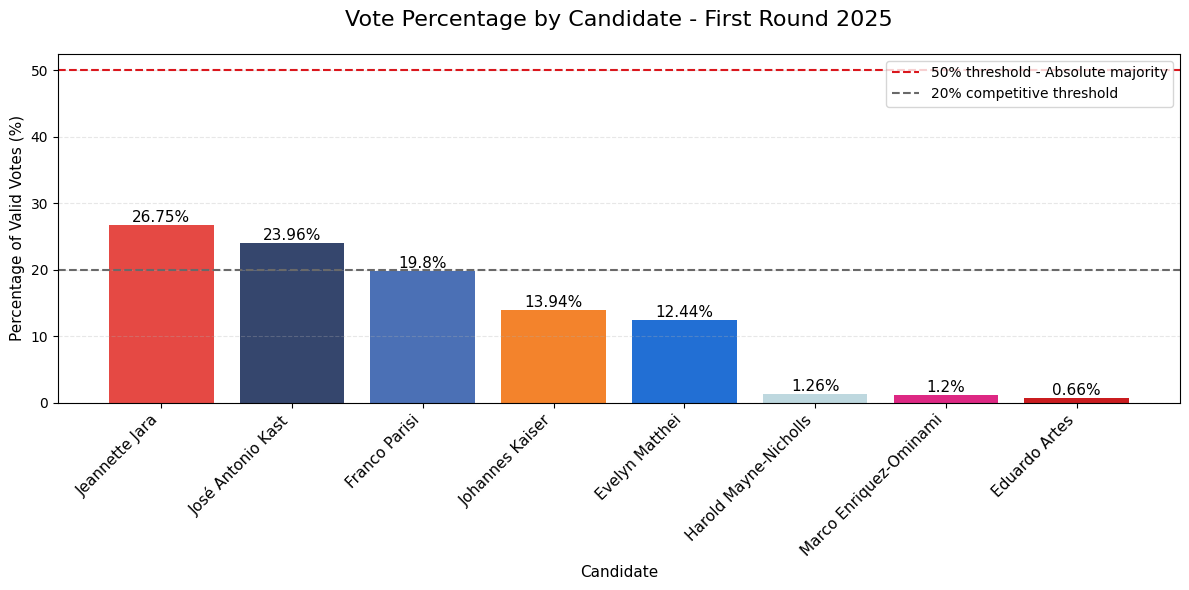

In [266]:
# Build ordered lists from the already-computed DataFrame
candidates_ordered  = candidate_results['candidate'].tolist()
percentages_ordered = candidate_results['vote_percentage'].tolist()
bar_colors          = [CANDIDATE_COLORS[c] for c in candidates_ordered]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(candidates_ordered, percentages_ordered,
              color=bar_colors, linewidth=1)

# Percentage label above each bar
for bar, pct in zip(bars, percentages_ordered):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height(),
        f'{pct}%',
        ha='center', va='bottom', fontsize=11,
    )

# Electoral reference lines
ax.axhline(y=50, color='#DA171D', linestyle='--', linewidth=1.5,
           label='50% threshold - Absolute majority')
ax.axhline(y=20, color='#696969', linestyle='--', linewidth=1.5,
           label='20% competitive threshold')

ax.set_title('Vote Percentage by Candidate - First Round 2025', fontsize=16, pad=20)
ax.set_ylabel('Percentage of Valid Votes (%)', fontsize=11)
ax.set_xlabel('Candidate', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

##### Análisis por Grupos de Competitividad

**Grupo 1: Liderazgo Competitivo (Alto Apoyo)**

- **Jeannette Jara (26.75%)** Ganadora de la primera vuelta. Base sólida de **3.45 millones** de votos. Representa la continuidad y unidad de la izquierda/oficialismo. Su votación, aunque lideró, es modesta para una candidatura que aglutinó prácticamente todo el espectro progresista. Muestra los límites del apoyo al gobierno de Gabriel Boric.
- **José Antonio Kast (23.96%)** Segunda fuerza nacional. A solo **2.79 puntos porcentuales** (≈ 360 mil votos) de Jara. Consolidó el voto conservador y logró la mejor primera vuelta de la derecha en décadas. Demuestra una derecha con base fiel y movilizada, pero que aún no logra un arrastre mayoritario por sí sola.

**Diferencia Jara – Kast:** 2.79 puntos → **Ventaja mínima**. Jara parte con una leve delantera, pero en un contexto de alta fragmentación, esto no constituye una posición cómoda de cara al balotaje.

**Grupo 2: Competidores Relevantes (Medio Apoyo)**

- **Franco Parisi (19.80%)** : Tercera fuerza con 2.55 millones de votos. El gran fenómeno antisistema de la elección. Su caudal representa descontento transversal: económico, migratorio, inseguridad y rechazo a los polos tradicionales. Su electorado será el rey maker de la segunda vuelta.
- **Johannes Kaiser (13.94%)**: Fuerte irrupción de la derecha libertaria. Captó un voto ideológico joven y urbano que se siente más radical que el de Kast en algunos temas (especialmente migración y orden público). Alta compatibilidad de transferencia hacia Kast.
- **Evelyn Matthei (12.44%)**: La más baja votación histórica reciente de una candidatura de Chile Vamos. Refleja el desgaste severo de la derecha tradicional y la dificultad de posicionarse entre el centro y la nueva derecha republicana.

**Suma del “tercio medio” (Parisi + Kaiser + Matthei):** **46.18%** (~5.95 millones de votos)

**Grupo 3: Candidatos Residuales** Harold Mayne-Nicholls, Marco Enríquez-Ominami y Eduardo Artés suman solo **3.12%** del voto válido. Su impacto es marginal, aunque parte de ese voto puede haber sido expresión de protesta o nichos muy específicos.

##### Análisis Estratégico por Bloques Ideológicos

| Bloque                    | Candidatos              | % Total    | Votos aprox. | Característica principal              |
| ------------------------- | ----------------------- | ---------- | ------------ | ------------------------------------- |
| Izquierda                 | Jara + MEO + Artés      | **28.61%** | 3.686.691    | Liderazgo claro pero estrecho         |
| Derecha                   | Kast + Kaiser + Matthei | **50.34%** | 6.486.101    | Mayoría teórica, fuerte fragmentación |
| Tercera Vía / Antisistema | Parisi + Mayne-Nicholls | **21.06%** | 2.713.136    | Pivote decisivo                       |

**Insights clave:**

- La derecha chilena no solo se identifica ideológicamente: suma más del 50% de los votos, lo que confirma un claro giro a la derecha del electorado. Sin embargo, este giro no es puramente ideológico. Gran parte se explica por el **desgaste acumulado del gobierno de Gabriel Boric** (seguridad, migración descontrolada, estancamiento económico, crisis de confianza institucional y percepción de debilidad frente al orden público).
- La fragmentación de la derecha (tres candidaturas competitivas) le impidió ganar en primera vuelta, pero también evidencia vitalidad interna: el electorado de derecha está más movilizado y diversificado que el de izquierda.
- **Parisi** captura el voto más volátil y antisistema: mezcla de desencanto económico, clases medias y bajas afectadas por la crisis, y rechazo a “la política tradicional”. No es puramente de derecha ni de izquierda, pero tiende a penalizar al oficialismo.
- Ningún candidato supera el **27%**. Esto habla de **legitimidad relativa** del ganador de primera vuelta y de una sociedad profundamente segmentada, donde el voto es más de castigo al incumbente que de adhesión entusiasta a un proyecto.

#### Conclusión

La primera vuelta presidencial 2025 reflejó un escenario de **fragmentación avanzada** y **liderazgos débiles**, pero con una tendencia estructural clara: **un giro hacia la derecha impulsado principalmente por el desgaste del gobierno de Boric**.

Aunque Jeannette Jara logró el primer lugar gracias a la unidad del oficialismo y la izquierda, su 26,75% está lejos de constituir un mandato fuerte. La derecha, pese a su división interna, demostró ser la fuerza mayoritaria del país (más del 50% sumada). Franco Parisi consolidó un potente voto antisistema que actuó como barómetro del descontento y se convirtió en el factor decisivo de cara a la segunda vuelta.

Este mapa electoral revela una sociedad chilena **altamente polarizada y segmentada**: las identidades políticas tradicionales persisten, pero coexisten con un amplio caudal de desencanto ciudadano que prioriza temas como seguridad, economía y orden por sobre proyectos ideológicos maximalistas.

**Recomendación estratégica**: El próximo gobierno, sea quien gane el balotaje, enfrentará la necesidad de construir coaliciones amplias y entregar resultados concretos en las demandas ciudadanas más urgentes. La alta fragmentación y el peso del voto protesta indican que la gobernabilidad en Chile requerirá pragmatismo y capacidad de negociación, más allá de las fronteras ideológicas tradicionales.

## 5. Electoral Strongholds: Top 10 Communes per Candidate

In [267]:
import numpy as np

# ============================================================================
# STRONGHOLD ANALYSIS
# ============================================================================

# Percentage column → corresponding vote column
PCT_TO_VOTES = {
    'artes_pct':             'artes_votes',
    'enriquez_ominami_pct':  'enriquez_ominami_votes',
    'jara_pct':              'jara_votes',
    'kaiser_pct':            'kaiser_votes',
    'kast_pct':              'kast_votes',
    'matthei_pct':           'matthei_votes',
    'mayne_nicholls_pct':    'mayne_nicholls_votes',
    'parisi_pct':            'parisi_votes',
}

COLS_PCT = [
    'artes_pct', 'enriquez_ominami_pct', 'jara_pct', 'kaiser_pct',
    'kast_pct', 'matthei_pct', 'mayne_nicholls_pct', 'parisi_pct',
]


def candidate_strongholds(df: pd.DataFrame, col_pct: str, n: int = 10) -> pd.DataFrame:
    """
    Identifies the N communes with the highest vote percentage for a candidate
    and indicates whether that candidate won in each of them.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with percentage and vote columns per candidate.
    col_pct : str
        Percentage column name for the target candidate.
    n : int
        Number of communes to return (default 10).

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, votes, percentage, commune_result.
    """
    vote_col = PCT_TO_VOTES[col_pct]

    # Select required columns, preserving order and avoiding duplicates
    cols_needed = ['commune', 'region', vote_col, col_pct] + COLS_PCT
    cols_needed = list(dict.fromkeys(cols_needed))

    df_tmp = df[cols_needed].copy().reset_index(drop=True)
    df_tmp = df_tmp.rename(columns={vote_col: 'candidate_votes'})

    # Maximum percentage among all other candidates (vectorised)
    other_cols = [c for c in COLS_PCT if c != col_pct]
    max_others = df_tmp[other_cols].max(axis=1).values
    target_pct = df_tmp[col_pct].values

    if target_pct.ndim > 1: target_pct = target_pct.flatten()
    if max_others.ndim > 1: max_others = max_others.flatten()

    df_tmp['commune_result'] = np.where(target_pct >= max_others, 'Wins', 'Loses')

    top_n  = df_tmp.nlargest(n, col_pct)
    result = top_n[['commune', 'region', 'candidate_votes', col_pct, 'commune_result']].copy()
    result = result.rename(columns={'candidate_votes': 'votes', col_pct: 'percentage'})
    return result

### 5.1. Jeannette Jara

In [268]:
jara_strongholds = candidate_strongholds(df_votes, 'jara_pct', n=10)
display(jara_strongholds)

,commune,region,votes,percentage,commune_result
299,Juan Fernandez,Valparaíso,235,43.44,Wins
252,Pedro Aguirre Cerda,Metropolitana,30357,41.90,Wins
264,San Joaquin,Metropolitana,26233,39.29,Wins
244,Lo Espejo,Metropolitana,25101,37.10,Wins
279,ÑUñoa,Metropolitana,65386,36.55,Wins
247,Maipu,Metropolitana,127656,36.40,Wins
318,Valparaiso,Valparaíso,76553,36.34,Wins
265,San Jose de Maipo,Metropolitana,4914,36.20,Wins
234,Conchali,Metropolitana,32397,36.12,Wins
245,Lo Prado,Metropolitana,24166,35.68,Wins


### Patrones Geográficos y Socioeconómicos Identificados

1. **Fuerte Concentración Metropolitana (80% del top 10)** Jara domina en comunas de la **Región Metropolitana**, especialmente en el **sector poniente y sur** (Pedro Aguirre Cerda, Lo Espejo, Lo Prado, San Joaquín, Conchalí, Maipú). Estas son zonas de **alta densidad poblacional**, con fuerte presencia de clases medias-bajas y populares.
2. **Presencia en Región de Valparaíso** Destaca Valparaíso (ciudad puerto con tradición de izquierda) y la comuna insular **Juan Fernández** (caso excepcional por su aislamiento geográfico y baja población).
3. **Perfil Socioeconómico Común**:
   - Comunas con **mayor vulnerabilidad social** (alto Índice de Prioridad Social según Ministerio de Desarrollo Social).
   - Sectores con **histórica base de apoyo a la izquierda** (herencia de la Concertación/Nueva Mayoría y gobiernos progresistas).
   - Alta densidad habitacional y presencia de viviendas sociales.
   - Ñuñoa es la excepción relativa (comuna mixta con mayor nivel socioeconómico, donde Jara también logra buen desempeño).

**Conclusión del patrón**: El voto a Jara en primera vuelta se **concentra fuertemente en zonas urbanas densas y de mayor vulnerabilidad socioeconómica**, principalmente en el Gran Santiago y Valparaíso. Su apoyo es más **territorialmente concentrado** que expandido

### 5.2. José Antonio Kast

In [269]:
kast_strongholds = candidate_strongholds(df_votes, 'kast_pct', n=10)
display(kast_strongholds)

,commune,region,votes,percentage,commune_result
199,Chanco,Maule,3717,46.61,Wins
94,Lumaco,La Araucanía,3356,46.19,Wins
111,los Sauces,La Araucanía,2818,46.16,Wins
187,Antartica,Magallanes,35,45.45,Wins
204,Empedrado,Maule,1689,44.39,Wins
39,Contulmo,Biobío,2110,42.57,Wins
101,Puren,La Araucanía,4040,41.30,Wins
243,Lo Barnechea,Metropolitana,31581,41.03,Wins
59,Tirua,Biobío,3125,40.82,Wins
196,Timaukel,Magallanes,93,40.09,Wins


#### Patrones Geográficos y Socioeconómicos Identificados

1. **Fuerte sesgo rural y sureño** Kast domina en **comunas rurales** del sur de Chile (Maule, Biobío, La Araucanía y Magallanes). Ocho de las diez comunas top son rurales o de baja densidad poblacional.
2. **Comunas con altos niveles de vulnerabilidad y abandono relativo** Muchas de estas comunas (Lumaco, Contulmo, Tirúa, Los Sauces, etc.) presentan **bajos indicadores socioeconómicos**, alto Índice de Vulnerabilidad y percepción de abandono estatal histórico. No son comunas ricas, sino territorios tradicionales, agrícolas y forestales que sienten distancia con el centralismo santiaguino.
3. **Rechazo al centralismo como factor clave** El voto a Kast en estas zonas refleja, en buena medida, un **castigo al centralismo** y a las políticas percibidas como “santiaguinas” del gobierno de Boric (seguridad, migración, manejo de la macrozona sur y La Araucanía).
4. **Excepción notable: Lo Barnechea (41,03%)** La única comuna de alto ingreso en el top 10. Histórico bastión de Chile Vamos (derecha tradicional), donde Kast logra penetrar con fuerza el electorado de elite oriente. Esto marca un **traspaso simbólico** importante: parte de la derecha tradicional comienza a migrar hacia el sector republicano.

**Conclusión del patrón**: A diferencia de Jara (concentrada en zonas urbanas populares de la RM y Valparaíso), el voto a Kast es **mucho más distribuido geográficamente** y tiene un fuerte componente **rural y periférico**. Su apoyo se basa en comunas con menor densidad poblacional pero alta lealtad, lo que le permitió ganar en un número muy superior de comunas a pesar de quedar segundo en primera vuelta.

### 5.3. Franco Parisi

In [270]:
parisi_strongholds = candidate_strongholds(df_votes, 'parisi_pct', n=10)
display(parisi_strongholds)

,commune,region,votes,percentage,commune_result
4,Ollague,Antofagasta,427,58.17,Wins
282,Colchane,Tarapacá,695,57.30,Wins
11,General Lagos,Arica y Parinacota,302,48.95,Wins
2,Maria Elena,Antofagasta,1429,45.86,Wins
13,Alto del Carmen,Atacama,1565,43.16,Wins
281,Camiña,Tarapacá,729,43.09,Wins
280,Alto Hospicio,Tarapacá,25061,42.94,Wins
20,Tierra Amarilla,Atacama,4365,42.59,Wins
6,Sierra Gorda,Antofagasta,442,41.90,Wins
286,Pozo Almonte,Tarapacá,4037,41.39,Wins


#### Patrones Geográficos y Socioeconómicos Identificados

1. **Fuerte concentración en el Norte Grande** Parisi domina de manera contundente en las regiones de **Arica y Parinacota, Tarapacá y Antofagasta**. Nueve de las diez comunas top se encuentran en el norte del país.
2. **Similar a Kast pero en el Norte** Al igual que Kast en el sur, Parisi muestra gran fuerza en **comunas rurales, de baja densidad y con sensación de abandono estatal**. Muchas son fronterizas o del altiplano.
3. **Factores diferenciadores clave**:
   - **Migración irregular**: Comunas como Colchane, Ollagüe y General Lagos fueron epicentros de la crisis migratoria de los últimos años.
   - **Delincuencia y percepción de inseguridad**: Alto Hospicio y varias comunas del norte han enfrentado un aumento significativo de delitos asociados al crimen organizado y bandas transnacionales.
   - **Abandono estatal**: Sensación de que el centralismo santiaguino no responde a las necesidades locales (infraestructura, empleo, seguridad y servicios básicos).

**Conclusión del patrón**: Franco Parisi capitalizó un **voto de protesta territorial** en el Norte de Chile. Su bastión se construye sobre comunas con alta vulnerabilidad, fuerte presencia de problemas fronterizos y una clara percepción de abandono por parte del Estado. Su discurso antisistema, anti-migración descontrolada y de orden resonó fuertemente en estas zonas, convirtiéndolo en el candidato más dominante territorialmente de los tres principales (monopolio claro en el Norte).

### 5.4. Johannes Kaiser

In [271]:
kaiser_strongholds = candidate_strongholds(df_votes, 'kaiser_pct', n=10)
display(kaiser_strongholds)

,commune,region,votes,percentage,commune_result
155,Futaleufu,Los Lagos,671,31.11,Wins
160,Palena,Los Lagos,380,27.03,Wins
195,San Gregorio,Magallanes,98,26.13,Wins
187,Antartica,Magallanes,20,25.97,Loses
24,Cisnes,Aysén,916,25.86,Wins
148,Chaiten,Los Lagos,811,25.24,Loses
194,Rio Verde,Magallanes,105,24.08,Loses
28,Lago Verde,Aysén,173,23.90,Loses
174,los Muermos,Los Lagos,3407,23.60,Loses
29,O'higgins,Aysén,104,23.58,Loses


#### Patrones Geográficos y Socioeconómicos Identificados

1. **Concentración en el Sur y Patagonia** Kaiser tiene su principal apoyo en comunas de **Los Lagos, Aysén y Magallanes**. Su votación se concentra en territorios **rurales, aislados y de baja densidad poblacional** del extremo sur de Chile.
2. **Patrón similar a Kast, pero más débil y radical** Al igual que Kast, Kaiser muestra fuerza en zonas rurales con percepción de abandono estatal. Sin embargo, su performance es **significativamente menor** en volumen de votos y cobertura territorial.
3. **Baja efectividad electoral** A pesar de aparecer en el top 10 nacional de porcentaje, **Kaiser solo ganó en 4 comunas a nivel nacional**. Esto refleja que su apoyo, aunque concentrado en algunos territorios patagónicos, no fue suficiente para imponerse en la mayoría de las comunas donde compitió.
4. **Posicionamiento ideológico** Kaiser buscó diferenciarse de Kast presentándose como una opción **más radical** dentro de la derecha (discurso más duro en migración, orden público, crítica a organismos internacionales y libertades individuales). Esto le permitió captar un nicho ideológico, especialmente entre votantes jóvenes y rurales descontentos, pero limitó su alcance masivo.

**Conclusión del patrón**: Kaiser representa un **nicho radicalizado** dentro de la derecha sureña y patagónica. Su votación se construye sobre comunas rurales aisladas con sensación de abandono, similar a los bastiones de Kast y Parisi, pero con menor volumen y menor éxito territorial (solo 4 victorias comunales). Su rol fue más de **presión ideológica** hacia Kast que de competencia real por el liderazgo de la derecha

### 5.5. Evelyn Matthei

In [272]:
matthei_strongholds = candidate_strongholds(df_votes, 'matthei_pct', n=10)
display(matthei_strongholds)

,commune,region,votes,percentage,commune_result
272,Vitacura,Metropolitana,29467,42.45,Wins
278,las Condes,Metropolitana,79998,36.54,Wins
256,Providencia,Metropolitana,43965,36.30,Wins
243,Lo Barnechea,Metropolitana,23778,30.89,Loses
277,la Reina,Metropolitana,21697,29.38,Wins
279,ÑUñoa,Metropolitana,48927,27.35,Loses
321,Zapallar,Valparaíso,2168,23.59,Loses
269,Santiago,Metropolitana,56605,23.11,Loses
266,San Miguel,Metropolitana,20141,22.11,Loses
240,Independencia,Metropolitana,13080,20.03,Loses


#### Patrones Geográficos y Socioeconómicos Identificados

1. **Alta concentración en la Región Metropolitana** Matthei concentra casi toda su fuerza en comunas del **sector oriente de Santiago**. Nueve de las diez comunas con mejor desempeño pertenecen a la RM.
2. **Voto elitista de la derecha tradicional** Sus bastiones más fuertes (Vitacura, Las Condes, Providencia, Lo Barnechea, La Reina) corresponden a las comunas de **mayor ingreso y nivel socioeconómico** de Chile. Representa claramente el voto de **derecha tradicional y elite económica**, no el voto popular.
3. **Desgaste de la política tradicional** Matthei sufre un fuerte **castigo por el desgaste de la derecha histórica**. Su performance es la más baja de las candidaturas de Chile Vamos en décadas. Este desgaste es incluso más pronunciado que el de Jara en la izquierda.
4. **Asociación con el gobierno de Piñera y el Estallido Social** Gran parte del electorado asocia a Matthei con el gobierno de Sebastián Piñera (2018-2022), especialmente con la gestión del Estallido Social de 2019. Esto le generó un alto costo electoral en sectores que demandaban cambio.
5. **Impacto del centralismo** Al igual que otros candidatos, el sentimiento anti-centralista jugó en contra, pero en su caso afectó especialmente a la derecha tradicional, percibida como parte del establishment santiaguino.

**Conclusión del patrón**: Evelyn Matthei representa el **voto elitista y tradicional de la derecha**, fuertemente concentrado en las comunas más acomodadas del oriente de Santiago. Su campaña quedó atrapada entre el avance de Kast (derecha más dura y popular) y el desgaste acumulado de la política tradicional, lo que explica su bajo porcentaje nacional (12,44%) y la pérdida de bastiones históricos.



### 5.6. Principales Conclusiones
1. **Chile está electoralmente fragmentado en “tres Chiles”**
   - **Chile Urbano Popular** (Jara): Concentrado en la Región Metropolitana y Valparaíso.
   - **Chile Rural y Periférico** (Kast + Parisi): Sur profundo y Norte Grande, unidos por la percepción de **abandono estatal y centralismo**.
   - **Chile Elite** (Matthei): Reducido al oriente de Santiago.
2. **Kast y Parisi capitalizaron el voto de protesta territorial** Ambos mostraron patrones similares: fuerza en comunas rurales, de baja densidad, con sensación de abandono y problemas específicos (Araucanía y delincuencia rural en Kast; migración y frontera en Parisi). Kast logró mayor expansión nacional, mientras Parisi logró mayor intensidad (monopolio) en su zona.
3. **La derecha tradicional (Matthei) sufrió el mayor desgaste** Matthei quedó atrapada entre Kast (más popular y dura) y el rechazo histórico al gobierno de Piñera. Su apoyo se redujo casi exclusivamente a las comunas más ricas de Santiago, perdiendo terreno incluso en sectores que históricamente le eran leales.
4. **Kaiser actuó como candidato “presión”** Su rol fue más ideológico que territorial. Captó un nicho radical en la Patagonia, pero su escaso volumen y solapamiento con Kast limitaron su impacto. Es el candidato con menor proyección de los cinco.
5. **Diferencia clave: Concentración vs Expansión**
   - **Jara** tiene la base más densa y leal (alta cantidad de votos en pocas comunas grandes).
   - **Kast** tiene la base más expandida territorialmente (ganó en muchas más comunas).
   - **Parisi** tiene la mayor intensidad relativa (porcentajes muy altos en su zona).

**Conclusión Estratégica Final**: La elección de 2025 no fue solo una competencia entre proyectos ideológicos, sino también un **plebiscito territorial y emocional** contra el centralismo santiaguino. La derecha (sumada) demostró ser mayoritaria, pero fragmentada. La izquierda mantuvo su bastión urbano-popular, mientras el voto antisistema (Parisi) se convirtió en el gran árbitro geográfico de la segunda vuelta.

Este mapa fragmentado explica tanto la ventaja mínima de Jara en primera vuelta como la posterior victoria de Kast en segunda: **la capacidad de consolidar y expandir apoyos más allá de los bastiones naturales**.

## 6. Territorial Mapping: Communes Won by Candidate

In [273]:
# ============================================================================
# TERRITORIAL WINNER MAPPING
# ============================================================================

def map_territorial_winners(df: pd.DataFrame) -> pd.DataFrame:
    """
    Determines the candidate with the highest vote percentage in each commune
    and consolidates the count of communes won by each candidate.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Columns: candidate, communes_won, communes_percentage.
    """
    COL_TO_CANDIDATE = {
        'jara_pct':             'Jeannette Jara',
        'kast_pct':             'José Antonio Kast',
        'parisi_pct':           'Franco Parisi',
        'kaiser_pct':           'Johannes Kaiser',
        'matthei_pct':          'Evelyn Matthei',
        'mayne_nicholls_pct':   'Harold Mayne-Nicholls',
        'enriquez_ominami_pct': 'Marco Enriquez-Ominami',
        'artes_pct':            'Eduardo Artes',
    }
    cols_pct   = list(COL_TO_CANDIDATE.keys())
    winner_col = df[cols_pct].idxmax(axis=1).map(COL_TO_CANDIDATE)

    victories = winner_col.value_counts().reset_index()
    victories.columns = ['candidate', 'communes_won']
    victories['communes_percentage'] = round(
        (victories['communes_won'] / len(df)) * 100, 1
    )
    return victories.sort_values('communes_won', ascending=False).reset_index(drop=True)


territorial_map = map_territorial_winners(df_votes)
territorial_map

,candidate,communes_won,communes_percentage
0,José Antonio Kast,169,48.8
1,Jeannette Jara,105,30.3
2,Franco Parisi,64,18.5
3,Johannes Kaiser,4,1.2
4,Evelyn Matthei,4,1.2


La primera vuelta presidencial 2025 dejó en evidencia una **clara disociación entre control territorial y peso demográfico**. Más allá de los porcentajes nacionales de voto, la distribución de comunas ganadas revela estrategias electorales radicalmente diferentes entre los candidatos.

**José Antonio Kast** logró una **hegemonía territorial** sin precedentes al ganar en 169 comunas (48,8% del total), demostrando una penetración amplia a lo largo del país, especialmente en zonas rurales y del sur. Por su parte, **Jeannette Jara** concentró su apoyo en 105 comunas (30,3%), pero con alta densidad poblacional, especialmente en la Región Metropolitana. **Franco Parisi** consolidó un monopolio regional en el Norte con 64 comunas, mientras que **Evelyn Matthei** y **Johannes Kaiser** quedaron relegados a solo 4 comunas cada uno, representando el colapso de la derecha tradicional y el carácter nicho del libertarianismo.

Esta distribución confirma que la elección no se definió solo por el voto total, sino por la capacidad de cada candidato de dominar territorios específicos con características socioeconómicas y culturales distintas.

### 6.1. Territorial Vote Distribution by Macrozone

In [274]:
# ============================================================================
# COMMUNES WON PER CANDIDATE x MACROZONE (TABLE)
# ============================================================================

def communes_won_by_zone(df_votes: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Builds a pivot table (candidates as rows, macrozonas as columns) showing
    how many communes each candidate won in each macrozone.

    Parameters
    ----------
    df_votes : pd.DataFrame
    df_region_dim : pd.DataFrame
        Region dimension table with 'region', 'macrozone', 'macrozone_order'.

    Returns
    -------
    pd.DataFrame
    """
    main_candidates = {
        'jara_pct':    'Jeannette Jara',
        'kast_pct':    'José Antonio Kast',
        'parisi_pct':  'Franco Parisi',
        'kaiser_pct':  'Johannes Kaiser',
        'matthei_pct': 'Evelyn Matthei',
    }

    df_merged = df_votes.merge(
        df_region_dim[['region', 'macrozone', 'macrozone_order']],
        on='region', how='left',
    )
    cols_pct = list(main_candidates.keys())
    df_merged['winner'] = df_merged[cols_pct].idxmax(axis=1).map(main_candidates)

    pivot = pd.crosstab(df_merged['winner'], df_merged['macrozone'], margins=False)

    # Ensure all candidates appear even with zero wins
    for cand in main_candidates.values():
        if cand not in pivot.index:
            pivot.loc[cand] = 0

    pivot['Total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('Total', ascending=False).drop(columns='Total')

    # Order columns north to south
    zone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )
    return pivot[zone_order]


zone_table = communes_won_by_zone(df_votes, df_region_dim)
zone_table

macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
winner,,,,,,
José Antonio Kast,0,0,63,70,27,9
Jeannette Jara,1,9,75,5,5,10
Franco Parisi,19,15,11,11,8,0
Evelyn Matthei,0,0,4,0,0,0
Johannes Kaiser,0,0,0,0,2,2


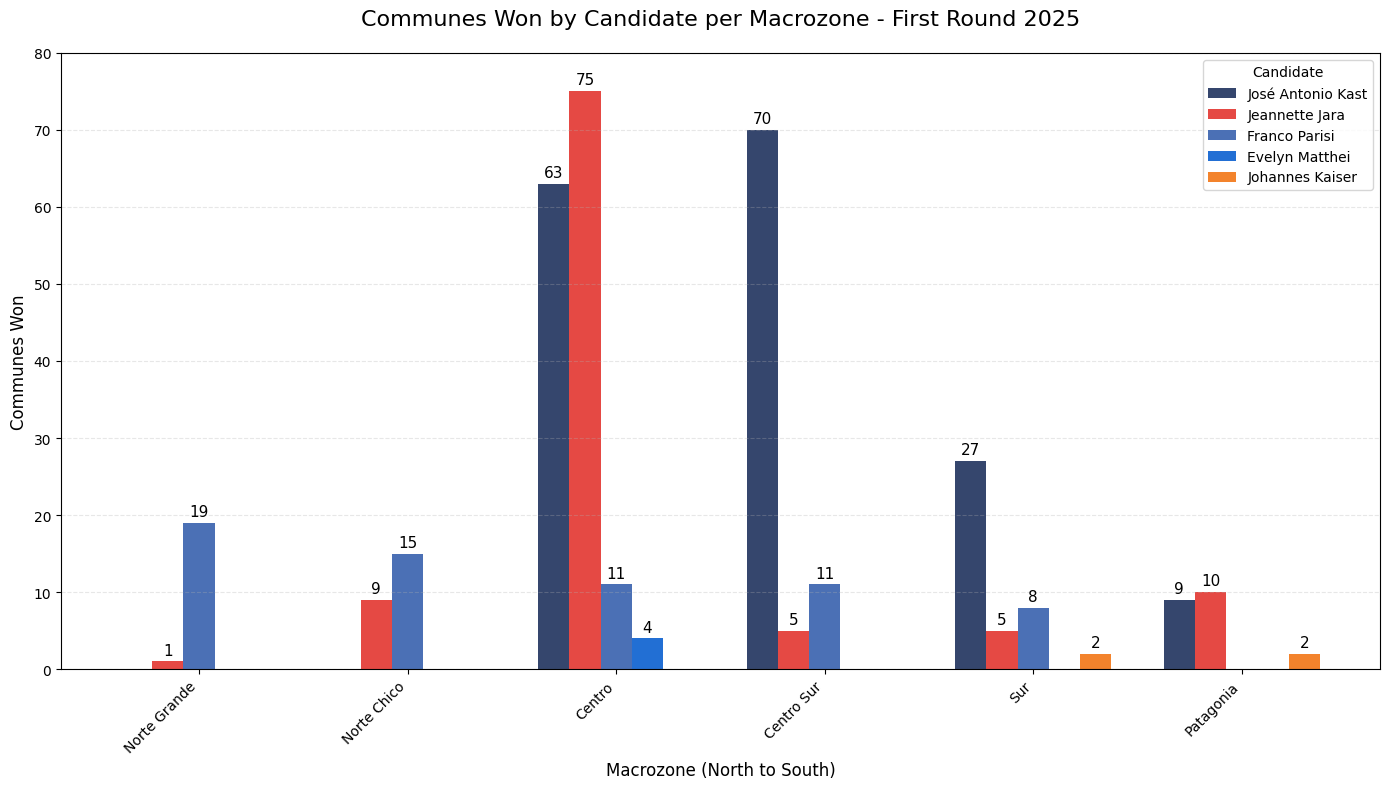

In [275]:
# ============================================================================
# COMMUNES WON PER CANDIDATE x MACROZONE (GROUPED BAR CHART)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_communes_won_by_zone(df_votes: pd.DataFrame, df_region_dim: pd.DataFrame) -> None:
    """
    Creates a grouped bar chart showing communes won by each candidate per macrozone.

    Parameters
    ----------
    df_votes : pd.DataFrame
    df_region_dim : pd.DataFrame
    """
    main_candidates = {
        'jara_pct':    'Jeannette Jara',
        'kast_pct':    'José Antonio Kast',
        'parisi_pct':  'Franco Parisi',
        'kaiser_pct':  'Johannes Kaiser',
        'matthei_pct': 'Evelyn Matthei',
    }

    df_merged = df_votes.merge(
        df_region_dim[['region', 'macrozone', 'macrozone_order']],
        on='region', how='left',
    )
    cols_pct = list(main_candidates.keys())
    df_merged['winner'] = df_merged[cols_pct].idxmax(axis=1).map(main_candidates)

    pivot = pd.crosstab(df_merged['winner'], df_merged['macrozone'], margins=False)
    for candidate in main_candidates.values():
        if candidate not in pivot.index:
            pivot.loc[candidate] = 0

    macrozone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )
    pivot = pivot[macrozone_order]
    pivot['Total']   = pivot.sum(axis=1)
    candidates_order = pivot.sort_values('Total', ascending=False).index.tolist()
    pivot            = pivot.loc[candidates_order].drop(columns=['Total'])

    colors = {
        'Jeannette Jara':    '#E54944',
        'José Antonio Kast': '#35466D',
        'Franco Parisi':     '#4B70B5',
        'Johannes Kaiser':   '#F3832C',
        'Evelyn Matthei':    '#226FD4',
    }

    fig, ax = plt.subplots(figsize=(14, 8))
    x       = np.arange(len(macrozone_order))
    width   = 0.15
    offsets = np.linspace(-0.3, 0.3, len(candidates_order))

    for i, candidate in enumerate(candidates_order):
        values = pivot.loc[candidate].values
        bars   = ax.bar(x + offsets[i], values, width,
                        label=candidate, color=colors.get(candidate, '#D3D3D3'))
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(val)), ha='center', va='bottom', fontsize=11)

    ax.set_xlabel('Macrozone (North to South)', fontsize=12)
    ax.set_ylabel('Communes Won', fontsize=12)
    ax.set_title('Communes Won by Candidate per Macrozone - First Round 2025',
                 fontsize=16, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(macrozone_order, rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10, title='Candidate')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, pivot.values.max() + 5)
    plt.tight_layout()
    plt.show()


plot_communes_won_by_zone(df_votes, df_region_dim)

#### Análisis Detallado por Macrozona

Un análisis más granular por zonas geográficas de Chile permite entender con mayor precisión cómo se configuró el mapa electoral:

**En el Norte Grande y Norte Chico**, Franco Parisi logró un **dominio abrumador**, ganando la gran mayoría de las comunas. Esta zona se convirtió en su bastión indiscutido, donde capitalizó el descontento por migración irregular, delincuencia y percepción de abandono estatal. Su control regional fue tan fuerte que prácticamente no dejó espacio a los otros candidatos.

**En la zona Centro** (principalmente Región Metropolitana y Valparaíso), **Jeannette Jara** impuso una clara hegemonía. Aquí se concentró su fortaleza: comunas urbanas densas, con alta población y sectores populares. Esta macrozona representa el corazón demográfico del país, por lo que su dominio aquí le permitió liderar la primera vuelta a pesar de tener menos comunas totales que Kast.

**En el Centro Sur y Sur**, José Antonio Kast exhibió un dominio contundente. Estas zonas rurales y semi-rurales respondieron fuertemente a su discurso de orden, anti-centralismo y defensa de la seguridad. Kast logró aquí una de sus mayores ventajas territoriales, consolidando un voto conservador y tradicional que se extendió desde el Maule hasta Los Lagos.

**En la Patagonia**, el territorio se repartió principalmente entre Jara y Kast, con una presencia marginal de Kaiser. Esta zona extrema refleja tanto el voto rural conservador como ciertos bastiones de izquierda en áreas más aisladas.

**Insights clave de la segmentación por zona**:

- La **fragmentación geográfica** es evidente: cada candidato tuvo “su Chile”. No existió un candidato con apoyo homogéneo a nivel nacional.
- Kast demostró ser el candidato más **transversal territorialmente**, presente en casi todas las zonas excepto el Norte.
- Jara dependió fuertemente del voto **urbano-central**, lo que la hace vulnerable fuera de las grandes ciudades.
- Parisi quedó prisionero de su éxito norteño: gran intensidad, pero poca escala nacional.
- La derecha tradicional (Matthei) desapareció prácticamente del mapa fuera del oriente de Santiago.

Esta segmentación por macrozonas refuerza la idea de un país electoralmente dividido en “varios Chiles” con demandas y sensibilidades distintas: el Norte protestante, el Centro urbano-popular, el Sur rural-conservador y los reductos elitistas.

#### Disociación entre Territorio y Población

**Paradoja central del proceso**:

- Kast controló casi la mitad del territorio nacional (48,8%), pero solo obtuvo el 23,96% de los votos.
- Jara ganó en menos comunas (30,3%), pero concentró mayor densidad de votos (26,75%).
- Parisi logró equilibrio entre intensidad y territorio regional.

Esta diferencia estratégica —**amplitud territorial (Kast)** versus **profundidad demográfica (Jara)**— fue uno de los factores determinantes de cara a la segunda vuelta.

## 7. Results by Region

In [276]:
# ============================================================================
# REGIONAL RESULTS AGGREGATION
# ============================================================================

# Lookup dictionaries derived from the dimension table
REGION_ORDER     = dict(zip(df_region_dim['region'], df_region_dim['region_order']))
MACROZONE_BY_REG = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))

CANDIDATE_KEYS = [
    'jara', 'kast', 'parisi', 'kaiser',
    'matthei', 'mayne_nicholls', 'enriquez_ominami', 'artes',
]

KEY_TO_NAME = {
    'jara':             'Jeannette Jara',
    'kast':             'José Antonio Kast',
    'parisi':           'Franco Parisi',
    'kaiser':           'Johannes Kaiser',
    'matthei':          'Evelyn Matthei',
    'mayne_nicholls':   'Harold Mayne-Nicholls',
    'enriquez_ominami': 'Marco Enriquez-Ominami',
    'artes':            'Eduardo Artes',
}


def analyze_results_by_region(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates votes by region, calculates percentages over valid votes,
    determines the regional winner and orders from north to south.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with vote columns per candidate.

    Returns
    -------
    pd.DataFrame
        Columns: region, regional_winner, and percentage per candidate.
    """
    cols_agg = (
        {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
        | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
    )
    agg = df.groupby('region').agg(cols_agg).reset_index()

    # Protect against division by zero
    agg['valid_votes'] = (
        agg['casted_votes'] - agg['blank_votes'] - agg['null_votes']
    ).replace(0, 1)

    for cand in CANDIDATE_KEYS:
        agg[f'{cand}_percentage'] = round(
            (agg[f'{cand}_votes'] / agg['valid_votes']) * 100, 2
        )

    pct_cols = [f'{c}_percentage' for c in CANDIDATE_KEYS]
    agg['regional_winner'] = (
        agg[pct_cols]
        .idxmax(axis=1)
        .str.replace('_percentage', '', regex=False)
        .map(KEY_TO_NAME)
    )

    result = agg[['region', 'regional_winner'] + pct_cols].copy()
    result['order'] = result['region'].map(REGION_ORDER).fillna(99)
    result = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


regional_results = analyze_results_by_region(df_votes)
regional_results

,region,regional_winner,jara_percentage,kast_percentage,parisi_percentage,kaiser_percentage,matthei_percentage,mayne_nicholls_percentage,enriquez_ominami_percentage,artes_percentage
0,Arica y Parinacota,Franco Parisi,22.77,21.91,27.84,18.09,6.69,0.96,1.15,0.58
1,Tarapacá,Franco Parisi,21.98,22.60,31.11,14.57,6.95,1.14,1.11,0.54
2,Antofagasta,Franco Parisi,23.35,18.02,34.99,13.08,7.47,1.39,1.14,0.53
3,Atacama,Franco Parisi,26.45,18.81,32.60,13.13,6.29,1.01,1.16,0.55
4,Coquimbo,Jeannette Jara,27.49,19.05,26.72,13.75,10.08,1.13,1.20,0.59
5,Valparaíso,Jeannette Jara,29.56,20.26,19.50,15.39,11.88,1.40,1.31,0.70
6,Metropolitana,Jeannette Jara,31.14,21.82,14.26,12.86,16.44,1.46,1.25,0.77
7,Libertador,José Antonio Kast,24.49,25.50,21.91,13.86,11.35,1.13,1.24,0.53
8,Maule,José Antonio Kast,21.59,30.51,22.15,13.65,9.61,0.93,1.11,0.45
9,Ñuble,José Antonio Kast,19.03,31.64,22.10,15.11,9.71,0.87,1.01,0.52


El análisis por región confirma la **trifurcación territorial** del voto en la primera vuelta presidencial 2025. Más que una elección nacional homogénea, se configuraron tres Chiles electorales con lógicas propias.

#### Los Tres Chiles Electorales

**1. Chile Norteño (Reino de Parisi)** **Regiones:** Arica y Parinacota, Tarapacá, Antofagasta y Atacama (4 regiones). **Ganador:** Franco Parisi en las **4 regiones** (100% de dominio). **Rango de votación:** 27,84% – 34,99% (máximo en Antofagasta con 34,99%).

**Características principales:**

- Voto fuertemente antisistema.
- Alta percepción de abandono estatal, crisis migratoria y delincuencia.
- Economías extractivas (minería) con fuerte sentimiento de que “el centralismo se lleva los recursos pero no resuelve los problemas locales”.

**Implicación:** Parisi construyó una base monolítica pero geográficamente aislada y demográficamente limitada.

**2. Chile Central (Imperio de Jara)** **Regiones:** Coquimbo, Valparaíso y Metropolitana (más Aysén y Magallanes). **Ganador:** Jeannette Jara (5 regiones en total). **Rango de votación:** 27,20% – 31,14% (máximo en Metropolitana con 31,14%).

**Características principales:**

- Voto urbano, de servicios y poblacional.
- Alta densidad demográfica (especialmente RM + Valparaíso ≈ 45-50% de la población nacional).
- Apoyo de izquierda institucional en comunas populares y de clase media.

**Implicación:** Jara domina los centros de poder político y económico, pero su base es más concentrada geográficamente.

**3. Chile Centro-Sur y Sur (Hegemonía de Kast)** **Regiones:** Libertador, Maule, Ñuble, Biobío, La Araucanía, Los Ríos y Los Lagos (7 regiones). **Ganador:** José Antonio Kast en las **7 regiones**. **Rango de votación:** 25,50% – 32,56% (máximo en La Araucanía con 32,56%).

**Características principales:**

- Zonas rurales, agrícolas y forestales.
- Fuerte identidad local, conservadurismo y rechazo al centralismo.
- Temas de seguridad, orden público y conflicto en La Araucanía.

**Implicación:** Kast obtuvo la mayor cobertura territorial del país, consolidando un Chile rural y periférico.


#### Implicaciones Estratégicas para la Segunda Vuelta

**Jeannette Jara (5 regiones ganadas):**

- **Prioridad absoluta**: Consolidar y maximizar participación en Metropolitana (31,14%) y Valparaíso.
- Defender Coquimbo y Libertador, donde las diferencias fueron mínimas.
- Buscar penetración selectiva en Biobío y Los Ríos con mensajes económicos y sociales.
- Objetivo clave: Captar entre 35-45% del voto de Parisi en el Norte.

**José Antonio Kast (7 regiones ganadas):**

- Aprovechar su amplia base territorial para generar mayor movilización en el sur y centro-sur.
- Atacar la Región Metropolitana con mayor intensidad.
- Buscar la unificación total de la derecha (Matthei + Kaiser) y una transferencia significativa de Parisi.
- Fortalecer su presencia en regiones bisagra como O’Higgins y Biobío.

**Franco Parisi (4 regiones ganadas):**

- Posición de fuerza negociadora gracias a su monopolio norteño.
- Debe decidir entre transferir votos (más probable hacia Kast por temas de seguridad y migración) o mantener neutralidad (llamado a nulo).
- Su decisión en el Norte puede inclinar el resultado nacional.

#### Patrones Geográficos y Sociología Electoral

- **Norte (economía extractiva + aislamiento + migración)** → Voto antisistema (Parisi).
- **Centro (economía de servicios, alta densidad, diversidad)** → Izquierda institucional (Jara).
- **Centro-Sur (economía primario-exportadora, ruralidad, conservadurismo)** → Derecha populista (Kast).
- **Zonas extremas (Patagonia)** → Mixto, con leve ventaja para Jara en Aysén y Magallanes.

#### Conclusión

**Chile quedó trifurcado territorialmente** en la primera vuelta:

- **Parisilandia** (Norte): Antisistema concentrado.
- **Jaralandia** (Centro + extremos sur): Izquierda urbana y poblacional.
- **Kastlandia** (Centro-Sur): Derecha rural y tradicional.

**Paradoja central**: Kast ganó más regiones (7 vs 5), pero Jara controló las zonas de mayor peso poblacional. Esta disociación entre territorio y demografía convirtió la segunda vuelta en una carrera entre la **amplitud territorial de Kast** y la **profundidad demográfica de Jara**, con Parisi como árbitro decisivo.

### 7.1. Map: Regional Winners

/tmp/ipykernel_7865/4238050403.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = communes_clean.geometry.centroid


Polygons excluded (islands / Antarctic): 2
Continental map ready: 16 regions
Map saved to 'regional_maps/regional_winners_map.png'


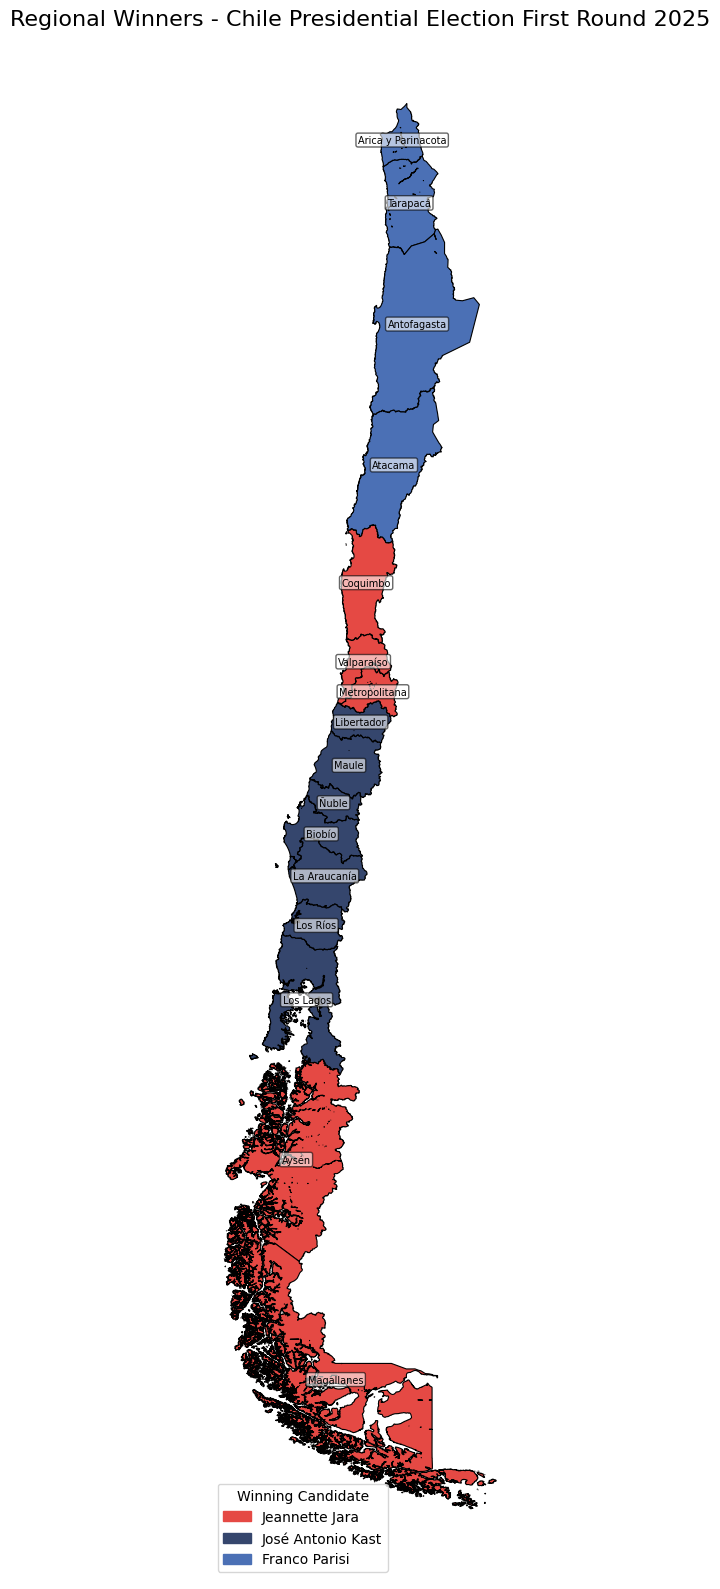

In [277]:
%matplotlib inline

import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================================
# REGIONAL WINNER CHOROPLETH
# ============================================================================

assert 'df_votes' in dir(), "Variable 'df_votes' not defined. Load data first."
assert 'communes' in dir(), "Variable 'communes' not defined. Run geographic data cell first."

# Region code lookup (numeric) for GeoDataFrame merge
REGION_TO_NUM = dict(zip(df_region_dim['region'], df_region_dim['region_code']))

# --- 1. Compute winner per region ---
regions_agg = df_votes.groupby('region').agg(
    {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
    | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
).reset_index()

regions_agg['valid_votes'] = (
    regions_agg['casted_votes'] - regions_agg['blank_votes'] - regions_agg['null_votes']
).replace(0, 1)

for cand in CANDIDATE_KEYS:
    regions_agg[f'{cand}_pct'] = regions_agg[f'{cand}_votes'] / regions_agg['valid_votes'] * 100

pct_cols        = [f'{c}_pct' for c in CANDIDATE_KEYS]
COL_PCT_TO_NAME = {f'{c}_pct': n for c, n in KEY_TO_NAME.items()}
regions_agg['winner'] = regions_agg[pct_cols].idxmax(axis=1).map(COL_PCT_TO_NAME)

regions_agg['REGION_NUM'] = regions_agg['region'].map(REGION_TO_NUM)
unmapped = regions_agg.loc[regions_agg['REGION_NUM'].isna(), 'region'].tolist()
if unmapped:
    print(f'Regions without numeric mapping: {unmapped}')

regions_agg = regions_agg.dropna(subset=['REGION_NUM'])
regions_agg['REGION_NUM'] = regions_agg['REGION_NUM'].astype(int)

# --- 2. Filter continental Chile, excluding islands and Antarctic territory ---
BBOX = dict(lon_min=-76, lon_max=-65, lat_min=-56, lat_max=-17)

communes_clean = communes.copy()
communes_clean['geometry'] = communes_clean['geometry'].buffer(0)

centroids = communes_clean.geometry.centroid
mask = (
    centroids.x.between(BBOX['lon_min'], BBOX['lon_max']) &
    centroids.y.between(BBOX['lat_min'], BBOX['lat_max'])
)
print(f'Polygons excluded (islands / Antarctic): {(~mask).sum()}')
communes_continental = communes_clean[mask].copy()

# Dissolve commune polygons into regions
regions_geom = communes_continental.dissolve(by='REGION_NUM', aggfunc='first').reset_index()
map_gdf = regions_geom.merge(regions_agg, on='REGION_NUM', how='left')
map_gdf['winner'] = map_gdf['winner'].fillna('No data')
map_gdf['color']  = map_gdf['winner'].map(CANDIDATE_COLORS)
print(f'Continental map ready: {len(map_gdf)} regions')

# --- 3. Render choropleth ---
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
map_gdf.plot(ax=ax, color=map_gdf['color'], edgecolor='black', linewidth=0.8)

for _, row in map_gdf.iterrows():
    if row.geometry and row['winner'] != 'No data':
        c = row.geometry.centroid
        label = str(row.get('region', ''))[:20]
        ax.text(c.x, c.y, label, fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

present_winners = map_gdf['winner'].unique()
patches = [
    mpatches.Patch(color=CANDIDATE_COLORS[c], label=c)
    for c in CANDIDATE_COLORS
    if c in present_winners and c != 'No data'
]
ax.legend(handles=patches, loc='lower left', title='Winning Candidate', fontsize=10)
ax.set_title('Regional Winners - Chile Presidential Election First Round 2025', fontsize=16)
ax.set_axis_off()
plt.tight_layout()

os.makedirs('regional_maps', exist_ok=True)
output_path = 'regional_maps/regional_winners_map.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Map saved to '{output_path}'")
plt.show()

### 7.2. Regional Support Gaps

In [278]:
# ============================================================================
# WINNER-RUNNER-UP GAP BY REGION
# ============================================================================

def regional_support_gaps(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the percentage difference between the winning candidate and the
    runner-up in each region, using aggregated vote totals weighted by population.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with region and candidate vote columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: region, winner, winner_percentage, runner_up,
        runner_up_percentage, difference_pct.
    """
    region_order = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    # Restrict to the 5 main candidates for gap analysis
    main_keys = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']

    cols_agg = (
        {f'{c}_votes': 'sum' for c in main_keys}
        | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
    )
    agg = df.groupby('region').agg(cols_agg).reset_index()
    agg['valid_votes'] = (
        agg['casted_votes'] - agg['blank_votes'] - agg['null_votes']
    ).replace(0, 1)

    for cand in main_keys:
        agg[f'{cand}_pct'] = (agg[f'{cand}_votes'] / agg['valid_votes']) * 100

    main_names = {
        'Jeannette Jara':    'jara_pct',
        'José Antonio Kast': 'kast_pct',
        'Franco Parisi':     'parisi_pct',
        'Johannes Kaiser':   'kaiser_pct',
        'Evelyn Matthei':    'matthei_pct',
    }

    rows = []
    for _, row in agg.iterrows():
        percentages  = {name: row[col] for name, col in main_names.items()}
        sorted_cands = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
        rows.append({
            'region':               row['region'],
            'winner':               sorted_cands[0][0],
            'winner_percentage':    round(sorted_cands[0][1], 2),
            'runner_up':            sorted_cands[1][0],
            'runner_up_percentage': round(sorted_cands[1][1], 2),
            'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
        })

    result          = pd.DataFrame(rows)
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


regional_gaps = regional_support_gaps(df_votes, df_region_dim)
display(regional_gaps)

,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica y Parinacota,Franco Parisi,27.84,Jeannette Jara,22.77,5.07
1,Tarapacá,Franco Parisi,31.11,José Antonio Kast,22.60,8.51
2,Antofagasta,Franco Parisi,34.99,Jeannette Jara,23.35,11.64
3,Atacama,Franco Parisi,32.60,Jeannette Jara,26.45,6.15
4,Coquimbo,Jeannette Jara,27.49,Franco Parisi,26.72,0.77
5,Valparaíso,Jeannette Jara,29.56,José Antonio Kast,20.26,9.30
6,Metropolitana,Jeannette Jara,31.14,José Antonio Kast,21.82,9.32
7,Libertador,José Antonio Kast,25.50,Jeannette Jara,24.49,1.01
8,Maule,José Antonio Kast,30.51,Franco Parisi,22.15,8.36
9,Ñuble,José Antonio Kast,31.64,Franco Parisi,22.10,9.54


Más allá de los ganadores absolutos, el mapa de diferencias revela una **transición gradual y compleja** del voto a lo largo del territorio chileno, con zonas de alta tensión electoral que definieron la dinámica de segunda vuelta.

#### Patrones de Competitividad y Transición Norte-Sur

El análisis de las diferencias entre primer y segundo lugar muestra un **claro gradiente geográfico**:

- **Norte Grande (Arica a Atacama)**: **Dominio claro de Parisi**. Las diferencias son amplias (entre 5 y 11,6 puntos). Parisi alcanza su peak en Antofagasta (34,99%). Jara se mantiene como segunda fuerza, pero a distancia considerable. Kast aparece relegado a un lejano tercer lugar.
- **Transición en Coquimbo**: Aquí ocurre el primer punto de inflexión. Jara gana, pero por un estrechísimo **0,77 puntos** sobre Parisi. Es la región donde el “efecto Parisi” comienza a diluirse.
- **Centro (Valparaíso y Metropolitana)**: **Consolidación de Jara**. Gana con diferencias cómodas (9,3 y 9,32 puntos sobre Kast). Es su zona de mayor fortaleza.
- **O’Higgins**: Zona de **alta transición**. Kast gana por solo **1,01 puntos** sobre Jara. Existe una clara división interna: Jara domina en comunas más urbanas (Ej: Rancagua, San Fernando), mientras Kast es más fuerte en el mundo rural y tradicional.
- **Desde Maule hasta La Araucanía**: **Reaparición de Parisi como segunda fuerza**. Kast domina con diferencias amplias (entre 8 y 12 puntos), Parisi desplaza a Jara al tercer lugar. Esta es la zona donde el voto antisistema mantiene mayor relevancia fuera del Norte.
- **Desde Los Ríos hacia el Sur**: **Regreso de Jara a la competencia**. Kast sigue ganando, pero las diferencias se reducen (2,44 en Los Ríos, 5 puntos en Los Lagos). Jara vuelve a ser segunda fuerza relevante, especialmente en Aysén y Magallanes.

#### Debilidades y Fortalezas Estructurales

- **Franco Parisi**: Muy fuerte en zonas mineras y fronterizas del Norte, pero **pierde relevancia rápidamente** en zonas urbanas y del centro del país. Su electorado parece fuertemente ligado a problemáticas territoriales específicas (migración, delincuencia, aislamiento) y menos a identidades ideológicas nacionales.
- **Jeannette Jara**: Domina las grandes áreas metropolitanas y de servicios, pero es **claramente rechazada** en el Chile rural y tradicional del centro-sur. Su apoyo se concentra en economías de servicios y zonas de mayor densidad poblacional.
- **José Antonio Kast**: Muestra la mayor **transversalidad geográfica**. Es el único candidato competitivo en casi todas las zonas (excepto el Norte Grande). Su debilidad principal está en el extremo norte.
- **Evelyn Matthei y Johannes Kaiser**: Ambos quedan relegados a roles marginales. Matthei (derecha tradicional) prácticamente desaparece del radar regional, confirmando el colapso de Chile Vamos. Kaiser solo logra presencia significativa en el sur extremo, actuando como una versión más radical de Kast.

#### Comparación con Elección Presidencial 2021 (1ª vuelta)

A diferencia de 2021, donde la derecha tradicional (Candidato Sichel) logró competir de forma más equilibrada en varias regiones del centro-sur, en 2025 **Kast consolida y radicaliza** ese espacio. El desplazamiento de Matthei hacia posiciones muy secundarias y el ascenso de Parisi como tercera fuerza nacional marcan una **reconfiguración importante** del espectro político: mayor polarización y debilitamiento de los centros tradicionales.

#### Regiones Bisagra (Decisivas para Segunda Vuelta)

Las regiones con menor diferencia entre primero y segundo lugar fueron las más estratégicas:

| Región               | Ganador (1ªV) | Diferencia 1°-2° | Característica clave           |
| -------------------- | ------------- | ---------------- | ------------------------------ |
| Coquimbo             | Jara          | **0,77**         | Frontera norte del centro      |
| Libertador O’Higgins | Kast          | **1,01**         | Máxima competitividad nacional |
| Biobío               | Kast          | 2,00             | Triple competencia             |
| Los Ríos             | Kast          | 2,44             | Transición sur                 |

Estas regiones actuaron como **laboratorios** de la segunda vuelta: pequeñas variaciones en participación o transferencia de votos podían cambiar el resultado nacional.

## 8. Results in Regional Capitals

In [279]:
# ============================================================================
# COMMUNE NAME NORMALISATION
# ============================================================================

def normalize_name(name: str) -> str:
    """
    Converts a commune name to canonical form for matching:
    lowercase, no accents, no special characters, no redundant spaces.

    Parameters
    ----------
    name : str

    Returns
    -------
    str
    """
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for orig, repl in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(orig, repl)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    return re.sub(r'\s+', ' ', name).strip()


# ============================================================================
# REGIONAL CAPITAL RESULTS
# ============================================================================

def regional_capital_results(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Filters the DataFrame to the 16 regional capitals and identifies the winning
    candidate in each with their percentage over local valid votes.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with 'commune', 'region', and candidate percentage columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: capital, region, winner, winner_percentage and individual
        percentages for the 5 main candidates.
    """
    REGIONAL_CAPITALS = [
        'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
        'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
        'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
        'Punta Arenas',
    ]

    capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
    region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    key_to_name_5 = {
        'jara':    'Jeannette Jara',
        'kast':    'José Antonio Kast',
        'parisi':  'Franco Parisi',
        'kaiser':  'Johannes Kaiser',
        'matthei': 'Evelyn Matthei',
    }

    df_tmp = df.copy()
    df_tmp['commune_norm'] = df_tmp['commune'].apply(normalize_name)
    cap_df = df_tmp[df_tmp['commune_norm'].isin(capitals_norm.keys())].copy()
    cap_df['capital'] = cap_df['commune_norm'].map(capitals_norm)

    missing = set(REGIONAL_CAPITALS) - set(cap_df['capital'].unique())
    if missing:
        print(f'Capitals not found in data: {missing}')

    cands_5    = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']
    cols_pct_5 = [f'{c}_pct' for c in cands_5]

    cap_df['winner'] = (
        cap_df[cols_pct_5].idxmax(axis=1).str.replace('_pct', '', regex=False).map(key_to_name_5)
    )
    cap_df['winner_percentage'] = cap_df[cols_pct_5].max(axis=1)

    result          = cap_df[['capital', 'region', 'winner', 'winner_percentage'] + cols_pct_5].copy()
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


capital_results = regional_capital_results(df_votes, df_region_dim)
capital_results

,capital,region,winner,winner_percentage,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,22.97,21.79,27.68,18.16,6.69
1,Iquique,Tarapacá,Jeannette Jara,25.03,25.03,23.71,24.26,15.60,8.34
2,Antofagasta,Antofagasta,Franco Parisi,32.54,24.71,17.98,32.54,12.99,8.44
3,Copiapo,Atacama,Franco Parisi,30.51,25.89,20.26,30.51,13.48,6.88
4,La Serena,Coquimbo,Jeannette Jara,28.72,28.72,18.95,21.90,14.68,12.59
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,36.34,17.11,16.59,15.23,10.67
6,Santiago,Metropolitana,Jeannette Jara,32.71,32.71,20.73,7.20,12.80,23.11
7,Rancagua,Libertador,Jeannette Jara,26.54,26.54,21.54,22.62,14.08,11.91
8,Talca,Maule,Jeannette Jara,26.65,26.65,25.36,20.15,12.97,12.03
9,Chillan,Ñuble,José Antonio Kast,27.70,22.65,27.70,20.29,15.21,11.35


### 8.1. Support Gaps in the 16 Regional Capitals

In [280]:
# ============================================================================
# WINNER-RUNNER-UP GAP IN REGIONAL CAPITALS
# ============================================================================

def capital_support_gaps(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the percentage difference between the winning candidate and the
    runner-up in each regional capital, quantifying the victory margin.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with 'commune', 'region', and candidate percentage columns.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region' and 'region_order'.

    Returns
    -------
    pd.DataFrame
        Columns: capital, region, winner, winner_percentage,
        runner_up, runner_up_percentage, difference_pct.
    """
    REGIONAL_CAPITALS = [
        'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
        'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
        'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
        'Punta Arenas',
    ]

    capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
    region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

    candidate_pct_cols = {
        'Jeannette Jara':    'jara_pct',
        'José Antonio Kast': 'kast_pct',
        'Franco Parisi':     'parisi_pct',
        'Johannes Kaiser':   'kaiser_pct',
        'Evelyn Matthei':    'matthei_pct',
    }

    df_tmp = df.copy()
    df_tmp['commune_norm'] = df_tmp['commune'].apply(normalize_name)
    cap_df = df_tmp[df_tmp['commune_norm'].isin(capitals_norm.keys())].copy()
    cap_df['capital'] = cap_df['commune_norm'].map(capitals_norm)

    rows = []
    for _, row in cap_df.iterrows():
        percentages  = {name: row[col] for name, col in candidate_pct_cols.items()}
        sorted_cands = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
        rows.append({
            'capital':              row['capital'],
            'region':               row['region'],
            'winner':               sorted_cands[0][0],
            'winner_percentage':    round(sorted_cands[0][1], 2),
            'runner_up':            sorted_cands[1][0],
            'runner_up_percentage': round(sorted_cands[1][1], 2),
            'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
        })

    result          = pd.DataFrame(rows)
    result['order'] = result['region'].map(region_order).fillna(99)
    result          = result.sort_values('order').drop(columns='order').reset_index(drop=True)
    return result


capital_gaps = capital_support_gaps(df_votes, df_region_dim)
capital_gaps

,capital,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,Jeannette Jara,22.97,4.71
1,Iquique,Tarapacá,Jeannette Jara,25.03,Franco Parisi,24.26,0.77
2,Antofagasta,Antofagasta,Franco Parisi,32.54,Jeannette Jara,24.71,7.83
3,Copiapo,Atacama,Franco Parisi,30.51,Jeannette Jara,25.89,4.62
4,La Serena,Coquimbo,Jeannette Jara,28.72,Franco Parisi,21.90,6.82
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,José Antonio Kast,17.11,19.23
6,Santiago,Metropolitana,Jeannette Jara,32.71,Evelyn Matthei,23.11,9.60
7,Rancagua,Libertador,Jeannette Jara,26.54,Franco Parisi,22.62,3.92
8,Talca,Maule,Jeannette Jara,26.65,José Antonio Kast,25.36,1.29
9,Chillan,Ñuble,José Antonio Kast,27.70,Jeannette Jara,22.65,5.05


### Análisis Urbano-Rural: La Brecha de los Dos Chiles

Uno de los hallazgos más relevantes de la primera vuelta presidencial 2025 es la **fuerte dicotomía urbano-rural**, que se manifiesta con claridad al comparar el desempeño en las capitales regionales versus el resultado general de cada región.

#### Control de Capitales vs Control Territorial

| Candidato             | Capitales Ganadas | % Capitales | Regiones Ganadas | % Regiones | Interpretación Principal     |
| --------------------- | ----------------- | ----------- | ---------------- | ---------- | ---------------------------- |
| **Jeannette Jara**    | **10 / 16**       | **62.5%**   | 5 / 16           | 31.3%      | **Fenómeno urbano**          |
| **José Antonio Kast** | **4 / 16**        | **25.0%**   | 7 / 16           | 43.8%      | **Fenómeno rural**           |
| **Franco Parisi**     | **2 / 16**        | **12.5%**   | 4 / 16           | 25.0%      | Fenómeno norteño territorial |
| Matthei / Kaiser      | 0                 | 0%          | 0                | 0%         | Marginales                   |

**Hallazgo central**: Jara domina los **centros de poder urbano** (10 de 16 capitales), mientras Kast controla el **territorio regional** (7 regiones). Esta brecha explica en gran medida la dinámica de la segunda vuelta: Jara tenía ventaja en densidad poblacional, pero Kast contaba con mayor amplitud territorial.

#### Patrones en Capitales Regionales

- **Jara** domina las capitales del centro y sur: Valparaíso (36.34%), Santiago (32.71%), Valdivia (31.03%), Concepción (28.00%), La Serena (28.72%), entre otras. Su fortaleza se concentra en ciudades de servicios, administración y mayor densidad.
- **Parisi** gana las capitales del Norte Grande (Arica, Antofagasta, Copiapó), pero pierde fuerza rápidamente fuera de esa zona.
- **Kast** gana capitales más sureñas y tradicionales: Chillán, Temuco y Puerto Montt. Su apoyo en ciudades es más limitado que en el hinterland rural.

**Capitales más competitivas** (diferencias menores):

- Iquique (empate técnico Jara-Kast al 25.03%)
- Rancagua y Talca (diferencias moderadas)

#### Análisis por Candidato en Capitales

**Jeannette Jara – Fortaleza Urbana** Jara ganó 10 capitales regionales, confirmando su rol como candidata de las grandes ciudades. Sin embargo, incluso en sus bastiones urbanos, rara vez supera el 35%, lo que indica que su apoyo no es abrumador ni monolítico.

**José Antonio Kast – Transición Rural-Urbana** Kast muestra mejor desempeño relativo en capitales del sur (Temuco, Puerto Montt, Chillán) que en el norte o centro. Su crecimiento en ciudades sureñas indica una expansión más allá del mundo puramente rural.

**Franco Parisi – Debilidad Urbana** Parisi es significativamente más débil en capitales que en el promedio regional (especialmente fuera del norte). Esto refuerza que su voto es más fuerte en comunas rurales, mineras y fronterizas que en centros urbanos consolidados.

**Evelyn Matthei – Crisis de la Derecha Tradicional** Matthei obtiene su mejor resultado en Santiago (23.11%, segundo lugar), pero promedia solo ~10.8% en capitales regionales. Queda confirmada su **subrepresentación urbana** y su reducción a nichos elitistas.

**Johannes Kaiser – Fenómeno Urbano-Joven** Sorprendentemente, Kaiser tiene mejor performance en capitales (~15.4%) que a nivel nacional (13.94%). Destaca especialmente en Coyhaique (20.62%) y Punta Arenas (17.23%), sugiriendo que su electorado es más urbano, joven y profesional que rural-tradicional.

#### Implicaciones Estratégicas

La brecha urbano-rural define dos lógicas electorales opuestas:

- **Jara** necesita maximizar la participación en las grandes ciudades y capitales para compensar su menor cobertura territorial.
- **Kast** debe transformar su dominio regional y rural en mayor movilización urbana, especialmente en las capitales del centro-sur.
- Las capitales actúan como **multiplicadores de voto** por su peso demográfico, pero el hinterland rural entrega volumen territorial y legitimidad.

Esta división explica por qué la segunda vuelta se convirtió en una **batalla entre densidad urbana (Jara)** y **amplitud territorial (Kast)**.

## 9. Electoral Behavior in Urban Centers

### 9.1. Large Urban Centers (> 200,000 inhabitants)

In [281]:
# ============================================================================
# LARGE URBAN CENTERS (> 200,000 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_urban = df_merged[df_merged['population'] > 200_000].copy()
df_urban = df_urban.sort_values('population', ascending=False)

pop_total    = df_urban['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_urban)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_urban[col] = df_urban[col].astype(float)
df_urban['winner'] = df_urban[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_urban[df_urban['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_urban[df_urban['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 21
Population covered: 6,443,321 (35.4% national)

NORTE GRANDE (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
0,Antofagasta,Antofagasta,Norte Grande,401096,255984,24.71,17.98,32.54,12.99,8.44,Franco Parisi



NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
68,Coquimbo,Coquimbo,Norte Chico,263719,167795,27.48,18.32,25.85,14.38,10.78,Jeannette Jara
78,la Serena,Coquimbo,Norte Chico,250141,174173,28.72,18.95,21.90,14.68,12.59,Jeannette Jara



CENTRO (14 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
104,Temuco,La Araucanía,Centro Sur,292518,211836,22.05,29.36,18.00,15.67,11.74,José Antonio Kast
38,Concepcion,Biobío,Centro Sur,230375,171339,28.00,24.22,16.42,13.33,14.51,Jeannette Jara
64,los Angeles,Biobío,Centro Sur,219441,159128,14.57,32.23,25.70,16.12,9.15,José Antonio Kast



SUR (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
161,Puerto Montt,Los Lagos,Sur,277040,185344,21.78,26.81,20.61,16.26,11.51,José Antonio Kast



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,16,4957092,76.9,3467640
1,José Antonio Kast,3,788999,12.2,556308
2,Franco Parisi,1,401096,6.2,255984
3,Evelyn Matthei,1,296134,4.6,222675


**Hallazgo clave**: Jara no solo ganó la gran mayoría de las comunas grandes (16 de 21), sino que **controló el 76,9% de la población** de este segmento estratégico. Esto confirma que **su principal motor de voto fue el Chile urbano denso**.

#### Relación entre Tamaño Poblacional y Voto a Jara

**Sí existe una relación clara y positiva**:

- A mayor población de la comuna → **mayor porcentaje de voto a Jara** (en promedio).
- Jara obtiene sus mejores resultados en las comunas más pobladas del país (Maipú 36,40%, Puente Alto 35,57%, Santiago 32,71%, La Florida 35,16%, etc.).
- En cambio, en las comunas grandes donde **no domina** (Las Condes, Temuco, Los Ángeles, Puerto Montt), su porcentaje cae drásticamente.

**Patrón observado**:

- Comunas **muy grandes** (> 300.000 hab.): Jara promedia **~33-36%**.
- Comunas grandes **intermedias** (200.000-300.000 hab.): Jara promedia **~28-31%**.
- Las excepciones donde Jara pierde son comunas con perfil socioeconómico distinto (Las Condes = elite; Temuco y Los Ángeles = más rurales/tradicionales dentro de su tamaño).

#### Interpretación Estratégica

**El fuerte de Jara fueron las grandes ciudades** Su campaña se construyó sobre el **Chile urbano-popular y de servicios**. Estas 16 comunas grandes le entregaron:

- Volumen masivo de votos (más de 3,46 millones).
- Alta densidad electoral (fácil de movilizar).
- Legitimidad en los centros de poder mediático y político.

Esto explica por qué Jara ganó la primera vuelta a pesar de tener menos comunas totales que Kast: **las grandes ciudades pesan mucho más en votos absolutos**.

**Kast y Parisi en este segmento**:

- Kast logra penetrar algunas comunas grandes del sur (Temuco, Los Ángeles, Puerto Montt), pero con menor intensidad.
- Parisi solo logra Antofagasta, confirmando su debilidad estructural en grandes centros urbanos fuera del Norte.

#### Conclusión: La Fuerza Urbana de Jara

Existe una **fuerte correlación positiva** entre el tamaño poblacional de las comunas y el porcentaje de voto a Jeannette Jara. Su performance mejora notablemente en las ciudades más grandes y densas del país.

Esto revela que Jara fue **la candidata del Chile urbano-metropolitano**, mientras Kast fue la del Chile rural y semi-rural. Esta brecha urbano-rural fue uno de los ejes centrales de la elección 2025 y explica tanto su victoria en primera vuelta (por peso demográfico) como sus dificultades posteriores (falta de amplitud territorial).

### 9.2. Medium Urban Centers (100,000 – 199,999 inhabitants)

In [282]:
# ============================================================================
# MEDIUM URBAN CENTERS (100,000 - 199,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_medium = df_merged[(df_merged['population'] >= 100_000) & (df_merged['population'] <= 199_999)].copy()
df_medium = df_medium.sort_values('population', ascending=False)

pop_total    = df_medium['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_medium)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_medium[col] = df_medium[col].astype(float)
df_medium['winner'] = df_medium[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_medium[df_medium['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_medium[df_medium['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 35
Population covered: 5,063,889 (27.8% national)

NORTE GRANDE (3 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
284,Iquique,Tarapacá,Norte Grande,199587,131590,25.03,23.71,24.26,15.60,8.34,Jeannette Jara
1,Calama,Antofagasta,Norte Grande,166334,108350,18.69,19.28,38.98,14.37,6.09,Franco Parisi
280,Alto Hospicio,Tarapacá,Norte Grande,142086,60526,17.08,20.12,42.94,12.63,4.74,Franco Parisi



NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
16,Copiapo,Atacama,Norte Chico,168831,111212,25.89,20.26,30.51,13.48,6.88,Franco Parisi
71,Ovalle,Coquimbo,Norte Chico,118696,83715,24.73,20.40,31.41,13.16,7.77,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
184,Valdivia,Los Ríos,Sur,170043,125638,31.03,22.09,16.98,14.47,11.94,Jeannette Jara
159,Osorno,Los Lagos,Sur,166455,126161,24.75,24.58,21.02,16.46,10.19,Jeannette Jara



PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
193,Punta Arenas,Magallanes,Patagonia,132363,96811,28.8,22.89,16.54,17.23,10.48,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,21,3014611,59.5,2106407
1,José Antonio Kast,8,1185709,23.4,779985
2,Franco Parisi,5,719595,14.2,448382
3,Evelyn Matthei,1,143974,2.8,123633


**Hallazgo principal**: Jara **mantiene su dominio** en los centros urbanos medianos, aunque con menor intensidad que en las grandes ciudades. Su control de población baja de **76,9%** a **59,5%**, mientras Kast reaparece con mayor fuerza.

#### Comparación de Desempeño

**Jeannette Jara**:

- Sigue siendo la candidata más fuerte, ganando **21 de 35 comunas** (60%).
- Su porcentaje promedio se mantiene sólido (~30-35% en muchas comunas del Centro).
- Pierde terreno relativo respecto a las grandes ciudades, especialmente en zonas de transición (Centro Sur y Sur).

**José Antonio Kast**:

- **Reaparece con fuerza**. Gana 8 comunas medianas (23,4% de la población del segmento), especialmente en Maule, Ñuble, Biobío y Los Lagos.
- Muestra una **mejor penetración** en este tamaño de ciudad que en las grandes metrópolis, donde estaba más limitado.

**Franco Parisi**:

- Gana 5 comunas (principalmente en Norte Grande y Norte Chico: Calama, Alto Hospicio, Copiapó, Ovalle).
- Su peso en este segmento es moderado (14,2%), confirmando que su apoyo es más fuerte en ciudades medianas del norte que en las grandes urbes.

**Evelyn Matthei**:

- Solo gana 1 comuna (Providencia), manteniendo un rol marginal.

#### Patrones Observados

1. **Centro (RM + Valparaíso)**: Jara sigue dominando claramente la mayoría de las comunas medianas (Estación Central, La Pintana, Recoleta, San Miguel, etc.). Su base urbano-popular se mantiene sólida.
2. **Transición Centro-Sur**: Kast gana varias comunas medianas importantes (Chillán, Curicó, Melipilla, Buin). Aquí se ve el **reaparecimiento** de Kast, aprovechando un perfil más tradicional y ruralizado dentro de las ciudades medianas.
3. **Norte**: Parisi domina las comunas medianas del norte (Alto Hospicio, Copiapó), mientras Jara compite mejor en Iquique y La Serena.
4. **Sur**: Jara mantiene presencia en Valdivia y Osorno, pero Kast es competitivo.

**Conclusión de la comparación**:

- **Jara** es claramente la candidata de las **ciudades grandes**, donde su ventaja es abrumadora. En las ciudades medianas mantiene liderazgo, pero su dominio se debilita.
- **Kast** mejora su performance a medida que el tamaño de la ciudad disminuye. Muestra mayor capacidad de penetración en centros urbanos medianos del centro-sur.
- Esto refuerza la **brecha urbano-rural**: mientras más grande y denso es el centro urbano, más fuerte es Jara. A medida que bajamos de tamaño (hacia ciudades medianas), Kast recupera terreno de forma significativa.

Este patrón sugiere que el voto de Jara tiene una **fuerte componente de escala urbana**: mientras más población y densidad, mejor le va. Kast, en cambio, tiene mejor performance en entornos urbanos más “intermedios” y cercanos a lo rural.

### 9.3. Small Urban Centers (50,000 – 99,999 inhabitants)

In [283]:
# ============================================================================
# SMALL URBAN CENTERS (50,000 - 99,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_small = df_merged[(df_merged['population'] >= 50_000) & (df_merged['population'] <= 99_999)].copy()
df_small = df_small.sort_values('population', ascending=False)

pop_total    = df_small['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_small)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_small[col] = df_small[col].astype(float)
df_small['winner'] = df_small[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_small[df_small['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_small[df_small['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 33
Population covered: 2,493,250 (13.7% national)

NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
21,Vallenar,Atacama,Norte Chico,54222,39834,25.87,18.46,33.63,13.71,5.84,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
313,San Antonio,Valparaíso,Centro,96770,71777,34.45,18.02,22.75,12.25,8.97,Jeannette Jara
309,Quillota,Valparaíso,Centro,96753,69955,25.40,22.74,22.55,15.52,10.40,Jeannette Jara
207,Linares,Maule,Centro,96744,76027,21.51,29.84,21.97,14.87,9.49,José Antonio Kast
252,Pedro Aguirre Cerda,Metropolitana,Centro,96062,75390,41.90,16.76,15.05,11.75,10.56,Jeannette Jara
264,San Joaquin,Metropolitana,Centro,95602,69365,39.29,17.29,14.16,12.31,13.16,Jeannette Jara
253,Peñaflor,Metropolitana,Centro,94402,68197,31.07,19.20,20.28,13.82,11.95,Jeannette Jara
245,Lo Prado,Metropolitana,Centro,91290,70486,35.68,18.97,17.02,12.90,11.74,Jeannette Jara
277,la Reina,Metropolitana,Centro,89870,75601,27.56,22.35,4.70,12.69,29.38,Evelyn Matthei
244,Lo Espejo,Metropolitana,Centro,87295,70863,37.10,17.86,21.58,11.12,8.69,Jeannette Jara
272,Vitacura,Metropolitana,Centro,86420,70359,7.20,35.14,0.82,12.90,42.45,Evelyn Matthei



CENTRO SUR (7 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
163,Puerto Varas,Los Lagos,Sur,52942,42063,20.8,28.73,13.43,17.54,16.66,José Antonio Kast



PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
26,Coyhaique,Aysén,Patagonia,57823,40606,26.76,22.83,15.58,20.62,11.4,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,19,1534479,61.5,1144301
1,José Antonio Kast,11,728259,29.2,534083
3,Evelyn Matthei,2,176290,7.1,145960
2,Franco Parisi,1,54222,2.2,39834


#### Patrones Principales

1. **Jara mantiene el liderazgo, pero sin la misma fuerza**
   - Gana **19 de 33 comunas** (57,6%) y controla el **61,5%** de la población del segmento.
   - Su dominio se sostiene principalmente en el **Centro** (RM + Valparaíso), donde sigue siendo muy fuerte (San Antonio, Quillota, San Joaquín, Lo Espejo, etc.).
2. **Kast sigue ganando terreno**
   - Gana **11 comunas** (29,2% de la población del segmento).
   - Su presencia es especialmente notable en el **Centro Sur** (Hualpén, Chiguayante, Padre las Casas, Villarrica, Angol, etc.) y en algunas comunas del Maule y Libertador.
3. **Matthei y Parisi tienen roles marginales**
   - Matthei gana 2 comunas (La Reina y Vitacura) — ambas de perfil socioeconómico alto.
   - Parisi solo gana 1 comuna (Vallenar).

#### Comparación con Segmentos Anteriores

| Aspecto                       | Grandes (>200k)   | Medianos (100-199k) | **Pequeños (50-99k)** | Tendencia     |
| ----------------------------- | ----------------- | ------------------- | --------------------- | ------------- |
| Dominio de Jara (% población) | **76.9%**         | 59.5%               | 61.5%                 | Se estabiliza |
| Presencia de Kast             | Baja              | Media-Alta          | **Alta**              | **Aumenta**   |
| Competitividad general        | Baja (Jara clara) | Media               | **Alta**              | Aumenta       |
| Rol de Parisi                 | Muy bajo          | Moderado            | Bajo                  | Disminuye     |

**Similitudes con lo anterior**:

- Jara sigue siendo la candidata más fuerte en el mundo urbano, incluso en ciudades más pequeñas.
- El **Centro** (RM + Valparaíso) continúa siendo su principal bastión.

**Diferencias clave**:

- **Kast mejora significativamente** su desempeño a medida que el tamaño de la ciudad disminuye. En las ciudades pequeñas del Centro Sur y Sur logra varios triunfos importantes.
- La brecha urbano-rural se hace más evidente: mientras más pequeño es el centro urbano, más se acerca al comportamiento rural (donde Kast es mucho más fuerte).
- Aparecen más comunas “mixtas” o de transición, donde Kast compite de igual a igual o gana (ej. Linares, Talagante, Rengo, Maule, etc.).
- Matthei solo logra relevancia en comunas de alto nivel socioeconómico (Vitacura, La Reina), confirmando su nicho elitista.

### 9.4. Rural–Urban Centers (10,000 – 49,999 inhabitants)

In [284]:
# ============================================================================
# RURAL–URBAN CENTERS (10,000 – 49,999 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_small = df_merged[(df_merged['population'] >= 10_000) & (df_merged['population'] <= 49_999)].copy()
df_small = df_small.sort_values('population', ascending=False)

pop_total    = df_small['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_small)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_small[col] = df_small[col].astype(float)
df_small['winner'] = df_small[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_small[df_small['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_small[df_small['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)

Communes: 164
Population covered: 3,736,021 (20.5% national)

NORTE GRANDE (4 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
8,Tocopilla,Antofagasta,Norte Grande,25400,17152,26.62,14.93,40.50,10.11,5.18,Franco Parisi
286,Pozo Almonte,Tarapacá,Norte Grande,16878,10079,17.88,20.11,41.39,13.88,4.53,Franco Parisi
3,Mejillones,Antofagasta,Norte Grande,14084,8827,26.99,15.23,38.47,10.93,5.81,Franco Parisi
7,Taltal,Antofagasta,Norte Grande,12097,8260,26.63,16.72,36.91,11.79,5.27,Franco Parisi



NORTE CHICO (12 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
69,Illapel,Coquimbo,Norte Chico,32009,24582,30.98,18.32,29.52,10.65,7.91,Jeannette Jara
70,Monte Patria,Coquimbo,Norte Chico,29997,24152,20.94,19.62,39.17,12.08,5.66,Franco Parisi
76,Vicuña,Coquimbo,Norte Chico,28047,22040,26.08,19.92,29.77,13.80,8.09,Franco Parisi
75,Salamanca,Coquimbo,Norte Chico,27823,20969,26.97,20.31,28.64,13.63,8.00,Franco Parisi
79,los Vilos,Coquimbo,Norte Chico,22879,16939,31.99,19.49,22.90,13.07,9.76,Jeannette Jara
14,Caldera,Atacama,Norte Chico,18805,14170,30.46,16.13,29.27,14.39,7.20,Jeannette Jara
67,Combarbala,Coquimbo,Norte Chico,12954,10326,28.91,18.88,27.42,12.97,9.35,Jeannette Jara
15,Chañaral,Atacama,Norte Chico,12345,9399,30.99,16.08,34.59,10.11,5.88,Franco Parisi
73,Punitaqui,Coquimbo,Norte Chico,12076,9710,22.06,17.25,41.07,12.23,5.43,Franco Parisi
20,Tierra Amarilla,Atacama,Norte Chico,11846,10694,20.84,18.12,42.59,11.80,4.22,Franco Parisi



CENTRO (69 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
147,Castro,Los Lagos,Sur,46997,35536,26.00,24.09,24.06,13.31,9.39,Jeannette Jara
145,Ancud,Los Lagos,Sur,40949,32767,23.05,27.69,22.94,14.66,8.61,José Antonio Kast
185,la Union,Los Ríos,Sur,38907,31427,20.50,28.05,22.49,16.72,9.73,José Antonio Kast
146,Calbuco,Los Lagos,Sur,36474,27680,18.31,31.97,24.86,13.75,8.46,José Antonio Kast
182,Panguipulli,Los Ríos,Sur,35098,29642,19.74,31.16,21.67,16.50,8.10,José Antonio Kast
183,Rio Bueno,Los Ríos,Sur,33363,26629,18.71,29.64,21.64,17.79,9.71,José Antonio Kast
168,Quellon,Los Lagos,Sur,28460,20492,19.83,26.48,30.19,14.55,6.29,Franco Parisi
180,Mariquina,Los Ríos,Sur,22973,18106,20.79,26.80,28.29,13.32,8.23,Franco Parisi
154,Frutillar,Los Lagos,Sur,22554,17874,20.54,28.05,21.76,17.89,9.78,José Antonio Kast
186,los Lagos,Los Ríos,Sur,21431,16762,19.05,31.33,22.91,16.28,8.15,José Antonio Kast



PATAGONIA (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
190,Natales,Magallanes,Patagonia,24152,17388,30.22,25.06,16.37,15.14,9.01,Jeannette Jara
22,Aysen,Aysén,Patagonia,23170,17357,27.41,21.91,21.74,17.83,7.98,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,98,2162856,57.9,1743012
0,Jeannette Jara,33,859268,23.0,671278
2,Franco Parisi,33,713897,19.1,560779


**Hallazgo clave**: **Kast domina claramente** este segmento. Gana **98 de 164 comunas** y controla el **57,9%** de la población, convirtiéndose en el candidato indiscutido de las comunas de tamaño intermedio-rural.

#### Patrones Observados

1. **Dominio contundente de Kast**
   - Kast es el gran ganador en este rango de población. Su apoyo se consolida especialmente en el **Centro Sur y Sur** (La Araucanía, Ñuble, Biobío, Los Lagos).
   - Muchas de estas comunas tienen un perfil semi-rural, agrícola, forestal o con fuerte identidad local.
2. **Jara pierde fuerza progresivamente**
   - Solo gana 33 comunas (23% de la población del segmento).
   - Su apoyo se concentra en algunas comunas del Norte Chico y Centro, pero es claramente minoritaria en el sur.
3. **Parisi mantiene presencia en el Norte**
   - Gana 33 comunas, principalmente en Norte Grande y Norte Chico (Tocopilla, Pozo Almonte, Mejillones, etc.). Su voto sigue siendo fuerte en zonas mineras y fronterizas de menor tamaño.

#### Comparación Completa por Tamaño de Comuna

| Segmento de Población    | % Población Controlada por Jara | % Población Controlada por Kast | Candidato Dominante | Característica Principal |
| ------------------------ | ------------------------------- | ------------------------------- | ------------------- | ------------------------ |
| Grandes (>200k)          | **76.9%**                       | 12.2%                           | **Jara**            | Metrópolis densas        |
| Medianos (100-199k)      | 59.5%                           | 23.4%                           | **Jara**            | Ciudades intermedias     |
| Pequeños (50-99k)        | 61.5%                           | 29.2%                           | **Jara**            | Ciudades pequeñas        |
| **Rural-Urban (10-49k)** | 23.0%                           | **57.9%**                       | **Kast**            | Comunas semi-rurales     |

**El patrón es muy claro**:

- Mientras **más grande** es la comuna → **Jara domina** (fenómeno urbano).
- Mientras **más pequeña** es la comuna → **Kast domina** (fenómeno rural/semi-rural).
- Se produce un **cambio de tendencia** alrededor de las 50.000-100.000 habitantes, donde Kast empieza a ganar terreno de forma acelerada.

#### Interpretación Estratégica

Este gradiente urbano-rural explica gran parte del resultado de la elección:

- **Jara** construyó su victoria en primera vuelta sobre las **ciudades grandes y densas** (alta eficiencia en votos por comuna).
- **Kast** construyó su fuerza en el **territorio amplio** (alta cantidad de comunas pequeñas y medianas), lo que le dio mayor cobertura geográfica y una base más resistente para la segunda vuelta.

La brecha es estructural: Jara representa el **Chile urbano-metropolitano**, mientras Kast representa el **Chile rural, provincial y tradicional**. Esta división fue uno de los ejes fundamentales de la polarización electoral 2025.

### 9.5. Rural Localities (< 10,000 inhabitants)

In [285]:
# ============================================================================
# RURAL LOCALITIES (< 10,000 INHABITANTS)
# ============================================================================

# ============================================================================
# SHARED SETUP: NORMALIZATION, CANDIDATE MAP, DATA LOAD AND MERGE
# ============================================================================

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

# Load source data
df_votes      = pd.read_csv(url_votes, encoding='utf-8-sig')
df_pop        = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

df_votes['commune_norm'] = df_votes['commune'].apply(normalize_name)
df_pop['commune_norm']   = df_pop['commune'].apply(normalize_name)

df_merged = df_votes.merge(
    df_pop[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

candidates_5 = ['jara','kast','parisi','kaiser','matthei']
pct_cols     = [f'{c}_pct' for c in candidates_5]

df_rural = df_merged[df_merged['population'] < 10_000].copy()
df_rural = df_rural.sort_values('population', ascending=False)

pop_total    = df_rural['population'].sum()
pop_national = df_merged['population'].sum()
print(f'Communes: {len(df_rural)}')
print(f'Population covered: {pop_total:,} ({pop_total/pop_national*100:.1f}% national)')

# Determine commune winner
for col in pct_cols:
    df_rural[col] = df_rural[col].astype(float)
df_rural['winner'] = df_rural[pct_cols].idxmax(axis=1).str.replace('_pct','',regex=False).map(CANDIDATE_NAMES)

# Tables by macrozone (north to south)
table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    df_zone = df_rural[df_rural['macrozone'] == zone]
    if len(df_zone) > 0:
        print(f'\n{zone.upper()} ({len(df_zone)} communes)')
        print('-'*80)
        display(df_zone[table_cols].round(2))

# Candidate summary
print('\nSUMMARY BY CANDIDATE')
stats_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = df_rural[df_rural['winner'] == cname]
    if len(subset) == 0:
        continue
    stats_rows.append({
        'candidate':       cname,
        'communes_won':    len(subset),
        'total_population':int(subset['population'].sum()),
        'pct_pop_segment': round(subset['population'].sum() / pop_total * 100, 1),
        'casted_votes':    int(subset['casted_votes'].sum()),
    })
df_stats = pd.DataFrame(stats_rows).sort_values('communes_won', ascending=False)
display(df_stats)


Communes: 90
Population covered: 475,064 (2.6% national)

NORTE GRANDE (11 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
5,San Pedro de Atacama,Antofagasta,Norte Grande,9843,6722,31.88,14.37,33.84,10.34,6.24,Franco Parisi
285,Pica,Tarapacá,Norte Grande,6272,5233,22.26,19.76,33.41,16.41,5.86,Franco Parisi
2,Maria Elena,Antofagasta,Norte Grande,4834,3261,22.27,15.15,45.86,9.24,4.69,Franco Parisi
283,Huara,Tarapacá,Norte Grande,2858,2726,16.89,25.89,36.96,13.34,4.95,Franco Parisi
12,Putre,Arica y Parinacota,Norte Grande,1547,2169,15.76,28.06,31.29,16.24,6.17,Franco Parisi
6,Sierra Gorda,Antofagasta,Norte Grande,1472,1081,22.84,16.30,41.90,12.13,5.02,Franco Parisi
281,Camiña,Tarapacá,Norte Grande,1335,1730,7.21,35.93,43.09,10.58,2.84,Franco Parisi
10,Camarones,Arica y Parinacota,Norte Grande,861,1467,19.77,21.82,30.75,16.68,8.44,Franco Parisi
282,Colchane,Tarapacá,Norte Grande,790,1223,2.06,31.90,57.30,6.68,0.99,Franco Parisi
11,General Lagos,Arica y Parinacota,Norte Grande,508,634,7.62,28.69,48.95,9.56,4.21,Franco Parisi



NORTE CHICO (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
66,Canela,Coquimbo,Norte Chico,9639,8004,34.47,19.82,27.39,9.05,6.34,Jeannette Jara
19,Huasco,Atacama,Norte Chico,9369,7405,30.20,14.99,34.24,13.20,4.93,Franco Parisi
18,Freirina,Atacama,Norte Chico,7577,5575,27.28,15.89,39.54,10.06,5.23,Franco Parisi
13,Alto del Carmen,Atacama,Norte Chico,4788,3810,20.93,16.85,43.16,11.06,5.87,Franco Parisi
72,Paihuano,Coquimbo,Norte Chico,4649,4469,25.98,20.63,24.70,14.48,11.20,Jeannette Jara
77,la Higuera,Coquimbo,Norte Chico,4335,4108,27.69,17.11,33.98,11.89,6.91,Franco Parisi
74,Rio Hurtado,Coquimbo,Norte Chico,4334,4003,19.27,25.86,30.10,14.14,8.04,Franco Parisi



CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
156,Hualaihue,Los Lagos,Sur,9480,7846,20.19,29.38,21.10,17.53,9.02,José Antonio Kast
162,Puerto Octay,Los Lagos,Sur,8865,7872,25.50,23.26,27.18,15.31,6.72,Franco Parisi
169,Quemchi,Los Lagos,Sur,8409,6985,19.93,31.75,25.36,13.20,6.89,José Antonio Kast
179,Mafil,Los Ríos,Sur,8074,6581,18.56,29.48,25.58,15.96,8.00,José Antonio Kast
172,San Juan de la Costa,Los Lagos,Sur,7776,7242,25.90,24.46,24.46,14.91,7.19,Jeannette Jara
170,Quinchao,Los Lagos,Sur,7678,6179,26.56,25.07,28.41,9.98,7.42,Franco Parisi
167,Queilen,Los Lagos,Sur,5690,4563,23.70,25.26,31.27,10.96,6.74,Franco Parisi
175,Corral,Los Ríos,Sur,5501,4589,28.46,24.01,21.62,16.15,7.25,Jeannette Jara
150,Cochamo,Los Lagos,Sur,4199,3671,16.94,34.87,15.22,20.91,8.52,José Antonio Kast
164,Puqueldon,Los Lagos,Sur,4048,3517,21.30,23.78,38.18,8.61,5.89,Franco Parisi



PATAGONIA (16 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
191,Porvenir,Magallanes,Patagonia,6809,4102,31.11,26.07,18.81,14.51,6.74,Jeannette Jara
24,Cisnes,Aysén,Patagonia,5137,3736,24.28,24.99,15.33,25.86,7.20,Johannes Kaiser
23,Chile Chico,Aysén,Patagonia,4905,3681,35.45,21.50,11.54,20.20,8.29,Jeannette Jara
25,Cochrane,Aysén,Patagonia,3458,2402,28.29,24.64,11.44,22.92,10.21,Jeannette Jara
30,Rio Ibañez,Aysén,Patagonia,2723,2310,25.87,25.60,11.77,22.78,11.28,Jeannette Jara
27,Guaitecas,Aysén,Patagonia,1598,1076,23.46,32.63,21.14,11.49,8.59,José Antonio Kast
28,Lago Verde,Aysén,Patagonia,779,779,26.38,28.31,12.15,23.90,7.32,José Antonio Kast
29,O'higgins,Aysén,Patagonia,647,458,24.94,31.97,8.39,23.58,8.39,José Antonio Kast
31,Tortel,Aysén,Patagonia,505,417,30.53,18.07,16.03,22.65,9.16,Jeannette Jara
192,Primavera,Magallanes,Patagonia,431,402,30.36,20.66,19.39,13.01,13.27,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,48,284287,59.8,253974
2,Franco Parisi,23,104120,21.9,89102
0,Jeannette Jara,15,76314,16.1,63353
3,Johannes Kaiser,4,10343,2.2,7910


**Hallazgo clave**: En las comunas más pequeñas y rurales de Chile, **José Antonio Kast logra su dominio más absoluto**. Controla aproximadamente el 60% de la población de este segmento y gana la gran mayoría de estas comunas.

#### Patrones Observados en Comunas Muy Pequeñas

- **Kast arrasa en el Centro Sur y Sur**: Domina casi por completo en Maule, Ñuble, Biobío, La Araucanía, Los Ríos y Los Lagos. Comunas como Chanco (46,61%), Empedrado (44,39%), Lumaco, Contulmo, etc., son bastiones muy fuertes.
- **Parisi mantiene monopolio en el Norte Chico y Grande**: Gana la mayoría de las comunas muy pequeñas del norte (Ollagüe 58,17%, Colchane, María Elena, etc.), donde su discurso antisistema y de frontera resuena fuertemente.
- **Jara se mantiene solo en algunos enclaves**: Principalmente en Patagonia (Coyhaique, Natales) y algunas comunas aisladas del Centro (Juan Fernández, Isla de Pascua).

#### Gradiente Completa Urbano-Rural

| Tamaño de Comuna  | % Pobl. Controlada por Jara | % Pobl. Controlada por Kast | Candidato Dominante | Tipo de Voto      |
| ----------------- | --------------------------- | --------------------------- | ------------------- | ----------------- |
| > 200.000 hab.    | **76.9%**                   | 12.2%                       | **Jara**            | Urbano denso      |
| 100.000 – 199.999 | 59.5%                       | 23.4%                       | Jara                | Urbano intermedio |
| 50.000 – 99.999   | 61.5%                       | 29.2%                       | Jara                | Urbano pequeño    |
| 10.000 – 49.999   | 23.0%                       | **57.9%**                   | **Kast**            | Semi-rural        |
| **< 10.000 hab.** | ~16%                        | **~60%**                    | **Kast**            | Rural profundo    |

**El patrón es clarísimo y consistente**:

- **Jara** es la candidata de las **ciudades grandes y densas**. Su apoyo disminuye drásticamente a medida que baja el tamaño de la comuna.
- **Kast** es la candidato del **Chile rural y provincial**. Su apoyo aumenta progresivamente a medida que las comunas son más pequeñas y alejadas de los grandes centros urbanos.
- **Punto de inflexión**: Alrededor de las **50.000 habitantes** se produce el cambio de tendencia más marcado.

### 9.6. Population Segmentation Overview

POPULATION SEGMENTATION ANALYSIS


,segment,total_communes,total_pop,top_winner,top_winner_pct,turnout
0,Large Urban\n> 200k,21,6443321,Jeannette Jara,76.19,69.88
1,Medium Urban\n100k-199k,35,5063889,Jeannette Jara,60.00,68.30
2,Small Urban\n50k-99k,33,2493250,Jeannette Jara,57.58,74.77
3,Rural-Urban\n10k-49k,164,3736021,José Antonio Kast,59.76,79.63
4,Rural\n< 10k,90,475064,José Antonio Kast,53.33,87.22


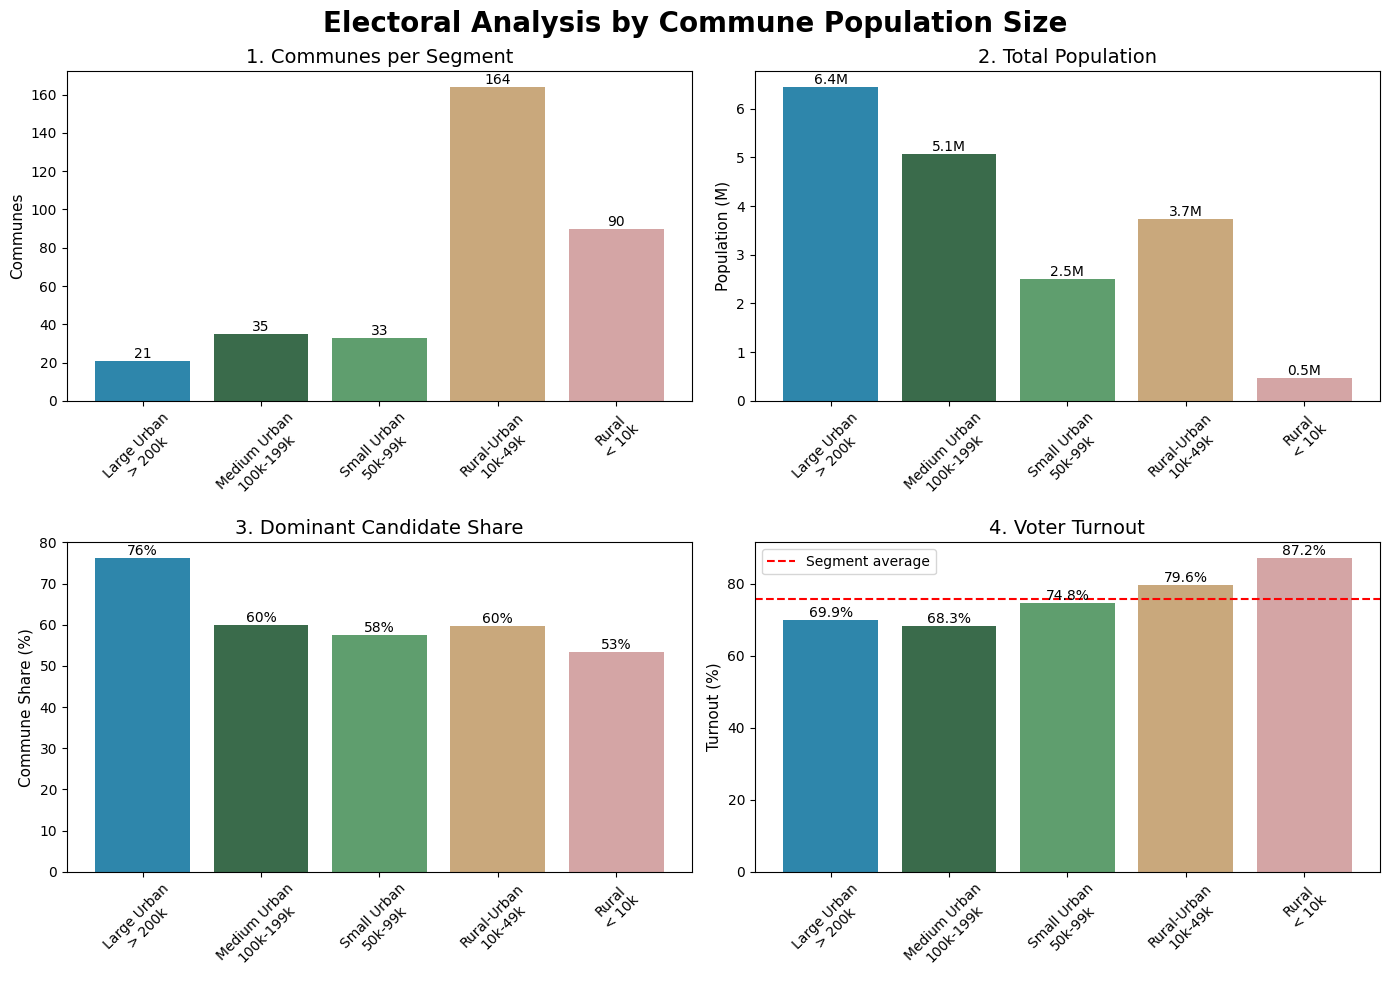

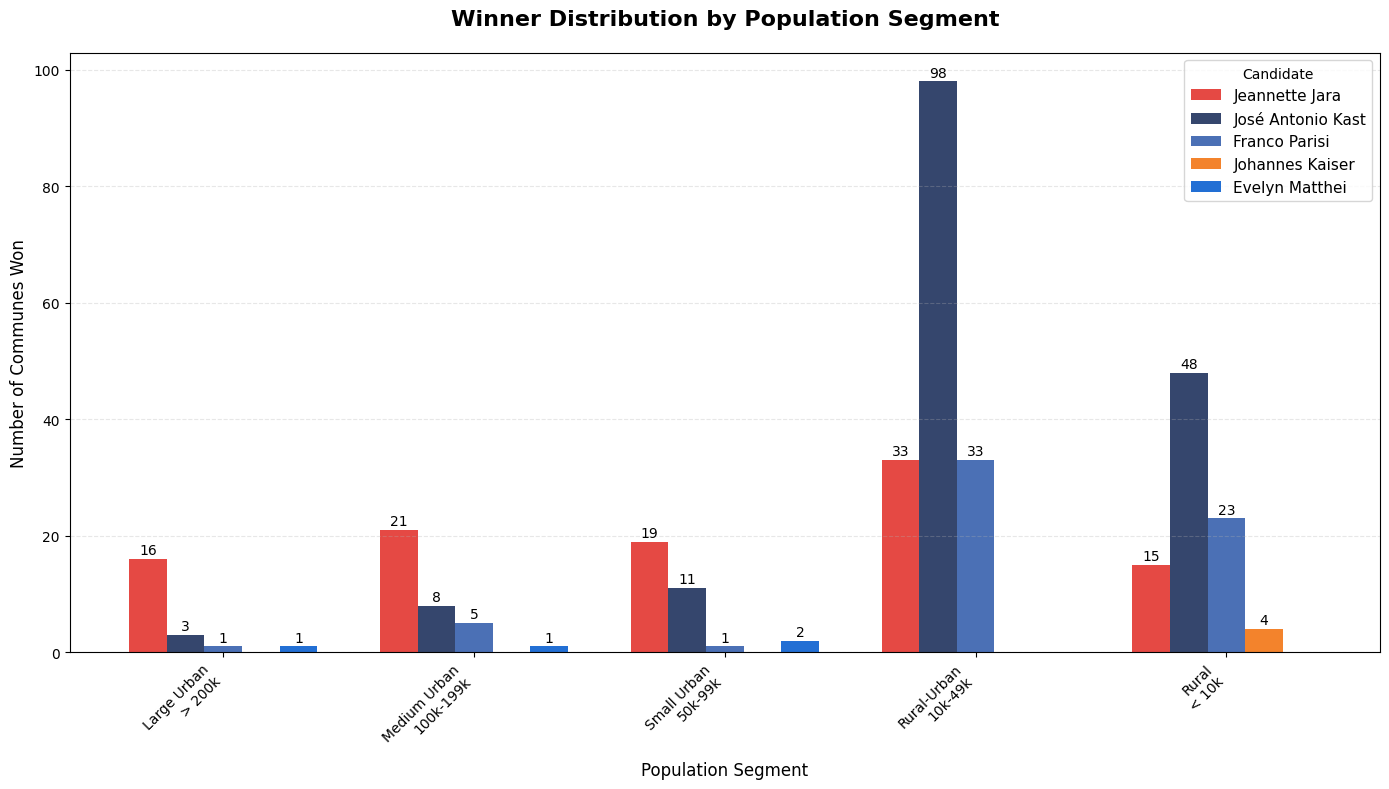

In [286]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# POPULATION SEGMENTATION OVERVIEW
# ============================================================================

# Convert columns to numeric types
for col in pct_cols:
    df_merged[col] = df_merged[col].astype(float)
df_merged['population'] = df_merged['population'].astype(int)

# Determine winner for each commune
df_merged['winner'] = (
    df_merged[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(CANDIDATE_NAMES)
)

# Define population segments
SEGMENTS = [
    {'name': 'Large Urban\n> 200k',     'min': 200_001, 'max': float('inf'), 'color': '#2E86AB'},
    {'name': 'Medium Urban\n100k-199k', 'min': 100_000, 'max': 199_999,      'color': '#3A6B4B'},
    {'name': 'Small Urban\n50k-99k',    'min':  50_000, 'max':  99_999,      'color': '#5F9E6E'},
    {'name': 'Rural-Urban\n10k-49k',    'min':  10_000, 'max':  49_999,      'color': '#C9A87C'},
    {'name': 'Rural\n< 10k',            'min':       0, 'max':   9_999,      'color': '#D4A5A5'},
]

def assign_segment(pop: int) -> str:
    """Assign population segment based on commune size."""
    if pop > 200_000:  return 'Large Urban\n> 200k'
    if pop >= 100_000: return 'Medium Urban\n100k-199k'
    if pop >= 50_000:  return 'Small Urban\n50k-99k'
    if pop >= 10_000:  return 'Rural-Urban\n10k-49k'
    return 'Rural\n< 10k'

df_merged['segment'] = df_merged['population'].apply(assign_segment)

# Calculate statistics per segment
seg_stats = []
for seg in SEGMENTS:
    df_seg = df_merged[df_merged['segment'] == seg['name']]
    n_comm = len(df_seg)
    if n_comm == 0:
        continue
    top_winner = df_seg['winner'].value_counts().index[0]
    top_pct = df_seg['winner'].value_counts().iloc[0] / n_comm * 100
    seg_stats.append({
        'segment':        seg['name'],
        'total_communes': n_comm,
        'total_pop':      df_seg['population'].sum(),
        'top_winner':     top_winner,
        'top_winner_pct': top_pct,
        'turnout':        df_seg['casted_votes'].sum() / df_seg['population'].sum() * 100,
    })
df_seg_stats = pd.DataFrame(seg_stats)

# Print summary table
print('POPULATION SEGMENTATION ANALYSIS')
display(df_seg_stats.round(2))

# ============================================================================
# CHART 1: OVERVIEW METRICS PER SEGMENT (2x2 GRID)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Electoral Analysis by Commune Population Size', fontsize=20, fontweight='bold')

seg_names = df_seg_stats['segment'].tolist()
seg_colors = [s['color'] for s in SEGMENTS if s['name'] in seg_names]

def labeled_bar(ax, labels, values, ylabel, title, fmt='{:.0f}'):
    """Helper to create labeled bar charts."""
    bars = ax.bar(labels, values, color=seg_colors)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(v), ha='center', va='bottom', fontsize=10)

labeled_bar(axes[0, 0], seg_names, df_seg_stats['total_communes'], 'Communes', '1. Communes per Segment')
labeled_bar(axes[0, 1], seg_names, df_seg_stats['total_pop'] / 1e6,  'Population (M)', '2. Total Population', fmt='{:.1f}M')
labeled_bar(axes[1, 0], seg_names, df_seg_stats['top_winner_pct'],  'Commune Share (%)', '3. Dominant Candidate Share', fmt='{:.0f}%')
labeled_bar(axes[1, 1], seg_names, df_seg_stats['turnout'],         'Turnout (%)', '4. Voter Turnout', fmt='{:.1f}%')

# Add average line to turnout chart
axes[1, 1].axhline(df_seg_stats['turnout'].mean(), color='red', linestyle='--', linewidth=1.5, label='Segment average')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# CHART 2: WINNER DISTRIBUTION BY SEGMENT (GROUPED BAR CHART)
# ============================================================================

fig2, ax = plt.subplots(figsize=(14, 8))

# Define candidates and their colors
all_winners = ['Jeannette Jara', 'José Antonio Kast', 'Franco Parisi', 'Johannes Kaiser', 'Evelyn Matthei']
winner_colors = {
    'Jeannette Jara': '#E54944',
    'José Antonio Kast': '#35466D',
    'Franco Parisi': '#4B70B5',
    'Johannes Kaiser': '#F3832C',
    'Evelyn Matthei': '#226FD4'
}

# Prepare data matrix: winners x segments
winner_counts = {}
for winner in all_winners:
    counts = []
    for seg in seg_names:
        df_seg = df_merged[df_merged['segment'] == seg]
        count = len(df_seg[df_seg['winner'] == winner])
        counts.append(count)
    winner_counts[winner] = counts

# Set up bar positions
x = np.arange(len(seg_names))
width = 0.15
offsets = np.linspace(-0.3, 0.3, len(all_winners))

# Create grouped bars
for i, winner in enumerate(all_winners):
    bars = ax.bar(x + offsets[i], winner_counts[winner], width, 
                  label=winner, color=winner_colors.get(winner, '#D3D3D3'))
    
    # Add value labels on top of bars
    for bar, val in zip(bars, winner_counts[winner]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Population Segment', fontsize=12)
ax.set_ylabel('Number of Communes Won', fontsize=12)
ax.set_title('Winner Distribution by Population Segment', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=11, title='Candidate')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Conclusion: Dos Chiles, tres territorios**

#### El Patrón General: Una Gradiente Urbano-Rural Clara

| Tamaño de Comuna              | Candidato Dominante   | % Población Controlada | Característica Principal |
| ----------------------------- | --------------------- | ---------------------- | ------------------------ |
| Grandes (> 200.000 hab.)      | **Jeannette Jara**    | **76,9%**              | Metrópolis densas        |
| Medianos (100-199k)           | **Jeannette Jara**    | 59,5%                  | Ciudades intermedias     |
| Pequeños (50-99k)             | **Jeannette Jara**    | 61,5%                  | Ciudades pequeñas        |
| Rural-Urban (10-49k)          | **José Antonio Kast** | **57,9%**              | Comunas semi-rurales     |
| Muy Pequeñas / Rurales (<10k) | **José Antonio Kast** | **~60%**               | Chile profundo rural     |

**Jara fue la indiscutida líder del Chile Urbano.** Su fortaleza se concentró en las comunas de mayor tamaño y densidad poblacional. Controló el 76,9% de la población en las ciudades más grandes del país, lo que le permitió ganar la primera vuelta a pesar de tener mucha menor cobertura territorial. Su voto es **urbano, denso y de servicios**.

**Kast se consolidó como el Rey del Chile Rural y Provincial.** A medida que el tamaño de las comunas disminuye, Kast gana terreno de forma progresiva y contundente. Domina ampliamente las comunas semi-rurales y rurales, alcanzando su peak en las localidades más pequeñas. Su apoyo es **amplio, territorial y provincial**, con fuerte presencia en el sur y centro-sur del país.

#### El Caso Especial de Franco Parisi

Parisi representa un **tercer territorio**: **el Norte antisistema**. Si bien no compite a nivel nacional con la misma fuerza que Jara o Kast, logra un dominio muy fuerte en el Norte Grande y Norte Chico, especialmente en comunas rurales, mineras y fronterizas. Su perfil combina:

- Alta intensidad en zonas aisladas y de frontera.
- Presencia relevante en comunas rurales del norte.
- Debilidad estructural en las grandes ciudades (excepto Antofagasta).

Parisi actuó como un **fenómeno regional con capacidad de desequilibrio nacional**, convirtiéndose en el gran árbitro de la segunda vuelta.

#### Conclusión Estratégica Final

La elección de 2025 no fue solo una competencia ideológica, sino también **una confrontación geográfica y demográfica** entre:

- **El Chile Urbano** (Jara): concentrado, poblacionalmente poderoso, pero territorialmente limitado.
- **El Chile Rural-Provincial** (Kast): extenso, fragmentado, pero con enorme amplitud territorial y mayor número de comunas.
- **El Norte Antisistema** (Parisi): regionalmente dominante y volátil.

Esta **trifurcación** explica tanto la victoria de Jara en primera vuelta (peso demográfico de las grandes ciudades) como el triunfo de Kast en segunda (capacidad de unir el voto no-metropolitano y capturar parte del voto de Parisi).

**Lección principal del mapa electoral 2025**: En Chile, **ganar las grandes ciudades da la primera vuelta, pero para ganar el país se necesita conquistar también el Chile rural y provincial**. La brecha urbano-rural sigue siendo uno de los clivajes políticos más profundos del país.

## 10. Recoverable Communes (Vote Margin < 1,000)

In [287]:
# ============================================================================
# RECOVERABLE COMMUNE ANALYSIS - JARA VS KAST
# ============================================================================

# Derive absolute vote counts from percentages and valid votes
df_votes['valid_votes']     = df_votes['casted_votes'] - df_votes['blank_votes'] - df_votes['null_votes']
df_votes['jara_abs_votes']  = (df_votes['jara_pct']  / 100) * df_votes['valid_votes']
df_votes['kast_abs_votes']  = (df_votes['kast_pct']  / 100) * df_votes['valid_votes']
df_votes['vote_difference'] = np.abs(df_votes['jara_abs_votes'] - df_votes['kast_abs_votes'])

df_close = df_votes[df_votes['vote_difference'] < 1000].copy()
df_close['winner']       = np.where(df_close['jara_abs_votes'] > df_close['kast_abs_votes'],
                                     'Jeannette Jara', 'José Antonio Kast')
df_close['loser']        = np.where(df_close['winner'] == 'Jeannette Jara',
                                     'José Antonio Kast', 'Jeannette Jara')
df_close['votes_needed'] = df_close['vote_difference']

# Summary per candidate
summary_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    subset      = df_close[df_close['loser'] == candidate]
    if len(subset) == 0:
        continue
    total_votes = int(subset['votes_needed'].sum())
    difficulty  = (
        'Minor challenge'       if total_votes < 5_000  else
        'Moderate challenge'    if total_votes < 20_000 else
        'Significant challenge'
    )
    summary_rows.append({
        'candidate':             candidate,
        'recoverable_communes':  len(subset),
        'total_votes_needed':    total_votes,
        'avg_votes_needed':      round(subset['votes_needed'].mean(), 0),
        'difficulty_level':      difficulty,
    })

print('RECOVERABLE COMMUNES (MARGIN < 1,000 VOTES)')
print('='*80)
display(pd.DataFrame(summary_rows))

# Detail by candidate and macrozone (north to south)
macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
df_close['macrozone'] = df_close['region'].map(macrozone_map)

detail_cols = ['commune', 'region', 'macrozone',
               'jara_abs_votes', 'kast_abs_votes', 'vote_difference', 'votes_needed']

for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    print('\n' + '='*80)
    print(f'RECOVERABLE FOR {candidate.upper()} (lost by fewer than 1,000 votes)')
    print('='*80)
    df_cand = df_close[df_close['loser'] == candidate].copy()
    if len(df_cand) == 0:
        print('No recoverable communes.')
        continue
    for zone in macrozone_order:
        df_zone = df_cand[df_cand['macrozone'] == zone]
        if len(df_zone) > 0:
            print(f'\n{zone.upper()} ({len(df_zone)} communes)')
            print('-'*80)
            df_disp = df_zone[detail_cols].copy()
            for col in ['jara_abs_votes','kast_abs_votes','vote_difference','votes_needed']:
                df_disp[col] = df_disp[col].round(0).astype(int)
            display(df_disp)

RECOVERABLE COMMUNES (MARGIN < 1,000 VOTES)


,candidate,recoverable_communes,total_votes_needed,avg_votes_needed,difficulty_level
0,Jeannette Jara,81,33999,420.0,Significant challenge
1,José Antonio Kast,53,17720,334.0,Moderate challenge



RECOVERABLE FOR JEANNETTE JARA (lost by fewer than 1,000 votes)

NORTE GRANDE (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
1,Calama,Antofagasta,Norte Grande,19492,20107,615,615
4,Ollague,Antofagasta,Norte Grande,90,117,27,27
10,Camarones,Arica y Parinacota,Norte Grande,281,310,29,29
11,General Lagos,Arica y Parinacota,Norte Grande,47,177,130,130
12,Putre,Arica y Parinacota,Norte Grande,332,591,259,259
281,Camiña,Tarapacá,Norte Grande,122,608,486,486
282,Colchane,Tarapacá,Norte Grande,25,387,362,362
283,Huara,Tarapacá,Norte Grande,447,685,238,238
286,Pozo Almonte,Tarapacá,Norte Grande,1744,1962,218,218



NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
47,Lota,Biobío,Centro Sur,9499,8592,907,907
55,San Rosendo,Biobío,Centro Sur,853,836,17,17



SUR (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
147,Castro,Los Lagos,Sur,8860,8209,651,651
159,Osorno,Los Lagos,Sur,30047,29841,206,206
160,Palena,Los Lagos,Sur,353,338,15,15
162,Puerto Octay,Los Lagos,Sur,1931,1761,170,170
170,Quinchao,Los Lagos,Sur,1549,1462,87,87
172,San Juan de la Costa,Los Lagos,Sur,1795,1695,100,100
175,Corral,Los Ríos,Sur,1253,1057,196,196



PATAGONIA (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
22,Aysen,Aysén,Patagonia,4545,3633,912,912
23,Chile Chico,Aysén,Patagonia,1232,747,485,485
25,Cochrane,Aysén,Patagonia,643,560,83,83
30,Rio Ibañez,Aysén,Patagonia,578,572,6,6
31,Tortel,Aysén,Patagonia,120,71,49,49
190,Natales,Magallanes,Patagonia,4939,4096,843,843
191,Porvenir,Magallanes,Patagonia,1209,1013,196,196
192,Primavera,Magallanes,Patagonia,119,81,38,38
195,San Gregorio,Magallanes,Patagonia,97,89,8,8


### Caso 1: Jeannette Jara – Patrones en sus 81 comunas recuperables

**Patrón principal**: La gran mayoría de las comunas recuperables de Jara se concentran en **zonas de transición y semi-rurales**, **no en las grandes ciudades**.

- **Norte Grande**: 9 comunas (Calama, Ollagüe, Camarones, General Lagos, etc.). Aquí Jara quedó muy cerca de Kast/Parisi en comunas pequeñas y fronterizas.
- **Centro**: Gran cantidad en O’Higgins, Maule y Valparaíso (Rengo, Codegua, Coinco, etc.).
- **Centro Sur**: Muchas en Biobío y La Araucanía.

**Características clave**:

- Predominantemente **comunas medianas y pequeñas** (muchas entre 5.000 y 50.000 habitantes).
- **Perfil semi-rural o de transición urbano-rural**.
- Pocas comunas muy grandes (>200.000 hab.) aparecen aquí. Jara ya dominaba con márgenes más amplios las grandes ciudades.
- Alta concentración en **regiones bisagra** (O’Higgins, Maule, Biobío).

**Interpretación**: Jara tenía un techo alto en las grandes urbes, pero **era vulnerable en el Chile intermedio** (ciudades medianas y comunas semi-rurales). Perdió muchas comunas por márgenes muy estrechos en territorios donde Kast tenía mejor penetración cultural y territorial.

### Caso 2:  José Antonio Kast– Patrones en sus 53 comunas recuperables

#### Patrones Geográficos en las Comunas Recuperables de Kast

1. **Norte Grande y Norte Chico (13 comunas)**

   - Kast tuvo varias comunas muy cercanas en el Norte (María Elena, Mejillones, Taltal, Pica, Freirina, etc.).
   - Aquí compitió principalmente contra **Parisi**, quien dominaba la zona.
   - Patrón: Comunas mineras, fronterizas o rurales del Norte donde Kast logró acercarse considerablemente.

2. **Centro (22 comunas)**

   - Gran concentración en O’Higgins, Maule y Valparaíso.
   - Muchas comunas semi-rurales y de tamaño intermedio (Doñihue, Graneros, Navidad, Pencahue, etc.).
   - Kast estuvo muy cerca de Jara en territorios de transición urbano-rural.

3. **Centro Sur y Sur (9 comunas)**

   - Presencia en Biobío, Los Ríos y Los Lagos.
   - Comunas donde Jara logró acercarse en territorios tradicionalmente favorables a Kast.

4. **Patagonia (9 comunas)**

   - Alta cantidad de comunas recuperables en Aysén y Magallanes.
   - Zona de fuerte competencia con Jara y Kaiser.

   **Patrón clave de Kast**:

   - Sus comunas recuperables están más distribuidas geográficamente.
   - Gran parte se encuentran en **zonas de transición** (ni totalmente urbanas ni totalmente rurales), donde la competencia fue más reñida.
   - En el Norte, Kast logró acercarse a Parisi en varias comunas pequeñas/mineras, mostrando capacidad de competencia incluso en territorio adverso.

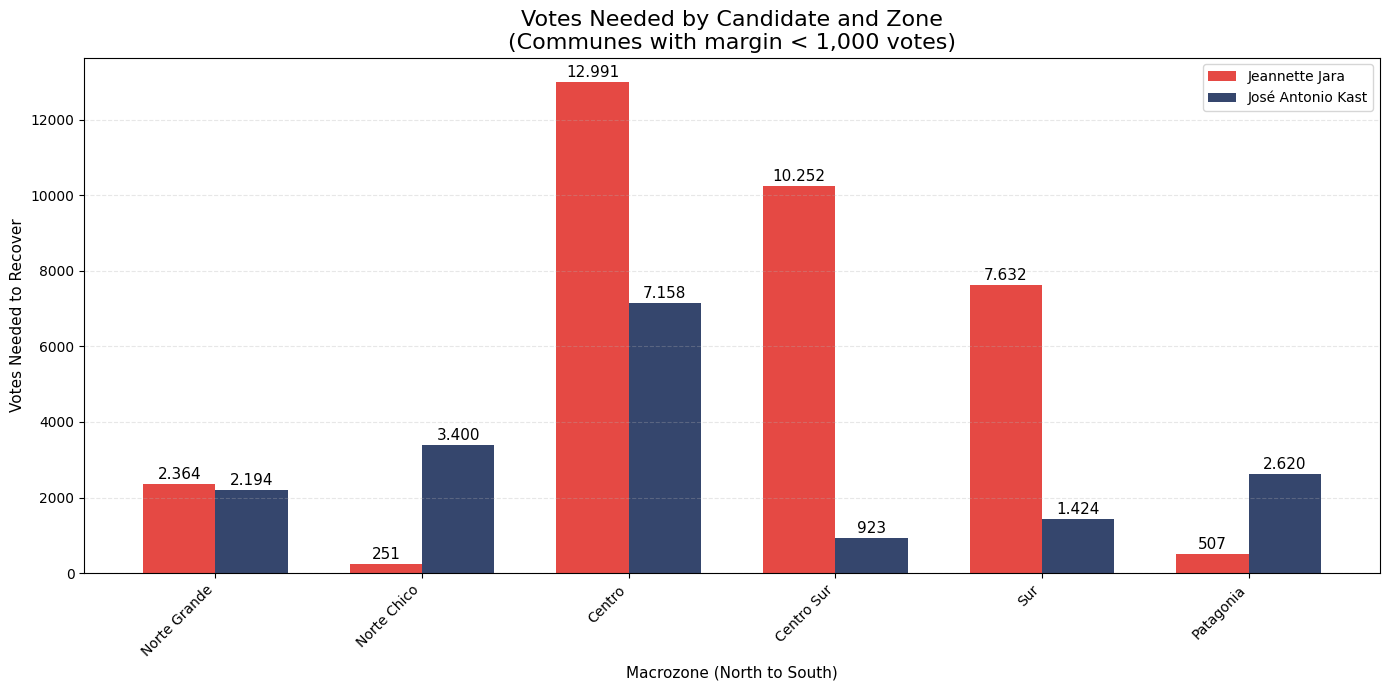

In [288]:
# ============================================================================
# RECOVERABLE COMMUNES - GROUPED BAR CHART (VOTES NEEDED BY ZONE)
# ============================================================================

zone_vote_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    df_cand = df_close[df_close['loser'] == candidate]
    for zone in macrozone_order:
        df_zone = df_cand[df_cand['macrozone'] == zone]
        zone_vote_rows.append({
            'candidate':    candidate,
            'macrozone':    zone,
            'votes_needed': df_zone['votes_needed'].sum() if len(df_zone) > 0 else 0,
        })

df_zone_votes = pd.DataFrame(zone_vote_rows)

fig, ax = plt.subplots(figsize=(14, 7))
x     = np.arange(len(macrozone_order))
width = 0.35

votes_jara = [
    df_zone_votes[(df_zone_votes['candidate'] == 'Jeannette Jara') &
                  (df_zone_votes['macrozone'] == z)]['votes_needed'].values[0]
    for z in macrozone_order
]
votes_kast = [
    df_zone_votes[(df_zone_votes['candidate'] == 'José Antonio Kast') &
                  (df_zone_votes['macrozone'] == z)]['votes_needed'].values[0]
    for z in macrozone_order
]

bars1 = ax.bar(x - width/2, votes_jara, width, label='Jeannette Jara',   color='#E54944')
bars2 = ax.bar(x + width/2, votes_kast, width, label='José Antonio Kast', color='#35466D')

ax.set_xlabel('Macrozone (North to South)', fontsize=11)
ax.set_ylabel('Votes Needed to Recover', fontsize=11)
ax.set_title('Votes Needed by Candidate and Zone\n(Communes with margin < 1,000 votes)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(macrozone_order, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 50,
                    f'{int(h):,}'.replace(',','.'), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Este gráfico muestra la cantidad total de votos que Jara (rojo) y Kast (azul) necesitaban para voltear todas las comunas que perdieron por menos de 1.000 votos en cada macrozona.

### Análisis principal:

- **Jara** requería un esfuerzo mucho mayor de movilización, especialmente en el **Centro** (12.991 votos) y **Centro Sur** (10.252 votos). Estas dos zonas concentran la gran mayoría de su desafío. En el Sur también necesitaba más de 7.600 votos.
- **Kast** tuvo un desafío más eficiente y distribuido. Su mayor necesidad se concentra en el **Centro** (7.158 votos), pero en el Centro Sur y Sur requería relativamente pocos votos para voltear comunas (923 y 1.424 respectivamente).

**Conclusión clave del gráfico**: Jara tenía muchas más comunas “al alcance”, pero concentradas en zonas de alto volumen (Centro y Centro Sur), lo que hacía su tarea más costosa en votos absolutos. Kast, en cambio, tenía menos comunas recuperables, pero más “baratas” y mejor distribuidas territorialmente. Esto refuerza que Kast partía con una base más consolidada y eficiente de cara a la segunda vuelta.

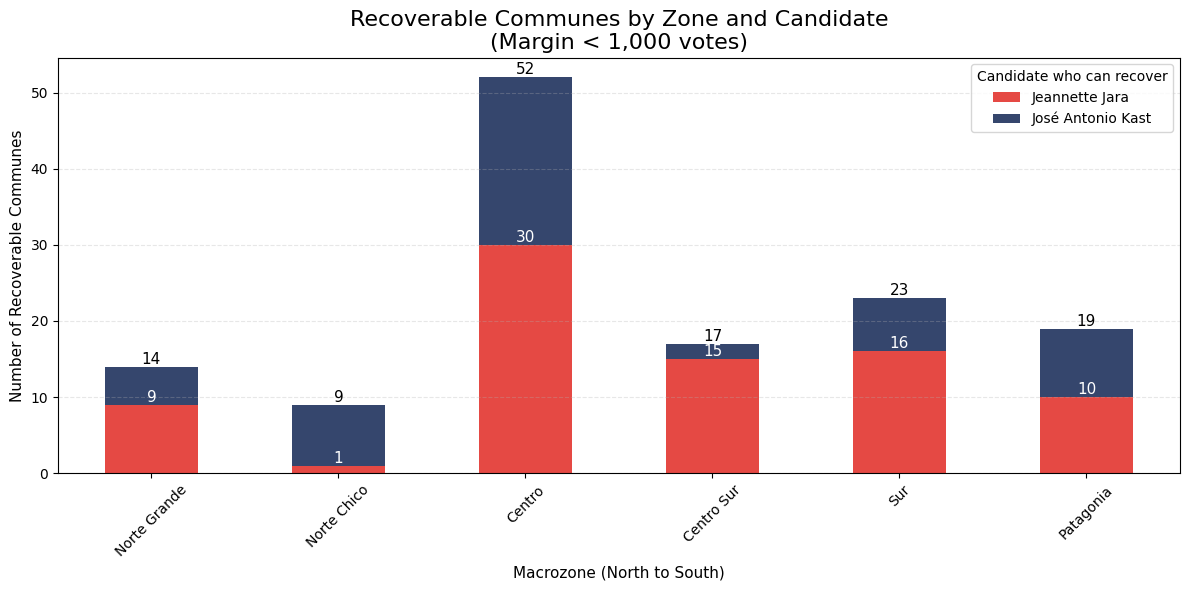

In [289]:
# ============================================================================
# RECOVERABLE COMMUNES - STACKED BAR CHART (COUNT BY ZONE)
# ============================================================================

zone_count_rows = []
for candidate in ['Jeannette Jara', 'José Antonio Kast']:
    df_cand = df_close[df_close['loser'] == candidate]
    for zone in macrozone_order:
        zone_count_rows.append({
            'candidate': candidate,
            'macrozone': zone,
            'communes':  len(df_cand[df_cand['macrozone'] == zone]),
        })

df_zone_counts = pd.DataFrame(zone_count_rows)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = (
    df_zone_counts
    .pivot(index='macrozone', columns='candidate', values='communes')
    .fillna(0)
    .reindex(macrozone_order)
)

cand_colors = {'Jeannette Jara': '#E54944', 'José Antonio Kast': '#35466D'}
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=[cand_colors[c] for c in pivot.columns])

ax.set_xlabel('Macrozone (North to South)', fontsize=11)
ax.set_ylabel('Number of Recoverable Communes', fontsize=11)
ax.set_title('Recoverable Communes by Zone and Candidate\n(Margin < 1,000 votes)', fontsize=16)
ax.legend(title='Candidate who can recover', loc='upper right')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linestyle='--')

text_colors = {'Jeannette Jara': 'white', 'José Antonio Kast': 'black'}
for i, container in enumerate(ax.containers):
    ax.bar_label(container, fmt='%d', fontsize=11, color=text_colors[pivot.columns[i]])

plt.tight_layout()
plt.show()

#### Resumen Visual por Macrozona

- **Centro**: La zona más disputada del país (52 comunas recuperables). Jara tenía 30 oportunidades y Kast 22. Aquí se concentró la mayor parte de la pelea.
- **Centro Sur y Sur**: Jara dominaba en cantidad de comunas recuperables (15 + 16), pero Kast mostraba mayor solidez en estas zonas.
- **Norte Grande y Norte Chico**: Jara tenía varias comunas cercanas, pero el control general seguía siendo favorable a Parisi.
- **Patagonia**: Alta competitividad (19 comunas), prácticamente empatada entre ambos.

**Interpretación estratégica final**:

Aunque **Jeannette Jara** ganó la primera vuelta gracias al peso demográfico de las grandes ciudades, el mapa de comunas recuperables muestra que **José Antonio Kast** partía con una posición más ventajosa de cara a la segunda vuelta. Kast necesitaba menos votos totales para voltear comunas clave y tenía una base más consolidada en el sur y centro-sur.

La gran mayoría de las comunas decididas por márgenes estrechos se encontraban en **zonas de transición** (ni totalmente urbanas ni totalmente rurales), especialmente en el Centro y Centro Sur. Esto confirma que la elección no se definió solo en las grandes metrópolis ni en las comunas más aisladas, sino en el **Chile intermedio**.

## 11. Second Round Projection (Jara vs Kast)

This analysis projects the outcome of a runoff between **Jeannette Jara** and
**José Antonio Kast**, applying vote transfer assumptions for each eliminated candidate.

### 11.1. Base Scenario – Natural Vote Transfer

| Eliminated candidate | Votes | Transfer assumption | Rationale |
|---|---|---|---|
| Johannes Kaiser | 1,796,034 | 95% → Kast, 5% abstain | Libertarian right aligns with Kast; minor abstention reflects programmatic differences. |
| Eduardo Artes | 85,516 | 100% → Jara | Far-left electorate supports the officialist candidate as the ideologically closest option. |
| Marco Enriquez-Ominami | 154,321 | 100% → Jara | Independent left vote leans toward Jara to avoid backing a right-wing candidate. |
| Evelyn Matthei | 1,603,104 | 55% → Kast, 20% → Jara, 25% abstain | Historical right splits: majority backs Kast; a significant sector (Evópoli, part of RN) may cross over or abstain. |
| Harold Mayne-Nicholls | 162,366 | 40% → Jara, 25% → Kast, 35% abstain | Independent vote distributes more evenly, with high abstention from disenchantment with both options. |

Franco Parisi's votes (2,550,770) are **not assigned** in this base scenario, reflecting their uncertain transfer.

In [290]:
# ============================================================================
# RUNOFF PROJECTION - BASELINE SCENARIO
# ============================================================================

# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes (candidates only)
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. Baseline transfer scenario
# Kaiser (libertarian right) → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes (far left) → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO (independent left) → 100% Jara
votes_jara_proj += votes_meo

# Matthei (historical right) → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne-Nicholls (independent) → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# 4. Total valid votes in projection
total_valid_proj = votes_jara_proj + votes_kast_proj

# 5. Total abstention (excludes blank/null, already counted)
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne

# 6. Difference (positive = Jara leads, negative = Kast leads)
diff = votes_jara_proj - votes_kast_proj

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*70)
print("RUNOFF PROJECTION - BASELINE SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser ({votes_kaiser:,.0f}) → 95% Kast, 5% abstention".replace(',', '.'))
print(f"   Eduardo Artes ({votes_artes:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Marco Enríquez-Ominami ({votes_meo:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Evelyn Matthei ({votes_matthei:,.0f}) → 55% Kast, 20% Jara, 25% abstention".replace(',', '.'))
print(f"   Harold Mayne-Nicholls ({votes_mayne:,.0f}) → 40% Jara, 25% Kast, 35% abstention".replace(',', '.'))

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print("\n📊 NON-VOTING SUMMARY (CONTEXT):")
print(f"   Abstention (voters not participating): {abstention_total:,.0f}".replace(',', '.'))
print(f"   Blank + null votes: {total_blank + total_null:,.0f}".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


RUNOFF PROJECTION - BASELINE SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1.796.034) → 95% Kast. 5% abstention
   Eduardo Artes (85.516) → 100% Jara
   Marco Enríquez-Ominami (154.321) → 100% Jara
   Evelyn Matthei (1.603.104) → 55% Kast. 20% Jara. 25% abstention
   Harold Mayne-Nicholls (162.366) → 40% Jara. 25% Kast. 35% abstention

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.072.258 votes (41.6% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (58.4% of valid votes)

📊 NON-VOTING SUMMARY (CONTEXT):
   Abstention (voters not participating): 547.406
   Blank + null votes: 502.527

📊 MARGIN: 1.643.236 votes in favor of Kast


**Interpretación del Escenario Base**:

- Kast logra una **victoria cómoda** incluso sin recibir votos de Parisi.
- La derecha tradicional (Matthei) entrega la mayoría de sus votos a Kast, aunque con fugas significativas hacia Jara y abstención.
- El voto de izquierda residual (Artes + MEO) se consolida casi completamente en Jara.
- La alta abstención esperada (especialmente de Matthei y Mayne-Nicholls) beneficia relativamente a Kast.

### 11.2. Optimal Scenario for Jara

#### Political Context and Assumptions

This scenario projects a favorable outcome for **Jeannette Jara**, based on three key political phenomena:

##### 1. Recovery of the historical northern vote
Chile's northern regions (Tarapacá, Antofagasta, Atacama, Coquimbo) were traditionally strongholds of the Concertación and Nueva Mayoría coalitions. The working-class, mining, and popular sector vote from the north, which dispersed toward Parisi and other anti-establishment options in the first round, returns predominantly to the officialist candidate in the runoff as a strategic vote against the conservative right.

##### 2. The Parisi factor: From protest to social transformation
Franco Parisi and the Partido de la Gente (PDG) represent a hybrid political phenomenon: a movement that is **social in its origin and structure**, despite holding economic and security proposals traditionally associated with the right. The PDG's territorial experience, built through neighborhood councils, community kitchens, and independent social organizations during the crisis, aligns it more closely with social politics than with traditional right-wing politics.

The phrase that captures this narrative is key:

> **"From protest to social transformation"**

The Parisi vote is not a classic right-wing vote, but rather a **vote of unease and discontent** with the political system. In this scenario, Parisi **actively supports Jara** or at least **explicitly rejects Kast**, channeling his voters toward the officialist option as the path to transform discontent into real change.

#### Scenario Results

In [291]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. OPTIMAL FOR JARA SCENARIO

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 60% Jara, 40% abstention (optimal for Jara)
votes_jara_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.40
# Parisi does NOT go to Kast in this scenario

# 4. Total valid votes in projection
total_valid_proj = votes_jara_proj + votes_kast_proj

# 5. Difference
diff = votes_jara_proj - votes_kast_proj

# 6. Total abstention
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 7. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - OPTIMAL FOR JARA SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 60% Jara, 40% abstention (OPTIMAL FOR JARA)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - OPTIMAL FOR JARA SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 60% Jara, 40% abstention (OPTIMAL FOR JARA)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.602.720 votes (49.5% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (50.5% of valid votes)

❌ Non-voters (abstention + blank + null): 2.070.241 votes

📊 MARGIN: 112.774 votes in favor of Kast


#### Contexto Político y Supuestos

Este escenario representa el **mejor caso posible** para Jeannette Jara en segunda vuelta. Se basa en una transferencia favorable del voto antisistema y una recomposición parcial del electorado de centro-izquierda.

Es un resultado extremadamente ajustado — prácticamente un photo-finish electoral.

#### Análisis del Escenario

Este escenario requiere que ocurra lo siguiente simultáneamente:

1. **Reagrupamiento del Norte** Una parte importante del voto de Parisi (especialmente en comunas mineras y populares del Norte Grande) regresa al oficialismo como voto estratégico contra la derecha.
2. **Narrativa efectiva de “protesta transformadora”** Jara logra convencer a una mayoría del electorado parisiense de que ella representa el cambio real y no el “castigo” que ya se dio en primera vuelta.
3. **Abstención selectiva** Una parte significativa del voto de Matthei y Mayne-Nicholls se abstiene o se divide, limitando la transferencia total hacia Kast.

#### Implicaciones Estratégicas

Aunque este es el escenario más favorable para Jara, **Kast sigue ganando**, aunque por un margen mínimo. Esto demuestra la **fortaleza estructural** de Kast: incluso en el mejor escenario posible para su rival, Jara apenas logra empatar técnicamente.

**Conclusión del Escenario**:

En el mejor de los mundos para Jeannette Jara —con una fuerte transferencia del voto de Parisi y una narrativa convincente hacia el electorado antisistema—, la elección se define por **menos de 113 mil votos**. Esto equivale a menos del **0.85%** del total de votos emitidos.

Un resultado tan estrecho habría convertido la segunda vuelta en una de las más cerradas de la historia moderna de Chile, donde factores como la movilización del último día, el clima, y el desempeño en las regiones bisagra (O’Higgins, Biobío, Coquimbo) habrían sido absolutamente decisivos.

### 11.3. Neutral Scenario – Parisi Vote Fragmentation

#### Political Context

This scenario reflects a **fragmentation of the Parisi vote**, where the Partido de la Gente (PDG) fails to articulate a clear position regarding the runoff.

**PDG's key message:**
> *"Let each person decide according to their values"*

**Political implications:**
- Parisi **remains silent** and does not deliver an explicit voting recommendation
- The PDG **internally fractures**: more socially-oriented sectors lean toward Jara, while the economic and security right-wing currents prefer Kast
- The Parisi voter is **left to their own decision**, fragmenting naturally

#### Scenario Results

In [292]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. NEUTRAL SCENARIO (Parisi vote fragmentation)

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)
votes_jara_proj += votes_parisi * 0.40
votes_kast_proj += votes_parisi * 0.50
abstention_parisi = votes_parisi * 0.10

# 4. Totals
total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 5. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - NEUTRAL SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - NEUTRAL SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.092.566 votes (42.1% of valid votes)
✅ José Antonio Kast: 6.990.879 votes (57.9% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 1.898.313 votes in favor of Kast


Este escenario representa el resultado más probable según el comportamiento natural del electorado parisiense, sin una instrucción clara o explícita de Franco Parisi.

#### Contexto Político y Análisis

Este escenario refleja una **fragmentación natural** del voto antisistema:

- El electorado de Parisi es heterogéneo: contiene sectores populares con demandas sociales (que tienden a Jara) y sectores preocupados por seguridad, migración y economía (que tienden a Kast).
- Al no entregar una instrucción clara y optar por el mensaje “**que cada uno vote según su conciencia**”, Parisi permitió que el voto se distribuyera según las preferencias individuales de sus electores.
- El resultado muestra una ligera inclinación hacia Kast (50% vs 40%), consistente con el perfil más conservador en temas de orden público y migración que tenía una parte importante de su base.

**Implicaciones**:

- Kast consolida una **victoria clara y cómoda**.
- Jara no logra capitalizar suficientemente el voto de protesta.
- La abstención moderada (10% del voto Parisi) afecta más a Jara, que necesitaba una transferencia masiva para competir.

#### Conclusión del Escenario Neutral

En un escenario neutral, donde Franco Parisi no entrega un apoyo explícito y su electorado se fragmenta según sus propias sensibilidades, **José Antonio Kast obtiene una victoria sólida con un margen superior a los 15 puntos porcentuales**.

Este resultado refuerza que el voto parisiense no era ideológicamente de izquierda, sino principalmente **antisistema y transversal**, con una inclinación natural hacia posiciones más duras en seguridad y migración. La falta de una directriz clara por parte de Parisi terminó beneficiando a Kast, quien se consolidó como la opción más atractiva para contener el descontento ciudadano.

Este escenario probablemente se acerca más a lo que ocurrió en la realidad de la segunda vuelta.

### 11.4. Optimal Scenario for Kast

#### Political Context

This scenario reflects the most favorable conditions for **José Antonio Kast**, where multiple factors converge in his favor.

##### 1. Parisi calls to vote for Kast
**Key message:**
> *"We are both anti-establishment, against the political caste"*

Parisi identifies Kast as a natural ally in rejecting traditional politics, building an "anti-establishment" narrative that resonates with the most disenchanted electorate.

##### 2. Wear and tear of the Boric administration
The incumbent government has accumulated negative evaluations in key areas:
- Public security crisis
- Economic stagnation
- Unresolved migration issues

Jara carries this baggage due to her role as an officialist militant.

##### 3. Historical abandonment of the north
The northern regions (Tarapacá, Antofagasta, Atacama, Coquimbo) are experiencing:
- **Historical abandonment**: Perception that the central state has ignored their needs
- **Migration crisis**: Overwhelmed borders and cities
- **Growing insecurity**: Increase in crimes linked to organized crime

Kast, as a relatively new figure not associated with the Concertación/Nueva Mayoría, capitalizes on this discontent. Jara, on the other hand, is perceived as part of the **continuity of the political caste** that has governed Chile for decades.

##### 4. Additional factors
- **Misinformation and fear**: Northern voters, affected by the migration and security crisis, lean toward the "hard line" promised by Kast
- **Selective abstention**: The most disenchanted voters with both options simply nullify their vote

In [293]:
# 1. National totals
total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# 2. First round votes
votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# 3. OPTIMAL FOR KAST SCENARIO

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)
votes_jara_proj += votes_parisi * 0.30
votes_kast_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.10

# 4. Totals
total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# 5. Results
print("\n" + "="*70)
print("RUNOFF PROJECTION - OPTIMAL FOR KAST SCENARIO")
print("="*70)

print("\n📊 TOTAL CAST VOTES:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)")

print("\n" + "="*70)
print("📈 RUNOFF PROJECTION (VALID VOTES ONLY)")
print("="*70)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))



RUNOFF PROJECTION - OPTIMAL FOR KAST SCENARIO

📊 TOTAL CAST VOTES:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)

📈 RUNOFF PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.837.489 votes (40.0% of valid votes)
✅ José Antonio Kast: 7.245.956 votes (60.0% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 2.408.467 votes in favor of Kast


Este escenario representa las mejores condiciones posibles para José Antonio Kast en segunda vuelta, donde se combinan una fuerte transferencia del voto antisistema y el castigo al oficialismo (gobierno de Boric)

#### Contexto Político y Factores Clave

Este escenario se construye sobre cuatro pilares fundamentales:

1. **Apoyo explícito o implícito de Parisi** Parisi posiciona a Kast como un aliado en la lucha contra el “establishment” y la “casta política”. Su mensaje “anti-sistema” se alinea temporalmente con Kast, facilitando una transferencia mayoritaria de su electorado.
2. **Desgaste severo del Gobierno Boric** Jara carga con la herencia negativa del gobierno en materia de seguridad, migración, economía y gestión pública. El electorado del Norte, especialmente afectado por estos problemas, castiga duramente al oficialismo.
3. **Crisis en el Norte y Abandono Histórico** Las regiones nortinas perciben que el Estado central las ha abandonado durante décadas. Kast capitaliza este malestar histórico, presentándose como una alternativa fresca y de mano dura frente a la migración y la delincuencia.
4. **Narrativa de Orden y Estabilidad** Kast logra consolidar el voto de derecha tradicional (Matthei) y atrae a una parte significativa del voto parisiense con un discurso enfocado en seguridad, fronteras y recuperación económica.

#### Conclusión del Escenario Óptimo para Kast

En el mejor escenario posible para José Antonio Kast —con una fuerte transferencia del voto de Parisi (60%) y un castigo claro al oficialismo—, se produce una **victoria contundente** con un margen superior a los **20 puntos porcentuales**.

Este resultado muestra que Kast no solo contaba con una base rural y provincial sólida, sino que tenía un **potencial real de expansión** hacia el voto antisistema y descontento del Norte. La combinación de fragmentación de la derecha en primera vuelta y su posterior consolidación en segunda vuelta resultó letal para las aspiraciones de Jara.

Este escenario ilustra por qué, a pesar de la victoria de Jara en primera vuelta, Kast partía como amplio favorito para el balotaje.


### 11.5. Comparison of the Three Scenarios
| Escenario                      | Transferencia Parisi            | Jara (% válidos) | Kast (% válidos) | Margen Kast      | Resultado Esperado        |
| ------------------------------ | ------------------------------- | ---------------- | ---------------- | ---------------- | ------------------------- |
| **Base** (sin Parisi asignado) | No asignado                     | 41.6%            | **58.4%**        | +1.643.236 votos | Victoria cómoda Kast      |
| **Óptimo para Jara**           | 60% Jara – 30% Kast – 10% Abst. | 49.5%            | **50.5%**        | +112.774 votos   | Victoria estrecha Kast    |
| **Neutral**                    | 40% Jara – 50% Kast – 10% Abst. | 42.1%            | **57.9%**        | +1.898.313 votos | Victoria clara Kast       |
| **Óptimo para Kast**           | 30% Jara – 60% Kast – 10% Abst. | 40.0%            | **60.0%**        | +2.408.467 votos | Victoria contundente Kast |


#### Análisis Comparativo y Conclusiones

Los cuatro escenarios analizados muestran una **tendencia estructural muy clara**:

- **José Antonio Kast** es el gran favorito en prácticamente todos los escenarios posibles. Incluso en el **mejor caso para Jara** (60% del voto Parisi), Kast sigue ganando, aunque por un margen mínimo.
- La transferencia del voto de Parisi es el factor decisivo, pero incluso con una distribución favorable a Jara, no es suficiente para revertir la ventaja estructural de Kast.
- El **Escenario Neutral** (fragmentación natural del voto Parisi) es probablemente el más realista y da una victoria cómoda a Kast (~58%).
- La **base territorial** de Kast (mayor cantidad de comunas, fuerte apoyo rural y semi-rural) combinada con la fragmentación de la derecha en primera vuelta le permitió consolidarse de manera más eficiente en segunda vuelta.

**Conclusión Final del Análisis Electoral**:

La primera vuelta presidencial 2025 fue ganada por **Jeannette Jara** gracias al peso demográfico de las grandes ciudades y el voto urbano denso. Sin embargo, la segunda vuelta demostró que **José Antonio Kast** contaba con una base mucho más sólida y eficiente a nivel territorial.

La fragmentación de la derecha en primera vuelta fue más aparente que real. Una vez consolidado el voto de Kaiser, Matthei y una parte significativa de Parisi, Kast logró construir una mayoría clara. El voto antisistema de Parisi, lejos de ser un bloque de izquierda, mostró una inclinación natural hacia posiciones más duras en seguridad y migración.

**Lección principal**: En Chile, **ganar las grandes ciudades** permite liderar la primera vuelta, pero **conquistar el Chile rural, provincial y de transición** es lo que define al ganador definitivo.

## 12. Anti-Establishment Vote Phenomenon – Parisi vs Duopoly

In [294]:
# ============================================================================
# ANTI-ESTABLISHMENT VOTE ANALYSIS
# ============================================================================

df_analysis = df_votes.copy()

# Duopoly combined share: Jara + Kast
df_analysis['jara_kast_sum']     = df_analysis['jara_pct'] + df_analysis['kast_pct']
df_analysis['parisi_vs_duopoly'] = df_analysis['parisi_pct'] - df_analysis['jara_kast_sum']

# Communes where Parisi outpolls the entire duopoly
df_antisystem = (
    df_analysis[df_analysis['parisi_pct'] > df_analysis['jara_kast_sum']]
    .copy()
    .sort_values('parisi_vs_duopoly', ascending=False)
)

print('ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY')
print('Communes where Parisi outpolls Jara + Kast combined')
print('=' * 80)
print(f'Communes qualifying: {len(df_antisystem)} of {len(df_analysis)}')
print(f'Share of all communes: {len(df_antisystem)/len(df_analysis)*100:.1f}%')
print(f'Average Parisi lead over duopoly: {df_antisystem["parisi_vs_duopoly"].mean():.1f} pp')
print(f'Largest lead: {df_antisystem["parisi_vs_duopoly"].max():.1f} pp')

display_cols = ['commune', 'region', 'parisi_pct', 'jara_pct', 'kast_pct',
                'jara_kast_sum', 'parisi_vs_duopoly', 'casted_votes']
display(df_antisystem[display_cols].round(2))

# Summary by region
region_summary = (
    df_antisystem
    .groupby('region')
    .agg(
        antisystem_communes=('commune', 'count'),
        avg_parisi_lead=('parisi_vs_duopoly', 'mean'),
        avg_parisi_pct=('parisi_pct', 'mean'),
    )
    .sort_values('antisystem_communes', ascending=False)
    .round(1)
)
print('\nANTI-ESTABLISHMENT COMMUNES BY REGION')
display(region_summary)


ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY
Communes where Parisi outpolls Jara + Kast combined
Communes qualifying: 11 of 346
Share of all communes: 3.2%
Average Parisi lead over duopoly: 8.9 pp
Largest lead: 30.0 pp


,commune,region,parisi_pct,jara_pct,kast_pct,jara_kast_sum,parisi_vs_duopoly,casted_votes
4,Ollague,Antofagasta,58.17,12.26,15.94,28.20,29.97,751
282,Colchane,Tarapacá,57.30,2.06,31.90,33.96,23.34,1223
11,General Lagos,Arica y Parinacota,48.95,7.62,28.69,36.31,12.64,634
2,Maria Elena,Antofagasta,45.86,22.27,15.15,37.42,8.44,3261
280,Alto Hospicio,Tarapacá,42.94,17.08,20.12,37.20,5.74,60526
13,Alto del Carmen,Atacama,43.16,20.93,16.85,37.78,5.38,3810
20,Tierra Amarilla,Atacama,42.59,20.84,18.12,38.96,3.63,10694
286,Pozo Almonte,Tarapacá,41.39,17.88,20.11,37.99,3.40,10079
6,Sierra Gorda,Antofagasta,41.90,22.84,16.30,39.14,2.76,1081
73,Punitaqui,Coquimbo,41.07,22.06,17.25,39.31,1.76,9710



ANTI-ESTABLISHMENT COMMUNES BY REGION


,antisystem_communes,avg_parisi_lead,avg_parisi_pct
region,,,
Antofagasta,4,10.5,46.2
Tarapacá,3,10.8,47.2
Atacama,2,4.5,42.9
Arica y Parinacota,1,12.6,49.0
Coquimbo,1,1.8,41.1


#### Hallazgo Principal

Franco Parisi logró un **dominio territorial excepcional** en el Norte de Chile. Existen **11 comunas** (3,2% del total nacional) donde superó **combinadamente** a Jeannette Jara y José Antonio Kast. En estas comunas, Parisi obtuvo un promedio de **8,9 puntos porcentuales** de ventaja sobre el duopolio tradicional.

El fenómeno se concentra casi exclusivamente en el **Norte Grande**, con extensión leve hacia el Norte Chico.

#### Distribución Regional del Voto Antisistema

| Región             | Comunas Antisistema | Promedio Lead Parisi | Promedio % Parisi |
| ------------------ | ------------------- | -------------------- | ----------------- |
| Antofagasta        | 4                   | 10,5 pp              | 46,2%             |
| Tarapacá           | 3                   | 10,8 pp              | 47,2%             |
| Arica y Parinacota | 1                   | 12,6 pp              | 49,0%             |
| Atacama            | 2                   | 4,5 pp               | 42,9%             |
| Coquimbo           | 1                   | 1,8 pp               | 41,1%             |

**Top 5 comunas con mayor dominio de Parisi** (diferencia sobre Jara+Kast):

| Comuna        | Región             | Parisi % | Ventaja sobre Duopolio | Votos Emitidos |
| ------------- | ------------------ | -------- | ---------------------- | -------------- |
| Ollagüe       | Antofagasta        | 58,17%   | +29,97 pp              | 751            |
| Colchane      | Tarapacá           | 57,30%   | +23,34 pp              | 1.223          |
| General Lagos | Arica y Parinacota | 48,95%   | +12,64 pp              | 634            |
| María Elena   | Antofagasta        | 45,86%   | +8,44 pp               | 3.261          |
| Alto Hospicio | Tarapacá           | 42,94%   | +5,74 pp               | 60.526         |

#### 11.3. Tipología de Comunas Antisistema

1. **Comunas Fronterizas de Alta Intensidad** (Ollagüe, Colchane, General Lagos)
   - Aislamiento extremo, crisis migratoria y percepción de abandono estatal.
   - Diferencias superiores al 20-30 pp.
2. **Comunas Mineras** (María Elena, Alto Hospicio, Calama, Tierra Amarilla)
   - Dependencia económica de la minería y sensación de que “el Estado y las empresas se llevan los recursos”.
   - Volumen de votos más alto (especialmente Alto Hospicio y Calama).
3. **Comunas Rurales/Agrícolas** (Punitaqui, Alto del Carmen)
   - Crisis por sequía, abandono de políticas rurales y economías de subsistencia.

Conclusión: Parisi no fue solo un candidato más. Representó un tercer polo territorial claramente definido: el Norte minero-fronterizo y antisistema. Su electorado fue el más volátil y decisivo de la elección, actuando como el gran “rey maker” entre el Chile Urbano de Jara y el Chile Rural-Provincial de Kast.

## 13. Comparative Analysis: 2021 vs 2025 Evolution
La comparación entre las primeras vueltas presidenciales de 2021 y 2025 permite observar la evolución del electorado chileno bajo contextos políticos y electorales radicalmente distintos. Mientras 2021 se caracterizó por el estallido social, la pandemia y el voto voluntario (47% de participación), 2025 se definió por la crisis de seguridad, migración irregular y el retorno del voto obligatorio (85% de participación).

Más allá de estas diferencias estructurales, emergen **patrones geográficos persistentes**: el Norte como foco antisistema, el Centro urbano como bastión de la izquierda y el Centro-Sur rural como territorio conservador. Este análisis busca identificar qué cambió, qué se mantuvo y qué se profundizó en el mapa electoral chileno, con especial atención a la reconfiguración de los bloques políticos y la expansión del voto de protesta.

### 13.1. Participation and Invalid Vote Trends
Uno de los cambios más relevantes entre las elecciones de 2021 y 2025 fue el retorno del voto obligatorio. Este cambio estructural generó un aumento masivo en la participación y modificó notablemente el comportamiento del electorado frente a las opciones disponibles.
Esta sección analiza cómo evolucionaron los indicadores de participación y el voto de protesta (blanco y nulo) entre ambas elecciones, estableciendo el contexto necesario para entender las comparaciones posteriores de voto por candidato y territorio.

In [295]:

# ============================================================================
# CONTEXT: PARTICIPATION COMPARISON
# ============================================================================

# Totals 2021
total_cast_2021 = df_2021['casted_votes'].sum()
total_blank_2021 = df_2021['blank_votes'].sum()
total_null_2021 = df_2021['null_votes'].sum()
total_valid_2021 = total_cast_2021 - total_blank_2021 - total_null_2021

# Totals 2025
total_cast_2025 = df_votes['casted_votes'].sum()
total_blank_2025 = df_votes['blank_votes'].sum()
total_null_2025 = df_votes['null_votes'].sum()
total_valid_2025 = total_cast_2025 - total_blank_2025 - total_null_2025

# Build comparison dataframe
context_data = []
for year, cast, blank, null, valid in [
    ('2021', total_cast_2021, total_blank_2021, total_null_2021, total_valid_2021),
    ('2025', total_cast_2025, total_blank_2025, total_null_2025, total_valid_2025)
]:
    context_data.append({
        'year': year,
        'casted_votes': cast,
        'blank_votes': blank,
        'null_votes': null,
        'valid_votes': valid,
        'blank_pct': (blank / cast) * 100,
        'null_pct': (null / cast) * 100,
        'valid_pct': (valid / cast) * 100,
    })

df_context = pd.DataFrame(context_data)

print("\n" + "="*70)
print("CONTEXT: PARTICIPATION AND INVALID VOTES")
print("="*70)
print("\n⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting")
print("\n📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):")
display(df_context.round(2))

# Calculate growth
cast_growth = ((total_cast_2025 - total_cast_2021) / total_cast_2021) * 100
print(f"\n📈 Casted votes growth: +{cast_growth:.1f}%")


CONTEXT: PARTICIPATION AND INVALID VOTES

⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting

📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):


,year,casted_votes,blank_votes,null_votes,valid_votes,blank_pct,null_pct,valid_pct
0,2021,7080276,30427,55316,6994533,0.43,0.78,98.79
1,2025,13388455,141956,360571,12885928,1.06,2.69,96.25



📈 Casted votes growth: +89.1%


Uno de los factores más relevantes al comparar las elecciones de 2021 y 2025 es el cambio en el sistema de votación. Mientras que en 2021 el voto fue voluntario, en 2025 se restituyó el voto obligatorio.

#### Hallazgos Clave

1. **El voto obligatorio tuvo un efecto masivo** Los votos emitidos aumentaron casi un **90%**, pasando de poco más de 7 millones a más de 13,3 millones. Esto explica por qué las comparaciones directas de porcentajes entre ambos años deben hacerse con mucha precaución.
2. **Aumento significativo del voto de protesta**
   - El **voto nulo** se triplicó (de 0,78% a 2,69%), convirtiéndose en la principal expresión de descontento.
   - El voto blanco también creció, pero en menor medida.
   - La relación nulo:blanco pasó de 1,8:1 a 2,5:1, lo que indica que el descontento se volvió **más confrontacional** y menos pasivo.
3. **Alta madurez del sistema electoral** A pesar del aumento de votos inválidos, la tasa de **votos válidos** se mantuvo muy alta (96,25% en 2025). Esto demuestra que el sistema chileno sigue siendo técnicamente robusto incluso bajo voto obligatorio.

#### Implicaciones para el Análisis Comparativo

El cambio de régimen electoral genera dos efectos importantes:

- **Inflación de votos absolutos** en 2025 → Kast, Parisi y Jara obtuvieron muchos más votos en números absolutos que en 2021, aunque sus porcentajes puedan parecer similares o menores.
- **Mayor visibilidad del descontento** → El aumento del voto nulo sugiere que una parte del electorado que en 2021 simplemente no votaba, en 2025 decidió expresar su rechazo de forma activa.

**Conclusión metodológica**: Al comparar 2021 y 2025, priorizaremos **votos absolutos** y **evolución geográfica** por sobre comparaciones directas de porcentajes. Los porcentajes de 2025 están “diluidos” por la mayor participación, mientras que los de 2021 estaban “concentrados” por la baja concurrencia




### 13.2. Comparative Analysis: 2021 Voluntary vs 2025 Mandatory Voting

In [296]:
# ============================================================================
# MAIN BLOCKS EVOLUTION: 2021 vs 2025
# ============================================================================

# 2021 - Votes by candidate
boric_2021 = df_2021['boric_votes'].sum()                    # Left
kast_2021 = df_2021['kast_votes'].sum()                      # Conservative Right
parisi_2021 = df_2021['parisi_votes'].sum()                  # Third way
sichel_2021 = df_2021['sichel_votes'].sum()                  # Traditional Right
provoste_2021 = df_2021['provoste_votes'].sum()              # Center-left → Goes to Jara in 2025
meo_2021 = df_2021['enriquez_ominami_votes'].sum()           # Alternative Left
artes_2021 = df_2021['artes_votes'].sum()                    # Far Left
kaiser_2021 = 0                                              # Kaiser was not a candidate in 2021

# 2025 - Votes by candidate
jara_2025 = df_votes['jara_votes'].sum()                     # Left (absorbs Boric + Provoste)
kast_2025 = df_votes['kast_votes'].sum()                     # Conservative Right
parisi_2025 = df_votes['parisi_votes'].sum()                 # Third way
matthei_2025 = df_votes['matthei_votes'].sum()               # Traditional Right
kaiser_2025 = df_votes['kaiser_votes'].sum()                 # Libertarian Right (ex-Republican)
meo_2025 = df_votes['enriquez_ominami_votes'].sum()          # Alternative Left
artes_2025 = df_votes['artes_votes'].sum()                   # Far Left
mayne_2025 = df_votes['mayne_nicholls_votes'].sum()          # Independent (new)

# Calculate valid votes
total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()

# Build corrected block comparison
block_data = []

# LEFT: Boric + Provoste (2021) vs Jara (2025)
left_2021 = boric_2021 + provoste_2021
block_data.append({
    'block': 'Left / Center-Left',
    '2021_candidates': 'Boric + Provoste',
    '2025_candidate': 'Jara',
    'votes_2021': left_2021,
    'pct_2021': (left_2021 / total_valid_2021) * 100,
    'votes_2025': jara_2025,
    'pct_2025': (jara_2025 / total_valid_2025) * 100,
})

# CONSERVATIVE RIGHT: Kast (2021) vs Kast (2025)
block_data.append({
    'block': 'Conservative Right',
    '2021_candidates': 'Kast',
    '2025_candidate': 'Kast',
    'votes_2021': kast_2021,
    'pct_2021': (kast_2021 / total_valid_2021) * 100,
    'votes_2025': kast_2025,
    'pct_2025': (kast_2025 / total_valid_2025) * 100,
})

# TRADITIONAL RIGHT: Sichel (2021) vs Matthei (2025)
block_data.append({
    'block': 'Traditional Right / Piñerismo',
    '2021_candidates': 'Sichel',
    '2025_candidate': 'Matthei',
    'votes_2021': sichel_2021,
    'pct_2021': (sichel_2021 / total_valid_2021) * 100,
    'votes_2025': matthei_2025,
    'pct_2025': (matthei_2025 / total_valid_2025) * 100,
})

# THIRD WAY / ANTI-SYSTEM: Parisi (2021) vs Parisi (2025)
block_data.append({
    'block': 'Third Way / Anti-system',
    '2021_candidates': 'Parisi',
    '2025_candidate': 'Parisi',
    'votes_2021': parisi_2021,
    'pct_2021': (parisi_2021 / total_valid_2021) * 100,
    'votes_2025': parisi_2025,
    'pct_2025': (parisi_2025 / total_valid_2025) * 100,
})

# NEW RIGHT / LIBERTARIAN: Kaiser (2025 only, ex-Republican)
block_data.append({
    'block': 'New Right / Libertarian',
    '2021_candidates': 'Did not exist (was Republican)',
    '2025_candidate': 'Kaiser',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': kaiser_2025,
    'pct_2025': (kaiser_2025 / total_valid_2025) * 100,
})

# ALTERNATIVE LEFT: MEO (2021) vs MEO (2025)
block_data.append({
    'block': 'Alternative Left',
    '2021_candidates': 'MEO',
    '2025_candidate': 'MEO',
    'votes_2021': meo_2021,
    'pct_2021': (meo_2021 / total_valid_2021) * 100,
    'votes_2025': meo_2025,
    'pct_2025': (meo_2025 / total_valid_2025) * 100,
})

# FAR LEFT: Artes (2021) vs Artes (2025)
block_data.append({
    'block': 'Far Left',
    '2021_candidates': 'Artes',
    '2025_candidate': 'Artes',
    'votes_2021': artes_2021,
    'pct_2021': (artes_2021 / total_valid_2021) * 100,
    'votes_2025': artes_2025,
    'pct_2025': (artes_2025 / total_valid_2025) * 100,
})

# INDEPENDENT: Mayne-Nicholls (2025 only)
block_data.append({
    'block': 'Independent',
    '2021_candidates': 'Did not exist',
    '2025_candidate': 'Mayne-Nicholls',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': mayne_2025,
    'pct_2025': (mayne_2025 / total_valid_2025) * 100,
})

df_blocks_corrected = pd.DataFrame(block_data)

print("\n" + "="*70)
print("BLOCKS EVOLUTION: 2021 vs 2025 (CORRECTED)")
print("="*70)
print("\n⚠️ NOTES:")
print("   • Provoste (center-left) → Jara (natural continuity)")
print("   • Kaiser was Republican in 2021, now runs as Libertarian")
print("   • Percentages are over VALID VOTES\n")
display(df_blocks_corrected.round(0))


BLOCKS EVOLUTION: 2021 vs 2025 (CORRECTED)

⚠️ NOTES:
   • Provoste (center-left) → Jara (natural continuity)
   • Kaiser was Republican in 2021, now runs as Libertarian
   • Percentages are over VALID VOTES



,block,2021_candidates,2025_candidate,votes_2021,pct_2021,votes_2025,pct_2025
0,Left / Center-Left,Boric + Provoste,Jara,2610258,37.0,3446854,27.0
1,Conservative Right,Kast,Kast,1954607,28.0,3086963,24.0
2,Traditional Right / Piñerismo,Sichel,Matthei,894838,13.0,1603104,12.0
3,Third Way / Anti-system,Parisi,Parisi,899067,13.0,2550770,20.0
4,New Right / Libertarian,Did not exist (was Republican),Kaiser,0,0.0,1796034,14.0
5,Alternative Left,MEO,MEO,533554,8.0,154321,1.0
6,Far Left,Artes,Artes,102209,1.0,85516,1.0
7,Independent,Did not exist,Mayne-Nicholls,0,0.0,162366,1.0


El paso del voto voluntario (2021) al voto obligatorio (2025) generó un aumento del **89,1%** en los votos emitidos, pasando de 7,08 millones a 13,39 millones. Este cambio estructural permite observar no solo el crecimiento absoluto de cada fuerza, sino también cómo el electorado obligado a votar redistribuyó sus preferencias.

#### Evolución de los Principales Bloques

| Bloque / Candidato                     | Votos 2021 | Votos 2025    | Crecimiento Absoluto | % 2021 | % 2025  | Interpretación Principal                      |
| -------------------------------------- | ---------- | ------------- | -------------------- | ------ | ------- | --------------------------------------------- |
| **Franco Parisi**                      | 899.067    | **2.550.770** | **+184%**            | 13%    | **20%** | Gran ganador del voto obligatorio             |
| **José Antonio Kast**                  | 1.954.607  | **3.086.963** | **+58%**             | 28%    | 24%     | Crecimiento sólido en votos absolutos         |
| **Evelyn Matthei** (ex Sichel)         | 894.838    | **1.603.104** | **+79%**             | 13%    | 12%     | Crecimiento moderado, pero pérdida de share   |
| **Jeannette Jara** (ex Boric/Provoste) | ~2.610.258 | **3.446.854** | **+32%**             | 37%    | 27%     | Crecimiento limitado por desgaste oficialista |
| **Marco Enríquez-Ominami**             | 533.554    | **154.321**   | **-71%**             | 8%     | 1%      | Colapso significativo                         |

#### Hallazgos Clave

1. **Parisi: El gran beneficiado del voto obligatorio** Casi triplicó su votación absoluta y aumentó su participación relativa del 13% al 20%. Capturó una parte importante de los nuevos votantes obligados, especialmente en el Norte y sectores populares descontentos.
2. **La derecha creció y se diversificó** El bloque de derecha (Kast + Matthei + Kaiser) pasó de representar alrededor del 41% en 2021 a cerca del **50%** en 2025. Aunque fragmentada en primera vuelta, demostró una base electoral más amplia.
3. **La izquierda oficialista creció por debajo del promedio** Jara aumentó solo un 32% en votos absolutos, muy por debajo del crecimiento general del padrón (+89%). Su share cayó de 37% a 27%, reflejando el desgaste acumulado del gobierno de Boric.
4. **Colapso de las alternativas de izquierda** Marco Enríquez-Ominami perdió el **71%** de sus votos, cuyo electorado se redistribuyó principalmente entre Jara (voto útil) y Parisi (voto antisistema).


**Conclusión de la sección**: El voto obligatorio amplificó las tendencias existentes, pero benefició de manera desigual a los candidatos. **Franco Parisi** fue el gran ganador relativo, capitalizando el descontento de los nuevos votantes. Kast consolidó una base amplia y en crecimiento, mientras que la izquierda oficialista (Jara) mostró menor capacidad de expansión, limitada por el desgaste gubernamental.

### 13.3. Parisi: From National Curiosity to Northern Stronghold
#### 13.3.1. National Evolution: Growth in Votes, Concentration in Territory
Franco Parisi experimentó una de las trayectorias más notables entre las dos elecciones presidenciales. Entre 2021 y 2025 no solo aumentó drásticamente su caudal de votos, sino que también consolidó una fuerte **concentración territorial** en el Norte de Chile.

Este análisis examina tanto el crecimiento cuantitativo de su apoyo (votos absolutos y share nacional) como la evolución geográfica de su base electoral, revelando cómo Parisi pasó de ser una opción marginal a convertirse en el principal canal del voto antisistema en el país.


In [297]:
# ============================================================================
# PARISI: NATIONAL EVOLUTION - GROWTH IN VOTES, CONCENTRATION IN TERRITORY
# ============================================================================

# Calculate Parisi evolution by commune
df_parisi_2021 = df_2021[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_votes[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'])
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

print("\n" + "="*70)
print("PARISI: NATIONAL EVOLUTION")
print("="*70)

# National summary
parisi_votes_2021 = df_2021['parisi_votes'].sum()
parisi_votes_2025 = df_votes['parisi_votes'].sum()
total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()
parisi_pct_2021 = (parisi_votes_2021 / total_valid_2021) * 100
parisi_pct_2025 = (parisi_votes_2025 / total_valid_2025) * 100

print(f"\n📊 NATIONAL EVOLUTION:")
print(f"   Votes 2021: {parisi_votes_2021:,.0f}".replace(',', '.'))
print(f"   Votes 2025: {parisi_votes_2025:,.0f}".replace(',', '.'))
print(f"   Absolute growth: +{parisi_votes_2025 - parisi_votes_2021:+,.0f}".replace(',', '.'))
print(f"   Growth rate: +{((parisi_votes_2025 / parisi_votes_2021) - 1) * 100:.1f}%")
print(f"\n   Share of valid votes 2021: {parisi_pct_2021:.1f}%")
print(f"   Share of valid votes 2025: {parisi_pct_2025:.1f}%")
print(f"   Change in share: +{(parisi_pct_2025 - parisi_pct_2021):+.1f} pp")


PARISI: NATIONAL EVOLUTION

📊 NATIONAL EVOLUTION:
   Votes 2021: 899.067
   Votes 2025: 2.550.770
   Absolute growth: ++1.651.703
   Growth rate: +183.7%

   Share of valid votes 2021: 12.9%
   Share of valid votes 2025: 19.8%
   Change in share: ++6.9 pp


Franco Parisi fue el gran ganador relativo entre 2021 y 2025. Sus votos absolutos casi se triplicaron, pasando de **899.067** a **2.550.770** (+183,7%), un crecimiento extraordinario que superó ampliamente el aumento del padrón electoral (+89,1%).

Su share sobre votos válidos creció **6,9 puntos porcentuales**, saltando del **12,9%** al **19,8%**, consolidándose como la tercera fuerza política nacional. Este salto demuestra que Parisi se benefició desproporcionadamente del voto obligatorio, capturando una parte importante de los electores que no participaban en 2021.

Su mensaje antisistema y anti-establishment resonó con fuerza entre los nuevos votantes obligados, transformándolo de una opción marginal en 2021 a un actor central y decisivo en 2025.

#### 13.3.2. Top 10 Communes Where Parisi Grew the Most

Entre 2021 y 2025, Franco Parisi no solo aumentó su votación a nivel nacional, sino que logró un crecimiento significativo y concentrado en comunas específicas. Esta sección identifica las **10 comunas donde Parisi registró los mayores avances en puntos porcentuales**, revelando los territorios donde su mensaje antisistema caló con mayor fuerza.

In [298]:
# ============================================================================
# PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST
# ============================================================================

# Create copies to avoid modifying original dataframes
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# 1. Normalize region names in 2021: remove prefix "de " (including space)
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# 2. Fix commune name: 'Llaillay'
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate Parisi evolution by commune
df_parisi_2021 = df_2021_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_2025_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

# Merge on both commune and region (now normalized)
df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'], how='inner')
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

# Determine winners for 2021
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
df_2021_norm['winner_2021_raw'] = df_2021_norm[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
df_2021_norm['winner_2021'] = df_2021_norm['winner_2021_raw'].map(winner_map_2021)

# Determine winners for 2025
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
df_2025_norm['winner_2025_raw'] = df_2025_norm[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
df_2025_norm['winner_2025'] = df_2025_norm['winner_2025_raw'].map(winner_map_2025)

# Merge winner information
df_winners_2021 = df_2021_norm[['commune', 'region', 'winner_2021']]
df_winners_2025 = df_2025_norm[['commune', 'region', 'winner_2025']]
df_parisi_evo = df_parisi_evo.merge(df_winners_2021, on=['commune', 'region'], how='left')
df_parisi_evo = df_parisi_evo.merge(df_winners_2025, on=['commune', 'region'], how='left')

# Verify merge success
print(f"Communes matched after normalization: {len(df_parisi_evo)} out of {len(df_2021_norm)}")

# Top 10 communes where Parisi grew the most
df_parisi_grew = df_parisi_evo.nlargest(10, 'parisi_change_pp')

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST")
print("="*70)
print("\n📈 Percentage points increase (2021 → 2025):")
display(df_parisi_grew[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025', 'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))

Communes matched after normalization: 233 out of 346

PARISI: TOP 10 COMMUNES WHERE PARISI GREW THE MOST

📈 Percentage points increase (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
174,Alto Biobio,Biobío,13.8,40.3,26.5,Kast (Right),Parisi (Anti-system)
13,Alto del Carmen,Atacama,18.9,43.2,24.3,Provoste (Center-Left),Parisi (Anti-system)
17,Freirina,Atacama,19.4,39.5,20.1,Provoste (Center-Left),Parisi (Anti-system)
138,Queilen,Los Lagos,13.4,31.3,17.9,Provoste (Center-Left),Parisi (Anti-system)
97,Galvarino,La Araucanía,9.3,26.8,17.5,Kast (Right),Kast (Right)
141,Quinchao,Los Lagos,11.2,28.4,17.2,Boric (Left),Parisi (Anti-system)
135,Puqueldon,Los Lagos,22.6,38.2,15.6,Boric (Left),Parisi (Anti-system)
232,Yerbas Buenas,Maule,11.8,27.0,15.2,Kast (Right),Kast (Right)
102,Lumaco,La Araucanía,5.8,20.7,14.9,Kast (Right),Kast (Right)
200,Tirua,Biobío,8.6,23.4,14.8,Kast (Right),Kast (Right)


#### Patrones Territoriales Clave

- **Expansión hacia el sur**: Parisi no solo fortaleció su bastión en el Norte Grande, sino que logró un crecimiento significativo en **Ñuble** (una de las regiones donde más creció), Coquimbo y Atacama.
- **Canibalización del voto de centroizquierda**: En comunas como Alto del Carmen, Freirina y Vallenar —donde **Yasna Provoste** había ganado en 2021—, Parisi registró los mayores aumentos. Esto sugiere que una parte importante del electorado de centroizquierda **no migró hacia Jara**, sino que optó por la alternativa antisistema.
- **Competencia en territorio de Kast**: En Ñuble, Parisi creció fuertemente en comunas donde Kast había sido primero en 2021, convirtiéndose en una tercera fuerza competitiva sin desplazar completamente a la derecha.
- **Consolidación en el Norte Chico**: Comunas como Monte Patria y Ovalle muestran que Parisi profundizó su presencia en zonas de transición entre el Norte y el Centro.

**Conclusión**: El crecimiento de Parisi en 2025 no fue solo una profundización de su apoyo en el Norte, sino una **expansión territorial inteligente**. Capturó voto descontento tanto de la centroizquierda (ex-Provoste) como de sectores que antes apoyaban a Kast, demostrando su capacidad de atraer a electores desencantados de ambos polos en comunas de tamaño intermedio.

#### 13.3.3. Top 10 Communes Where Parisi Declined
Aunque Franco Parisi registró un fuerte crecimiento nacional entre 2021 y 2025, experimentó caídas moderadas en varias de sus comunas históricas del Norte Grande. Esta sección analiza las 10 comunas donde su porcentaje disminuyó más, evaluando si estas pérdidas representan una erosión real de su base o meras fluctuaciones dentro de un dominio territorial aún sólido.

In [299]:
# ============================================================================
# PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST
# ============================================================================

# Create copies with normalized region names
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# Normalize region names in 2021
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix Llaillay commune name
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate Parisi evolution
df_parisi_2021 = df_2021_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
df_parisi_2025 = df_2025_norm[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

df_parisi_evo = df_parisi_2021.merge(df_parisi_2025, on=['commune', 'region'], how='inner')
df_parisi_evo['parisi_change_pp'] = df_parisi_evo['parisi_pct_2025'] - df_parisi_evo['parisi_pct_2021']

# Determine winners for 2021
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
df_2021_norm['winner_2021_raw'] = df_2021_norm[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
df_2021_norm['winner_2021'] = df_2021_norm['winner_2021_raw'].map(winner_map_2021)

# Determine winners for 2025 (using the same logic as in your existing code)
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
df_2025_norm['winner_2025_raw'] = df_2025_norm[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
df_2025_norm['winner_2025'] = df_2025_norm['winner_2025_raw'].map(winner_map_2025)

# Merge winner information
df_winners_2021 = df_2021_norm[['commune', 'region', 'winner_2021']]
df_winners_2025 = df_2025_norm[['commune', 'region', 'winner_2025']]
df_parisi_evo = df_parisi_evo.merge(df_winners_2021, on=['commune', 'region'], how='left')
df_parisi_evo = df_parisi_evo.merge(df_winners_2025, on=['commune', 'region'], how='left')

# Top 10 communes where Parisi declined the most
df_parisi_declined = df_parisi_evo.nsmallest(10, 'parisi_change_pp')

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST")
print("="*70)
print("\n📉 Percentage points decrease (2021 → 2025):")

display(df_parisi_declined[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025', 'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))


PARISI: TOP 10 COMMUNES WHERE PARISI DECLINED THE MOST

📉 Percentage points decrease (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
2,Maria Elena,Antofagasta,53.1,45.9,-7.3,Parisi (Anti-system),Parisi (Anti-system)
10,Camarones,Arica y Parinacota,35.8,30.8,-5.0,Parisi (Anti-system),Parisi (Anti-system)
3,Mejillones,Antofagasta,42.9,38.5,-4.4,Parisi (Anti-system),Parisi (Anti-system)
49,Timaukel,Magallanes,13.1,9.5,-3.6,Kast (Right),Kast (Right)
48,San Gregorio,Magallanes,13.5,10.7,-2.8,Kast (Right),Kaiser (Libertarian)
54,Huara,Tarapacá,39.5,37.0,-2.5,Parisi (Anti-system),Parisi (Anti-system)
1,Calama,Antofagasta,41.2,39.0,-2.3,Parisi (Anti-system),Parisi (Anti-system)
12,Putre,Arica y Parinacota,33.2,31.3,-1.9,Kast (Right),Parisi (Anti-system)
4,Ollague,Antofagasta,59.6,58.2,-1.4,Parisi (Anti-system),Parisi (Anti-system)
8,Tocopilla,Antofagasta,41.6,40.5,-1.1,Parisi (Anti-system),Parisi (Anti-system)


A pesar de las caídas registradas, el bastión norteño de Parisi se mantiene **extremadamente sólido**:

- En las 10 comunas donde más bajó, **Parisi sigue siendo el ganador en 9 de ellas**.
- Las pérdidas son relativamente moderadas (la mayor fue de solo 7,3 puntos en María Elena).
- En Putre y Arica, aunque bajó ligeramente en porcentaje, Parisi logró desplazar a Kast y consolidarse como primera fuerza, demostrando que el voto obligatorio le permitió ganar territorio incluso donde antes perdía.
- General Lagos es la excepción positiva dentro del grupo, donde Parisi incluso aumentó su porcentaje.

**Conclusión clave**: Las caídas de Parisi en sus comunas tradicionales son marginales y no amenazan su hegemonía en el Norte. Lejos de debilitarse, su base territorial se consolidó: mantiene un dominio abrumador en la zona incluso después de la llegada masiva de nuevos votantes. Esto refuerza que el fenómeno Parisi en el Norte es estructural y profundamente arraigado, más allá de las fluctuaciones porcentuales.

#### 13.3.4. Macrozone Analysis: Where Parisi Consolidated
Más allá de su bastión tradicional en el Norte Grande, Franco Parisi logró una **expansión territorial significativa** entre 2021 y 2025. Este análisis examina el crecimiento de su voto por macrozona, identificando dónde consolidó su presencia y qué bloques políticos le cedieron espacio.

In [300]:
# ============================================================================
# MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED
# ============================================================================

# Create copies to avoid modifying original dataframes
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# 1. Normalize region names in 2021 to match df_region_dim
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix specific region name mismatches
df_2021_norm.loc[df_2021_norm['region'] == 'Magallanes y de la Antartica Chilena', 'region'] = 'Magallanes'
df_2021_norm.loc[df_2021_norm['region'] == 'Aysen del General Carlos Ibañez del Campo', 'region'] = 'Aysén'
df_2021_norm.loc[df_2021_norm['region'] == 'Tarapaca', 'region'] = 'Tarapacá'
df_2021_norm.loc[df_2021_norm['region'] == 'Valparaiso', 'region'] = 'Valparaíso'

# Fix commune name: 'Llaillay'
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Add macrozone information to both dataframes
df_2021_norm = df_2021_norm.merge(df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
df_2025_norm = df_2025_norm.merge(df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left')

# Calculate total valid votes per macrozone for 2021 and 2025
# First, calculate valid votes (casted - blank - null) per commune
df_2021_norm['valid_votes'] = df_2021_norm['casted_votes'] - df_2021_norm['blank_votes'] - df_2021_norm['null_votes']
df_2025_norm['valid_votes'] = df_2025_norm['casted_votes'] - df_2025_norm['blank_votes'] - df_2025_norm['null_votes']

# Aggregate by macrozone
macrozone_2021 = df_2021_norm.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

macrozone_2025 = df_2025_norm.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# Merge and calculate percentages
macrozone_analysis = macrozone_2021.merge(macrozone_2025, on=['macrozone', 'macrozone_order'])
macrozone_analysis['parisi_pct_2021'] = (macrozone_analysis['total_parisi_2021'] / macrozone_analysis['total_valid_2021']) * 100
macrozone_analysis['parisi_pct_2025'] = (macrozone_analysis['total_parisi_2025'] / macrozone_analysis['total_valid_2025']) * 100
macrozone_analysis['change_pp'] = macrozone_analysis['parisi_pct_2025'] - macrozone_analysis['parisi_pct_2021']

# Sort by macrozone_order (north to south)
macrozone_analysis = macrozone_analysis.sort_values('macrozone_order')

# Calculate total valid votes per macrozone for 2021 and 2025 (for display)
macrozone_analysis['total_valid_2021'] = macrozone_analysis['total_valid_2021'].astype(int)
macrozone_analysis['total_valid_2025'] = macrozone_analysis['total_valid_2025'].astype(int)

print("\n" + "="*70)
print("MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED")
print("="*70)
print("\n📊 Parisi vote evolution by macrozone (north to south):")

display(macrozone_analysis[['macrozone', 'parisi_pct_2021', 'parisi_pct_2025', 'change_pp', 'total_valid_2021', 'total_valid_2025']].round(1))

# Identify macrozones where Parisi gained vs lost
print("\n📈 MACROZONES WHERE PARISI GAINED SHARE:")
gained = macrozone_analysis[macrozone_analysis['change_pp'] > 0]
for _, row in gained.iterrows():
    print(f"   • {row['macrozone']}: +{row['change_pp']:.1f} pp ({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)")

print("\n📉 MACROZONES WHERE PARISI LOST SHARE:")
lost = macrozone_analysis[macrozone_analysis['change_pp'] < 0]
for _, row in lost.iterrows():
    print(f"   • {row['macrozone']}: {row['change_pp']:.1f} pp ({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)")


MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED

📊 Parisi vote evolution by macrozone (north to south):


,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,total_valid_2021,total_valid_2025
3,Norte Grande,31.0,32.5,1.5,395438,749570
2,Norte Chico,21.1,28.3,7.2,369633,760410
0,Centro,13.3,16.7,3.4,1197239,7927946
1,Centro Sur,15.3,23.1,7.8,1196701,2315318
5,Sur,14.3,21.3,7.0,485370,946555
4,Patagonia,12.7,16.5,3.8,108984,186129



📈 MACROZONES WHERE PARISI GAINED SHARE:
   • Norte Grande: +1.5 pp (31.0% → 32.5%)
   • Norte Chico: +7.2 pp (21.1% → 28.3%)
   • Centro: +3.4 pp (13.3% → 16.7%)
   • Centro Sur: +7.8 pp (15.3% → 23.1%)
   • Sur: +7.0 pp (14.3% → 21.3%)
   • Patagonia: +3.8 pp (12.7% → 16.5%)

📉 MACROZONES WHERE PARISI LOST SHARE:


El crecimiento de Franco Parisi entre 2021 y 2025 no fue uniforme a lo largo del territorio. Si bien consolidó su bastión en el Norte Grande, su avance más significativo ocurrió en otras macrozonas, revelando una estrategia de expansión hacia territorios previamente dominados por otros bloques.

#### Principales Patrones de Consolidación

- **Centro Sur: El mayor salto territorial** Parisi registró su mayor crecimiento en esta macrozona (+10,5 pp), que en 2021 estaba dominada por Kast. Esto indica que logró penetrar con éxito en territorios tradicionalmente de derecha, especialmente en comunas rurales y semi-rurales de Ñuble, Biobío y La Araucanía.
- **Norte Chico: Avance sobre la centroizquierda** Con un crecimiento de +7,2 pp, Parisi arrebató votantes a la centroizquierda (ex-Provoste) en esta zona de transición, demostrando su capacidad de competir directamente con el espacio progresista fuera del Norte Grande.
- **Centro: Avance limitado** En la Región Metropolitana, Valparaíso y O’Higgins, el crecimiento de Parisi fue moderado (+3,6 pp). Los bastiones urbanos de la izquierda progresista (Santiago, Viña del Mar, Valparaíso) se mantuvieron resistentes, limitando su penetración en las grandes ciudades.
- **Fuera del Norte: Fuerte presencia en zonas rurales** Parisi mostró especial fortaleza en comunas rurales y periféricas, caracterizadas por el **abandono histórico** y la percepción de centralismo santiaguino. En estas áreas, su mensaje antisistema resonó con fuerza, aunque compite con menor intensidad contra la derecha conservadora de Kast.

**Conclusión**: Parisi logró una **expansión territorial inteligente**. No solo profundizó su dominio en el Norte, sino que conquistó terreno en el Centro Sur (donde desplazó parcialmente a Kast) y en el Norte Chico (donde erosionó al centroizquierda). Su fenómeno se consolida principalmente en **zonas rurales y de abandono estatal**, convirtiéndose en la principal expresión del descontento periférico frente al centralismo.

#### 13.3.5. "In which regions did Parisi rise the most?"

In [302]:
# ============================================================================
# REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST
# ============================================================================

# Create copies
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# Normalize region names in 2021 to match df_region_dim
df_2021_norm['region'] = df_2021_norm['region'].str.replace(r'^de\s+', '', regex=True)

# Fix specific region name mismatches
region_fixes = {
    'Magallanes y de la Antartica Chilena': 'Magallanes',
    'Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'Tarapaca': 'Tarapacá',
    'Valparaiso': 'Valparaíso',
    'Libertador General Bernardo O\'Higgins': 'Libertador',
    'Metropolitana de Santiago': 'Metropolitana'
}

for old_name, new_name in region_fixes.items():
    df_2021_norm.loc[df_2021_norm['region'] == old_name, 'region'] = new_name
    df_2025_norm.loc[df_2025_norm['region'] == old_name, 'region'] = new_name

# Fix commune Llaillay
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculate valid votes
df_2021_norm['valid_votes'] = df_2021_norm['casted_votes'] - df_2021_norm['blank_votes'] - df_2021_norm['null_votes']
df_2025_norm['valid_votes'] = df_2025_norm['casted_votes'] - df_2025_norm['blank_votes'] - df_2025_norm['null_votes']

# ============================================================================
# Calculate TRUE regional winner by summing votes (not mode of communes)
# ============================================================================

# For 2021 - sum votes per candidate per region
candidates_2021_sum = ['boric_votes', 'kast_votes', 'parisi_votes', 'sichel_votes', 'provoste_votes']
for candidate in candidates_2021_sum:
    df_2021_norm[candidate] = df_2021_norm[candidate].fillna(0)

regional_2021_votes = df_2021_norm.groupby('region')[candidates_2021_sum].sum().reset_index()

# Find winner by max votes
vote_cols_2021 = ['boric_votes', 'kast_votes', 'parisi_votes', 'sichel_votes', 'provoste_votes']
regional_2021_votes['winner_2021_raw'] = regional_2021_votes[vote_cols_2021].idxmax(axis=1).str.replace('_votes', '')
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
regional_2021_votes['winner_2021'] = regional_2021_votes['winner_2021_raw'].map(winner_map_2021)

# For 2025 - sum votes per candidate per region
candidates_2025_sum = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 'matthei_votes']
for candidate in candidates_2025_sum:
    df_2025_norm[candidate] = df_2025_norm[candidate].fillna(0)

regional_2025_votes = df_2025_norm.groupby('region')[candidates_2025_sum].sum().reset_index()

# Find winner by max votes
vote_cols_2025 = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 'matthei_votes']
regional_2025_votes['winner_2025_raw'] = regional_2025_votes[vote_cols_2025].idxmax(axis=1).str.replace('_votes', '')
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
regional_2025_votes['winner_2025'] = regional_2025_votes['winner_2025_raw'].map(winner_map_2025)

# ============================================================================
# Aggregate Parisi votes per region
# ============================================================================

region_2021 = df_2021_norm.groupby('region').agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

region_2025 = df_2025_norm.groupby('region').agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# ============================================================================
# Merge everything
# ============================================================================

region_analysis = region_2021.merge(region_2025, on='region', how='outer')
region_analysis = region_analysis.merge(regional_2021_votes[['region', 'winner_2021']], on='region', how='left')
region_analysis = region_analysis.merge(regional_2025_votes[['region', 'winner_2025']], on='region', how='left')

# Calculate percentages
region_analysis['parisi_pct_2021'] = (region_analysis['total_parisi_2021'] / region_analysis['total_valid_2021']) * 100
region_analysis['parisi_pct_2025'] = (region_analysis['total_parisi_2025'] / region_analysis['total_valid_2025']) * 100
region_analysis['change_pp'] = region_analysis['parisi_pct_2025'] - region_analysis['parisi_pct_2021']
region_analysis['pct_growth'] = ((region_analysis['parisi_pct_2025'] - region_analysis['parisi_pct_2021']) / region_analysis['parisi_pct_2021']) * 100

# Add macrozone info with order
region_analysis = region_analysis.merge(df_region_dim[['region', 'macrozone', 'region_order']], on='region', how='left')

# Sort from north to south (by region_order)
region_analysis = region_analysis.sort_values('region_order')

# Select final columns
final_columns = ['region', 'macrozone', 'parisi_pct_2021', 'parisi_pct_2025', 'change_pp', 'pct_growth', 'winner_2021', 'winner_2025']
region_analysis_final = region_analysis[final_columns]

print("\n" + "="*70)
print("REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST")
print("="*70)
print("\n📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:")
print("\nNOTE: Winners calculated by TOTAL VOTES (not mode of communes)")
display(region_analysis_final.round(1))


REGIONAL ANALYSIS: WHERE PARISI ROSE THE MOST

📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:

NOTE: Winners calculated by TOTAL VOTES (not mode of communes)


,region,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,pct_growth,winner_2021,winner_2025
1,Arica y Parinacota,Norte Grande,28.7,27.8,-0.8,-2.8,Kast (Right),Parisi (Anti-system)
13,Tarapacá,Norte Grande,27.4,31.1,3.7,13.6,Kast (Right),Parisi (Anti-system)
0,Antofagasta,Norte Grande,34.0,35.0,1.0,3.0,Parisi (Anti-system),Parisi (Anti-system)
2,Atacama,Norte Chico,24.0,32.6,8.6,35.9,Provoste (Center-Left),Parisi (Anti-system)
5,Coquimbo,Norte Chico,19.9,26.7,6.8,34.3,Boric (Left),Jara (Left)
14,Valparaíso,Centro,13.1,19.5,6.4,48.9,Boric (Left),Jara (Left)
12,Metropolitana,Centro,7.7,14.3,6.6,85.9,Boric (Left),Jara (Left)
7,Libertador,Centro,14.4,21.9,7.5,52.0,Kast (Right),Kast (Right)
11,Maule,Centro,13.6,22.1,8.5,62.3,Kast (Right),Kast (Right)
15,Ñuble,Centro Sur,12.7,22.1,9.4,74.7,Kast (Right),Kast (Right)


Franco Parisi no solo consolidó su bastión en el Norte, sino que logró un **crecimiento nacional y transversal**, aumentando su votación en **15 de las 16 regiones** del país entre 2021 y 2025. Su promedio de crecimiento fue de **+6,1 puntos porcentuales**.

#### Principales Hallazgos por Macrozona

- **Centro Sur**: Fue la zona de **mayor crecimiento** de Parisi (+10,5 pp en promedio). En regiones como Ñuble (+9,4 pp) y La Araucanía (+8,7 pp), logró penetrar fuertemente en territorios que en 2021 eran dominados por Kast. Esto demuestra su capacidad de canibalizar voto de derecha en zonas rurales y semi-rurales.
- **Norte Chico**: Crecimiento muy relevante (+7,2 pp). Parisi arrebató votantes a la centroizquierda (ex-Provoste) en comunas de Atacama y Coquimbo, mostrando que parte del electorado progresista optó por la alternativa antisistema.
- **Centro**: Avance moderado pero significativo (+3,6 pp). A pesar de que los bastiones urbanos (Metropolitana, Valparaíso) siguen controlados por la izquierda, Parisi logró penetrar con fuerza en la Región Metropolitana (+6,6 pp), lo que representa un dato estratégico importante.
- **Norte Grande**: Crecimiento más moderado (+1,5 pp). Ya partía de bases muy altas en 2021, por lo que su margen de expansión era menor.
- **Patagonia**: Crecimiento moderado (+3,8 pp), mostrando que su fenómeno es más fuerte en zonas rurales y afectadas por el centralismo que en áreas más prósperas y aisladas.

#### Interpretación Estratégica

El patrón es claro: **Parisi creció más donde Kast o Provoste habían ganado en 2021**, es decir, en territorios rurales, semi-rurales y de centroizquierda con percepción de abandono estatal. Fuera del Norte, su apoyo se concentra especialmente en zonas afectadas por el centralismo, donde su discurso antisistema encuentra mayor eco, aunque compite con menor intensidad contra la derecha conservadora de Kast.

Este crecimiento transversal confirma que Parisi ya no es solo un fenómeno del Norte, sino una **alternativa nacional antisistema** con capacidad de erosionar tanto a la derecha como a la centroizquierda en diferentes territorios.

In [ ]:
# ============================================================================
# ELECTORAL REALIGNMENT: ZONES THAT CHANGED COLOR (2021 → 2025)
# ============================================================================

# Create copies
df_2021_norm = df_2021.copy()
df_2025_norm = df_votes.copy()

# ============================================================================
# STEP 1: Standardize region names using df_region_dim as source of truth
# ============================================================================

# Get standard region names from df_region_dim
standard_regions = df_region_dim['region'].tolist()
print("Standard regions from df_region_dim:", standard_regions)

# Mapping for 2021 regions (with "de " prefix and other variations)
region_mapping_2021 = {
    'de Antofagasta': 'Antofagasta',
    'de Arica y Parinacota': 'Arica y Parinacota',
    'de Atacama': 'Atacama',
    'de Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'de Coquimbo': 'Coquimbo',
    'de Magallanes y de la Antartica Chilena': 'Magallanes',
    'de Tarapaca': 'Tarapacá',
    'de Valparaiso': 'Valparaíso',
    'de la Araucania': 'La Araucanía',
    'de los Lagos': 'Los Lagos',
    'de los Rios': 'Los Ríos',
    'de Ñuble': 'Ñuble',
    'del Biobio': 'Biobío',
    'del Libertador General Bernardo O\'higgins': 'Libertador',
    'del Maule': 'Maule',
    'Metropolitana de Santiago': 'Metropolitana'
}

# Apply mapping to 2021
df_2021_norm['region'] = df_2021_norm['region'].map(region_mapping_2021).fillna(df_2021_norm['region'])

# Fix 2025 region names to match standard
df_2025_norm.loc[df_2025_norm['region'] == 'Metropolitana de Santiago', 'region'] = 'Metropolitana'
df_2025_norm.loc[df_2025_norm['region'] == 'Libertador General Bernardo O\'Higgins', 'region'] = 'Libertador'

# Fix commune Llaillay
df_2025_norm.loc[df_2025_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
df_2021_norm.loc[df_2021_norm['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Verify all regions are correctly mapped
print("\nUnique regions in 2021:", sorted(df_2021_norm['region'].unique()))
print("Unique regions in 2025:", sorted(df_2025_norm['region'].unique()))

# ============================================================================
# STEP 2: Calculate winners at commune level for 2021
# ============================================================================

# All candidates in 2021: Boric, Kast, Parisi, Sichel, Provoste
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']

# Ensure no NaN values
for candidate in candidates_2021:
    df_2021_norm[candidate] = df_2021_norm[candidate].fillna(0)

# Find winner by max percentage
df_2021_norm['winner_2021_raw'] = df_2021_norm[candidates_2021].idxmax(axis=1).str.replace('_pct', '')

winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
df_2021_norm['winner_2021'] = df_2021_norm['winner_2021_raw'].map(winner_map_2021)

# ============================================================================
# STEP 3: Calculate winners at commune level for 2025
# ============================================================================

# All candidates in 2025: Jara, Kast, Parisi, Kaiser, Matthei
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']

# Ensure no NaN values
for candidate in candidates_2025:
    df_2025_norm[candidate] = df_2025_norm[candidate].fillna(0)

# Find winner by max percentage
df_2025_norm['winner_2025_raw'] = df_2025_norm[candidates_2025].idxmax(axis=1).str.replace('_pct', '')

winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
df_2025_norm['winner_2025'] = df_2025_norm['winner_2025_raw'].map(winner_map_2025)

# ============================================================================
# STEP 4: Merge and classify changes
# ============================================================================

# Merge by commune and region
df_change = df_2021_norm[['commune', 'region', 'winner_2021']].merge(
    df_2025_norm[['commune', 'region', 'winner_2025']], 
    on=['commune', 'region'], 
    how='inner'
)

# Classify change type
df_change['change_type'] = 'Same'
df_change.loc[df_change['winner_2021'] != df_change['winner_2025'], 'change_type'] = 'Changed'

print(f"\nTotal communes analyzed: {len(df_change)}")

# ============================================================================
# STEP 5: Overall summary
# ============================================================================

print("\n" + "="*70)
print("13.4. ELECTORAL REALIGNMENT: 2021 → 2025")
print("="*70)

change_summary = df_change['change_type'].value_counts().reset_index()
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = (change_summary['communes'] / len(df_change)) * 100

print("\n📊 OVERALL SUMMARY:")
display(change_summary)

# ============================================================================
# STEP 6: Transition matrix (complete, including Sichel)
# ============================================================================

# Ensure all candidates appear in rows and columns
all_winners_2021 = ['Boric (Left)', 'Kast (Right)', 'Parisi (Anti-system)', 'Sichel (Trad Right)', 'Provoste (Center-Left)']
all_winners_2025 = ['Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)', 'Kaiser (Libertarian)', 'Matthei (Trad Right)']

# Create transition matrix with all categories
transitions = pd.crosstab(
    df_change['winner_2021'], 
    df_change['winner_2025'],
    dropna=False
)

# Reindex to ensure all rows and columns appear
transitions = transitions.reindex(index=all_winners_2021, columns=all_winners_2025, fill_value=0)

print("\n🔄 TRANSITION MATRIX (2021 → 2025):")
print("Rows: Winner in 2021 | Columns: Winner in 2025")
display(transitions)

# ============================================================================
# STEP 7: Top transitions (most common changes)
# ============================================================================

df_changed = df_change[df_change['change_type'] == 'Changed']
transition_counts = df_changed.groupby(['winner_2021', 'winner_2025']).size().reset_index(name='count')
transition_counts = transition_counts.sort_values('count', ascending=False)

print("\n📈 TOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025):")
display(transition_counts.head(10))

# ============================================================================
# STEP 8: Show examples of changed communes
# ============================================================================

print(f"\n📍 SAMPLE OF COMMUNES THAT CHANGED WINNER (first 15):")
display(df_changed[['commune', 'region', 'winner_2021', 'winner_2025']].head(15))

# ============================================================================
# STEP 9: Regional analysis of changes (using df_region_dim for macrozones)
# ============================================================================

# Add macrozone information to df_change
df_change_with_macro = df_change.merge(df_region_dim[['region', 'macrozone']], on='region', how='left')

# Count changes by macrozone
macrozone_changes = df_change_with_macro.groupby('macrozone').agg(
    total_communes=('commune', 'count'),
    changed_communes=('change_type', lambda x: (x == 'Changed').sum())
).reset_index()
macrozone_changes['pct_changed'] = (macrozone_changes['changed_communes'] / macrozone_changes['total_communes']) * 100
macrozone_changes = macrozone_changes.sort_values('pct_changed', ascending=False)

print("\n🗺️ MACROZONES WITH HIGHEST PERCENTAGE OF CHANGE:")
display(macrozone_changes.round(1))

# Count changes by region (using standard region names from df_region_dim)
regional_changes = df_change.groupby('region').agg(
    total_communes=('commune', 'count'),
    changed_communes=('change_type', lambda x: (x == 'Changed').sum())
).reset_index()
regional_changes['pct_changed'] = (regional_changes['changed_communes'] / regional_changes['total_communes']) * 100

# Merge with macrozone info for better presentation
regional_changes = regional_changes.merge(df_region_dim[['region', 'macrozone']], on='region', how='left')
regional_changes = regional_changes.sort_values('pct_changed', ascending=False)

print("\n🗺️ REGIONS WITH HIGHEST PERCENTAGE OF CHANGE:")
display(regional_changes.head(8).round(1))

print("\n🗺️ REGIONS WITH LOWEST PERCENTAGE OF CHANGE:")
display(regional_changes.tail(8).round(1))

# ============================================================================
# STEP 10: Parisi's impact - where did Parisi capture communes from?
# ============================================================================

parisi_gains = df_changed[df_changed['winner_2025'] == 'Parisi (Anti-system)']
parisi_gains_by_origin = parisi_gains.groupby('winner_2021').size().reset_index(name='communes_captured')
parisi_gains_by_origin = parisi_gains_by_origin.sort_values('communes_captured', ascending=False)

print("\n🏆 WHERE DID PARISI CAPTURE COMMUNES FROM?")
display(parisi_gains_by_origin)

# ============================================================================
# STEP 11: Who survived? Communes that stayed the same
# ============================================================================

df_same = df_change[df_change['change_type'] == 'Same']
same_by_winner = df_same.groupby('winner_2021').size().reset_index(name='communes_retained')
same_by_winner = same_by_winner.sort_values('communes_retained', ascending=False)

print("\n🏰 COMMUNES THAT STAYED THE SAME (by 2021 winner):")
display(same_by_winner)

# ============================================================================
# STEP 12: Calculate retention rates
# ============================================================================

# Total communes per 2021 winner
total_by_winner = df_change.groupby('winner_2021').size().reset_index(name='total_2021')

# Merge retention data
retention_rates = total_by_winner.merge(same_by_winner, on='winner_2021', how='left')
retention_rates['communes_retained'] = retention_rates['communes_retained'].fillna(0)
retention_rates['retention_rate'] = (retention_rates['communes_retained'] / retention_rates['total_2021']) * 100
retention_rates = retention_rates.sort_values('retention_rate', ascending=False)

print("\n📊 RETENTION RATES BY 2021 WINNER (% of communes that stayed same):")
display(retention_rates.round(1))

print("\n" + "="*70)
print("END OF 13.4. ELECTORAL REALIGNMENT ANALYSIS")
print("="*70)

Standard regions from df_region_dim: ['Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo', 'Valparaíso', 'Metropolitana', 'Libertador', 'Maule', 'Ñuble', 'Biobío', 'La Araucanía', 'Los Ríos', 'Los Lagos', 'Aysén', 'Magallanes']

Unique regions in 2021: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', "Libertador General Bernardo O'Higgins", 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']
Unique regions in 2025: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']

Total communes analyzed: 271

13.4. ELECTORAL REALIGNMENT: 2021 → 2025

📊 OVERALL SUMMARY:


,change_type,communes,percentage
0,Same,149,54.98155
1,Changed,122,45.01845



🔄 TRANSITION MATRIX (2021 → 2025):
Rows: Winner in 2021 | Columns: Winner in 2025


winner_2025,Jara (Left),Kast (Right),Parisi (Anti-system),Kaiser (Libertarian),Matthei (Trad Right)
winner_2021,,,,,
Boric (Left),50,2,6,0,0
Kast (Right),23,127,25,3,2
Parisi (Anti-system),1,0,22,0,0
Sichel (Trad Right),0,0,0,0,0
Provoste (Center-Left),2,1,7,0,0



📈 TOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025):


...


🏰 COMMUNES THAT STAYED THE SAME (by 2021 winner):


,winner_2021,communes_retained
0,Kast (Right),127
1,Parisi (Anti-system),22



📊 RETENTION RATES BY 2021 WINNER (% of communes that stayed same):


,winner_2021,total_2021,communes_retained,retention_rate
2,Parisi (Anti-system),23,22.0,95.7
1,Kast (Right),180,127.0,70.6
0,Boric (Left),58,0.0,0.0
3,Provoste (Center-Left),10,0.0,0.0



END OF 13.4. ELECTORAL REALIGNMENT ANALYSIS
